# Investigating the association between copy number aberrations and changes in chromatin accessibility

## Import R libraries

In [2]:
suppressPackageStartupMessages({
    library(ArchR)
    library(readr)
    library(rtracklayer)
    library(dplyr)
    library(ggplot2)
})


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .______      
          /   \     |   _ 

## Options

In [3]:
options(scipen=999)

## Helper functions

In [4]:
# Functions 

# 1. Assign genomic regions and their associated ATAC signal to the corresponding peak ID, as defined in the peak matrix

ATACSignalInPeaks <- function(SignalInPeaks_Data,Peak_Info){
  data <- c()
  
  for (i in 1:nrow(SignalInPeaks_Data)){
    ind <- which((Peak_Info$start <= SignalInPeaks_Data$start[i] & Peak_Info$end >= SignalInPeaks_Data$end[i]))
    len <- length(ind)
    if (len > 0){
      data <- rbind(data,cbind(rep(SignalInPeaks_Data$chrom[i],len),
                               rep(SignalInPeaks_Data$start[i],len),
                               rep(SignalInPeaks_Data$end[i],len),
                               rep(SignalInPeaks_Data$SN[i],len),
                               Peak_Info$ID[ind]))}
    
    ind = which((Peak_Info$start > SignalInPeaks_Data$start[i] & Peak_Info$start < SignalInPeaks_Data$end[i] & Peak_Info$end >= SignalInPeaks_Data$end[i])) 
    len <- length(ind)
    if (len > 0){
      seg_len <- SignalInPeaks_Data$end[i]-SignalInPeaks_Data$start[i]
      data <- rbind(data,cbind(SignalInPeaks_Data$chrom[i],
                               Peak_Info$start[ind],
                               SignalInPeaks_Data$end[i],
                               SignalInPeaks_Data$SN[i]*((SignalInPeaks_Data$end[i]-Peak_Info$start[ind])/seg_len),
                               Peak_Info$ID[ind]))
    }
    
    
    ind = which((Peak_Info$start <= SignalInPeaks_Data$start[i] & Peak_Info$end > SignalInPeaks_Data$start[i] & Peak_Info$end < SignalInPeaks_Data$end[i]))            
    len <- length(ind)
    if (len > 0) {
      seg_len <- SignalInPeaks_Data$end[i]-SignalInPeaks_Data$start[i]
      data <- rbind(data,cbind(SignalInPeaks_Data$chrom[i],
                               SignalInPeaks_Data$start[i],
                               Peak_Info$end[ind],
                               SignalInPeaks_Data$SN[i]*((Peak_Info$end[ind]-SignalInPeaks_Data$start[i])/seg_len),
                               Peak_Info$ID[ind]))
    }
    
    ind = which((Peak_Info$start > SignalInPeaks_Data$start[i] & Peak_Info$start < SignalInPeaks_Data$end[i] & Peak_Info$end > SignalInPeaks_Data$start[i] & Peak_Info$end < SignalInPeaks_Data$end[i]))
    len <- length(ind)
    if (len > 0) {
      seg_len <- SignalInPeaks_Data$end[i]-SignalInPeaks_Data$start[i]
      data <- rbind(data,cbind(SignalInPeaks_Data$chrom[i],
                               Peak_Info$start[ind],
                               Peak_Info$end[ind],
                               SignalInPeaks_Data$SN[i]*((Peak_Info$end[ind]-Peak_Info$start[ind])/seg_len),
                               Peak_Info$ID[ind]))
    }
    
    
  }
  
  colnames(data) <- c("chrom","start","end","SN","Peak_ID")
  data <- data.frame(data)
  data$start <- as.numeric(data$start )
  data$end <- as.numeric(data$end ) 
  data$SN <- as.numeric(data$SN ) 
  
  # Remove regions with no signal at all (i.e., exclude missingness)
  data <- data %>% dplyr::filter(SN > 0) %>%
    dplyr::mutate(Length = end-start) 
  
  # For each peak, sum the ATAC signal in different regions of the peak to obtain the total ATAC signal in the peak
  score <- c()
  p_id <- c()
  for (i in unique(data$Peak_ID)){
    p_id <- c(p_id, i)
    score <- c(score,sum(data[data$Peak_ID == i,]$SN))
  } 
  
  peak_scores <- data.frame("Peak_ID" = as.numeric(p_id),"SN" = as.numeric(score))
  
  return(peak_scores)
}




# Computing the p values when comparing a simulated null distribution and a fixed true value (used in the breakpoint analysis)

# 1. Testing for higher than expected values
pValueH <- function(SimulatedData,TrueData,GroupVar,Measure){ 
  
  
  pval <- c()
  
  for (g in unique(TrueData[[GroupVar]])){
    temp <- SimulatedData[SimulatedData[[GroupVar]] == g,][[Measure]]
    temp <- na.omit(temp[order(temp)])
    ind <- which(TrueData[TrueData[[GroupVar]] == g,][[Measure]] <= temp)[1]
    if (! is.na(ind)){
      pval <- c(pval, 1-ind/length(temp))
    } else if(is.na(TrueData[TrueData[[GroupVar]] == g,][[Measure]])){
      pval <- c(pval, NA)
    } else if(TrueData[TrueData[[GroupVar]] == g,][[Measure]] > max(temp,na.rm=T)){
      pval <- c(pval, 0)
    }
  }
  
  # FDR-adjustment
  pval_adj <- p.adjust(pval,method = "BH")
  
  # p-value table
  pval <- data.frame("DistanceFromBreakpoint" = unique(TrueData[[GroupVar]]),
                     "xvalue" = TrueData[[Measure]],
                     "pvalue" = pval,
                     "label" = sprintf("p = %s",round(pval_adj,digits = 3)))
  
  return(pval)
}

# 2. Testing for lower than expected values
pValueL <- function(SimulatedData,TrueData,GroupVar,Measure){ 
  
  
  pval <- c()
  
  for (g in unique(TrueData[[GroupVar]])){
    temp <- SimulatedData[SimulatedData[[GroupVar]] == g,][[Measure]]
    temp <-na.omit(temp[order(temp)])
    ind <- which(TrueData[TrueData[[GroupVar]] == g,][[Measure]] <= temp)[1]
    if (! is.na(ind)){
      pval <- c(pval, ind/length(temp))
    } else if(is.na(TrueData[TrueData[[GroupVar]] == g,][[Measure]])){
      pval <- c(pval, NA)
    } else if(TrueData[TrueData[[GroupVar]] == g,][[Measure]] > max(temp,na.rm=T)){
      pval <- c(pval, 1)
    }
   
  }
  
  # FDR-adjustment
  pval_adj <- p.adjust(pval,method = "BH")
  
  # p-value table
  pval <- data.frame("DistanceFromBreakpoint" = unique(TrueData[[GroupVar]]),
                     "xvalue" = TrueData[[Measure]],
                     "pvalue" = pval,
                     "label" = sprintf("p = %s",round(pval_adj,digits = 3)))
  
  return(pval)
}

## Load ArchR Project

In [5]:
# Fix random number generator to that used locally 
RNGkind("L'Ecuyer-CMRG")

# Set thread count
addArchRThreads(threads = 1)

proj_fil <- loadArchRProject(path = "../../Data/ArchR_Projects/Save_SW620_DATAC_Results",
                         force = FALSE)

Setting default number of Parallel threads to 1.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
        

### Note: Assumption for what follows is that LSI, cell clustering and peak calling has already been run (e.g., as in EstimatingTFFamilyAccessibility_ArchR.ipynb)

## Load clade groupings

In [6]:
# Load clone information
groups <- data.frame(read_csv("../../Data/CNA_Data/Processed/GeneticCladeGroupings_DifferentialATACSignalAnalysis.csv",
                   col_types = "cccd"))

groups <- na.omit(groups)
groups <- groups %>% mutate("Location_True" = case_when(Location == "chr1:162000001-175000000" ~ "chr1:161-174.5Mb",
                                     Location == "chr5:49500001-92500000" ~ "chr5:46.5-93Mb",
                                     Location == "chr18:1000001-13500000" ~ "chr18:0-19Mb",
                                     Location == "chr20:500001-19500000" ~ "chr20:0-17.5Mb",
                                     Location == "chrX:500001-53500000" ~ "chrX:0-57Mb")) %>%
  mutate("Type" = case_when( Location %in% c("chr1:162000001-175000000","chrX:500001-53500000") ~ "Loss",
                            .default = "Gain"))

## Gain in chromosome 5

### Add clade groupings to the ArchR project and obtain BigWig files containing the ATAC signal for each clones

In [7]:
# Clone information for the gain in chromosome 5
gain_chr5 <- c()
gain_chr5[proj_fil$GeneticClade_Full %in% groups[groups$Location == "chr5:49500001-92500000" &
                                                             groups$Altered == "0",]$Clade ] <- "0"
gain_chr5[proj_fil$GeneticClade_Full %in% groups[groups$Location == "chr5:49500001-92500000" &
                                                               groups$Altered == "1",]$Clade ] <- "1"
gain_chr5[proj_fil$GeneticClade_Full %in% groups[groups$Location == "chr5:49500001-92500000" &
                                                               groups$Altered == "NA",]$Clade ] <- "NA"

# Add clone information to the project
proj_fil$gain_chr5 <- gain_chr5

# Obtain BigWig files containing the ATAC signal, normalised by reads in TSS, for each clone
getGroupBW(
  ArchRProj = proj_fil,
  groupBy = "gain_chr5",
  normMethod = "ReadsInTSS"
)

ArchR logging to : ArchRLogs/ArchR-getGroupBW-e8a9372435b2-Date-2026-02-24_Time-18-40-38.999232.log
If there is an issue, please report to github with logFile!

2026-02-24 18:40:39.738435 : 0 (1 of 2) : Creating BigWig for Group, 0.012 mins elapsed.

2026-02-24 18:41:08.962209 : 1 (2 of 2) : Creating BigWig for Group, 0.499 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-getGroupBW-e8a9372435b2-Date-2026-02-24_Time-18-40-38.999232.log



[1] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_DATAC_Results/GroupBigWigs/gain_chr5/X0-TileSize-100-normMethod-ReadsInTSS-ArchR.bw"
[2] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_DATAC_Results/GroupBigWigs/gain_chr5/X1-TileSize-100-normMethod-ReadsInTSS-ArchR.bw"

In [8]:
# Load peaks if necessary
peaks <- getPeakSet(proj_fil)

# Define the gain region, split into 500 bp intervals
start <- seq(1, 141620433,500)
end <- start + 499
end[length(end)]<- 141620433

# Create a peak matrix for chromosome 5

# GRanges object containing the peak information
peaks_info <-  GRanges(
  seqnames = Rle(c("chr5"), c(1)),
  ranges = IRanges(start, end))
peaks_info  <- subsetByOverlaps(peaks, peaks_info)

# Convert the GRanges into a matrix
peaks_info_data <- data.frame(1:length(peaks_info$peakType),
                              rep("chr5", length(peaks_info$peakType)),
                              start(peaks_info),
                              end(peaks_info),
                              peaks_info$peakType,
                              peaks_info$nearestGene,
                              peaks_info$GroupReplicate)
colnames(peaks_info_data) <- c("ID","chrom","start","end","PeakType","NearestGene","GroupReplicate")

# Save peak information for the genomic region of interest
write_csv(peaks_info_data, "../../Data/ATAC_Data/PeakData/Chr5/Chr5Gain_PeakInformation.csv")

### Compare ATAC signal in peaks between groups, respectively, with and without the copy number alteration of interest

In [9]:
# 1. Group G0

# Load the bigwig file to obtain a GRanges object with the ATAC signal ('score' column) across the genome for C0
c0_bw <- import.bw("../../Data/ArchR_Projects/Save_SW620_DATAC_Results/GroupBigWigs/gain_chr5/X0-TileSize-100-normMethod-ReadsInTSS-ArchR.bw")


# Subset the GRanges object to contain the ATAC signal for the genomic region of interest
c0_bw_sub <- GRanges(
  seqnames = Rle(c("chr5"), c(1)),
  ranges = IRanges(start, end))

c0_bw_sub <- subsetByOverlaps(c0_bw, c0_bw_sub)


# Subset the ATAC signal GRanges object to obtain the ATAC signal in peaks
peaks_c0 <- subsetByOverlaps(c0_bw_sub, peaks_info)


# Convert the GRanges object into a dataframe detailing the ATAC signal per genomic region
peaks_c0_data <- data.frame(rep("chr5", length(peaks_c0$score)),
                            start(peaks_c0),
                            end(peaks_c0),
                            peaks_c0$score)
colnames(peaks_c0_data) <- c("chrom","start","end","SN")

peaks_scores_c0 <- ATACSignalInPeaks(peaks_c0_data,peaks_info_data)

# We filter peaks whose ATAC signal are below the average ATAC signal outside of peaks - this ATAC signal is likely just background noise

# Define a GRanges object for the ATAC signal not in peaks
out_peaks_c0 <- subsetByOverlaps(c0_bw_sub, peaks_info, invert = TRUE)

# Convert the GRanges object to a dataframe
out_peaks_c0_data <- data.frame(rep("chr5", length(out_peaks_c0$score)),
                                start(out_peaks_c0),
                                end(out_peaks_c0),
                                out_peaks_c0$score)
colnames(out_peaks_c0_data) <- c("chrom","start","end","SN")

# Filter for genomic regions with positive ATAC signal (i.e., remove missingness) and define the length of genomic regions
out_peaks_c0_data <- out_peaks_c0_data %>%  dplyr::filter(SN > 0) %>% 
  dplyr::mutate(Length = end - start) 

# Compute the average ATAC signal per bp not in peaks - we distinguish regions with different copy number as higher copy number may be associated with higher background ATAC signal - 
# and select the 95th percentile
Avg_lim_g <-  quantile(out_peaks_c0_data[out_peaks_c0_data$end <= 50204167,]$SN/out_peaks_c0_data[out_peaks_c0_data$end <= 50204167,]$Length,0.95)

Avg_lim <-  quantile(out_peaks_c0_data[out_peaks_c0_data$end > 50204167,]$SN/out_peaks_c0_data[out_peaks_c0_data$end > 50204167,]$Length,0.95)

# Peaks are ordered by position, we define the peak ID that delimits different copy number regions
peaks_g_max <- max(peaks_info_data[peaks_info_data$end <= 50204167,]$ID)

# Define the background ATAC signal per 500 bp peak; 
# we exclude any peaks with ATAC signal below this minimal value in our subsequent analysis

peaks_scores_c0 <- peaks_scores_c0 %>% dplyr::mutate(MinSN = case_when(Peak_ID <= peaks_g_max ~ Avg_lim_g*500,
                                                                       Peak_ID > peaks_g_max  ~ Avg_lim*500)) 
peaks_scores_c0 <- peaks_scores_c0 %>%  dplyr::filter(SN > MinSN)

write_csv(peaks_scores_c0, "../../Data/ATAC_Data/PeakData/Chr5/Chr5Gain_PeakScores_G0.csv")

# 2. Group G1

# Load the bigwig file to obtain a GRanges object with the ATAC signal ('score' column) across the genome for C0
c1_bw <- import.bw("../../Data/ArchR_Projects/Save_SW620_DATAC_Results/GroupBigWigs/gain_chr5/X1-TileSize-100-normMethod-ReadsInTSS-ArchR.bw")

# Subset the GRanges object to contain the ATAC signal for the genomic region of interest
c1_bw_sub <- GRanges(
  seqnames = Rle(c("chr5"), c(1)),
  ranges = IRanges(start, end))

c1_bw_sub <- subsetByOverlaps(c1_bw, c1_bw_sub)

# Subset the ATAC signal GRanges object to obtain the ATAC signal in peaks
peaks_c1 <- subsetByOverlaps(c1_bw_sub, peaks_info)

# Convert the GRanges object into a dataframe detailing the ATAC signal per genomic region
peaks_c1_data <- data.frame(rep("chr5", length(peaks_c1$score)),
                            start(peaks_c1),
                            end(peaks_c1),
                            peaks_c1$score)
colnames(peaks_c1_data) <- c("chrom","start","end","SN")

peaks_scores_c1 <- ATACSignalInPeaks(peaks_c1_data,peaks_info_data)

# We filter peaks whose ATAC signal are below the average ATAC signal outside of peaks - this ATAC signal is likely just background noise

# Define a GRanges object for the ATAC signal not in peaks
out_peaks_c1 <- subsetByOverlaps(c1_bw_sub, peaks_info, invert = TRUE)

# Convert the GRanges object to a dataframe
out_peaks_c1_data <- data.frame(rep("chr5", length(out_peaks_c1$score)),
                                start(out_peaks_c1),
                                end(out_peaks_c1),
                                out_peaks_c1$score)
colnames(out_peaks_c1_data) <- c("chrom","start","end","SN")

# Filter for genomic regions with positive ATAC signal (i.e., remove missingness) and define the length of genomic regions
out_peaks_c1_data <- out_peaks_c1_data %>%  dplyr::filter(SN > 0) %>% 
  dplyr::mutate(Length = end - start) 

# Compute the average ATAC signal per bp not in peaks - we distinguish regions with different copy number as higher copy number may be associated with higher background ATAC signal - 
# and select the 95th percentile
Avg_lim_g <-  quantile(out_peaks_c1_data[out_peaks_c1_data$end <= 50204167,]$SN/out_peaks_c1_data[out_peaks_c1_data$end <= 50204167,]$Length,0.95)

Avg_lim <-  quantile(out_peaks_c1_data[out_peaks_c1_data$end > 50204167 & 
                                         out_peaks_c1_data$end <= 93664295,]$SN/out_peaks_c1_data[out_peaks_c1_data$end > 50204167 & 
                                                                                                    out_peaks_c1_data$end <= 93664295,]$Length,0.95)

Avg_lim_d <- quantile(out_peaks_c1_data[out_peaks_c1_data$end > 93664295,]$SN/out_peaks_c1_data[out_peaks_c1_data$end > 93664295,]$Length,0.95)

# Peaks are ordered by position, we define the peak ID that delimits different copy number regions
peaks_g_max <- max(peaks_info_data[peaks_info_data$end <= 50204167,]$ID)
peaks_max <- min(peaks_info_data[peaks_info_data$end >= 93664295,]$ID)

# Define the background ATAC signal per 500 bp peak; 
# we exclude any peaks with ATAC signal below this minimal value in our subsequent analysis

peaks_scores_c1 <- peaks_scores_c1 %>%  dplyr::mutate(MinSN = case_when(Peak_ID <= peaks_g_max ~ Avg_lim_g*500,
                                                                        (Peak_ID > peaks_g_max & Peak_ID <= peaks_max) ~ Avg_lim*500,
                                                                        Peak_ID  > peaks_max ~ Avg_lim_d*500))
peaks_scores_c1 <- peaks_scores_c1 %>%  dplyr::filter(SN > MinSN)

write_csv(peaks_scores_c1, "../../Data/ATAC_Data/PeakData/Chr5/Chr5Gain_PeakScores_G1.csv")


In [11]:
# We compare the ATAC signal in peaks that are shared by groups G0 and G1

shared_peaks <- intersect(peaks_scores_c0$Peak_ID,peaks_scores_c1$Peak_ID)

# Define 
peaks_scores_c0_s <- peaks_scores_c0 %>% dplyr::filter(Peak_ID %in% shared_peaks) %>%
  dplyr::rename(SN_C0 = SN)


peaks_scores_c1_s <- peaks_scores_c1 %>% dplyr::filter(Peak_ID %in% shared_peaks) %>%
  dplyr::rename(SN_C1 = SN)  


peaks_scores_s <- data.frame("Peak_ID" = peaks_scores_c0_s$Peak_ID,
                             "SN_C0" = peaks_scores_c0_s$SN_C0,
                             "SN_C1" = peaks_scores_c1_s$SN_C1)

# We set each peak's location at its midpoint
loc <- peaks_info_data[peaks_info_data$ID %in% peaks_scores_s$Peak_ID,]$start +
  (peaks_info_data[peaks_info_data$ID %in% peaks_scores_s$Peak_ID,]$end-
     peaks_info_data[peaks_info_data$ID %in% peaks_scores_s$Peak_ID,]$start)/2


peaks_scores_s <- peaks_scores_s %>% dplyr::mutate(Region = case_when(Peak_ID <= peaks_g_max ~ "Shared gain segment",
                                                                      (Peak_ID > peaks_g_max & Peak_ID <= peaks_max) ~ "Gain segment",
                                                                      Peak_ID  > peaks_max ~ "Diploid segment")) %>%
  dplyr::mutate(L2FC = log2(SN_C1/SN_C0)) %>%
  dplyr::mutate(Location = loc)

write_csv(peaks_scores_s,"../../Data/ATAC_Data/PeakData/Chr5/Chr5Gain_PeakScores_G0vG1_Comparison_SourceData.csv")

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


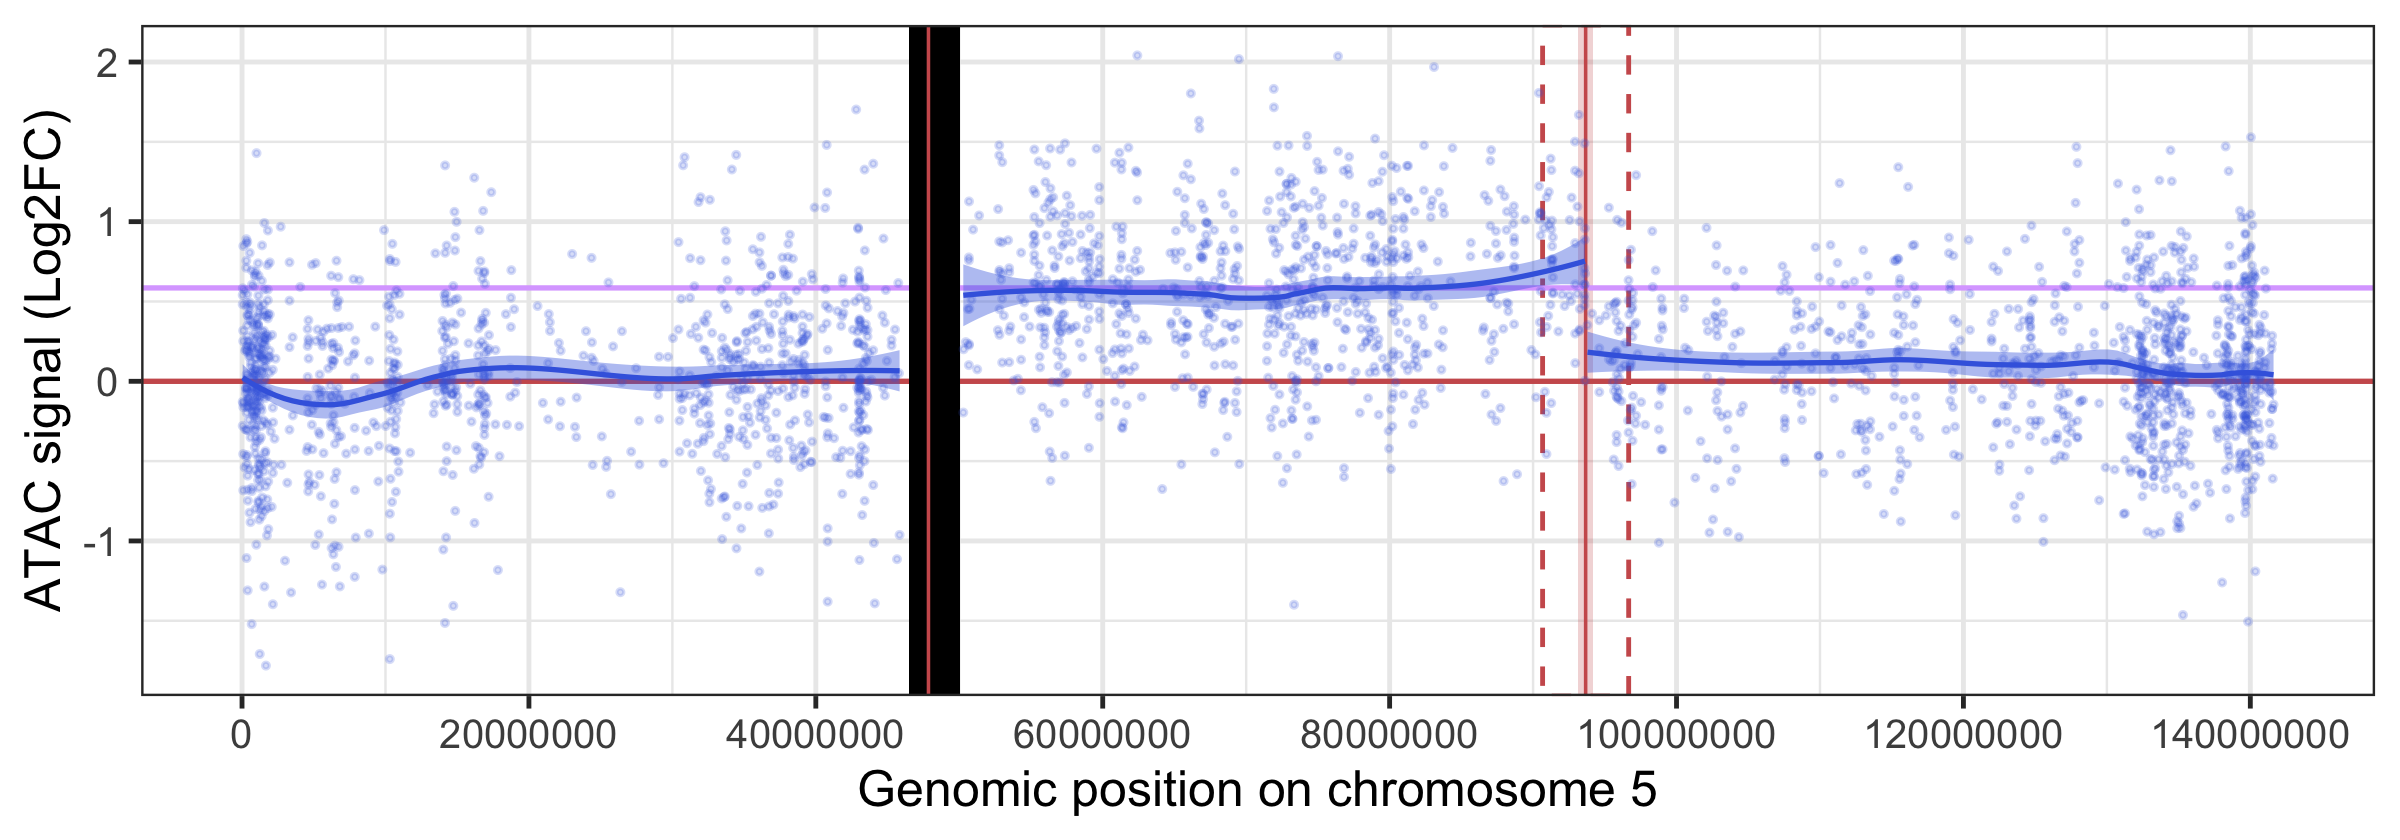

In [12]:
p <- ggplot() +
  geom_rect(aes(xmin=93664295-500000, xmax=93664295+500000, ymin=-Inf, ymax=Inf),
            fill = "indianred",
            alpha = 0.25)+
  geom_rect(aes(xmin=93664295-3000000, xmax=93664295+3000000, ymin=-Inf, ymax=Inf),
            color = "indianred",
            linetype = 2,
            fill = NA)+
  geom_hline(yintercept = 0, 
             color = "indianred",
             linewidth = 1.5)+
  geom_hline(yintercept = log2(1.5),
             color = "#dbaaff", 
             linewidth = 1.5)+
  geom_rect(aes(xmin=46485900, xmax=50059807, ymin=-Inf, ymax=Inf), # Black-out the centromere 
            fill= "black",
            alpha=1)+
  geom_vline(xintercept = 45499899+(50204167-45499899)/2,
             color = "indianred",
             linewidth = 1)+
  geom_vline(xintercept = 93664295, 
             color = "indianred",
             linewidth = 1)+
  geom_point(data = peaks_scores_s, 
             aes(x = Location, y = L2FC),
             alpha = 0.2, 
             size = 1,
             color = "royalblue") +
  geom_smooth(data = peaks_scores_s[peaks_scores_s$Location <= 45499899+(50204167-45499899)/2,],
              aes(x = Location, y = L2FC),
              method = "loess",
              span = 0.5, 
              linewidth = 1.5,
              color = "royalblue", 
              se = T, 
              fill = "royalblue")+
  geom_smooth(data = peaks_scores_s[peaks_scores_s$Location > 45499899+(50204167-45499899)/2 & peaks_scores_s$Location < 93664295,],
              aes(x = Location, y = L2FC),
              method = "loess",
              span = 0.5,
              linewidth = 1.5,
              color = "royalblue",
              se = T,
              fill = "royalblue")+
  geom_smooth(data = peaks_scores_s[peaks_scores_s$Location >= 93664295,], aes(x = Location, y = L2FC),
              method = "loess",
              span = 0.5, 
              linewidth = 1.5,
              color = "royalblue",
              se = T,
              fill = "royalblue")+
  scale_y_continuous(breaks = seq(-5, 5, by = 1),
                     minor_breaks = seq(-5, 5, by = 0.5))+
  scale_x_continuous(breaks = seq(0, 200000000, by = 20000000),
                     minor_breaks = seq(0, 200000000, by = 10000000))+
  ylab("ATAC signal (Log2FC)")+
  xlab("Genomic position on chromosome 5")+
  theme_bw(base_size=30)
options(repr.plot.width=20, repr.plot.height=7)
p

### Breakpoint analysis

We test whether there are significant differences in ATAC signal between groups G0 and G1 around the copy number alteration breakpoints. To do so, we compare the mean L2FC of peaks at a fixed distance from the breakpoints to the mean L2FC of peaks at a fixed distance from randomly selected loci away from breakpoints.

#### True mean L2FC

In [13]:
b2 <- 93664295

distances <- c(100000,250000,500000,750000,1000000,1500000)
peaks_around_bp <-  data.frame(Peak_ID = double(),
                               distance = double(),
                               bp = character())
for (distance in distances){    
  inds_b2r <- which(peaks_info_data$start >= b2 & peaks_info_data$end <= b2+distance)
  peaks_around_bp <- rbind(peaks_around_bp, 
                           cbind(peaks_info_data$ID[inds_b2r],
                                 rep(distance,length(inds_b2r)),
                                 rep("B2_R",length(inds_b2r))))
  
  inds_b2l <- which(peaks_info_data$start >= b2-distance & peaks_info_data$end <= b2)
  peaks_around_bp <- rbind(peaks_around_bp, 
                           cbind(peaks_info_data$ID[inds_b2l],
                                 rep(distance,length(inds_b2l)),
                                 rep("B2_L",length(inds_b2l))))
}
colnames(peaks_around_bp) <- c("Peak_ID","DistanceFromBreakpoint","Breakpoint")

write_csv(peaks_around_bp,"../../Data/ATAC_Data/PeakData/Chr5/Chr5Gain_PeaksFlankingBreakpoints.csv")

# Cumulative shared peak signal around the breakpoints - true loci flanking breakpoints

# 1. Right breakpoint, left-side
peaks_scores_around_bp_b2l <-  data.frame(distance = double(),
                                          L2FC = double())

for (distance in distances) {
  s0 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_bp[peaks_around_bp$DistanceFromBreakpoint == distance &
                                                                     peaks_around_bp$Breakpoint == "B2_L",]$Peak_ID,]$SN_C0
  s1 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_bp[peaks_around_bp$DistanceFromBreakpoint == distance &
                                                                     peaks_around_bp$Breakpoint == "B2_L",]$Peak_ID,]$SN_C1
  
  peaks_scores_around_bp_b2l <- rbind(peaks_scores_around_bp_b2l, cbind(distance, sum(log2(s1/s0))/length(s0),"B2_L"))
}

colnames(peaks_scores_around_bp_b2l) <- c("DistanceFromBreakpoint","MeanL2FC","Breakpoint")
peaks_scores_around_bp_b2l$DistanceFromBreakpoint <- factor(as.character(peaks_scores_around_bp_b2l$DistanceFromBreakpoint),
                                                            levels = c("100000","250000","500000","750000","1000000",
                                                                       "1500000"))


# 2. Right breakpoint, right-side
peaks_scores_around_bp_b2r <-  data.frame(distance = double(),
                                          L2FC = double())

for (distance in distances) {
  s0 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_bp[peaks_around_bp$DistanceFromBreakpoint == distance &
                                                                     peaks_around_bp$Breakpoint == "B2_R",]$Peak_ID,]$SN_C0
  s1 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_bp[peaks_around_bp$DistanceFromBreakpoint == distance &
                                                                     peaks_around_bp$Breakpoint == "B2_R",]$Peak_ID,]$SN_C1
  
  peaks_scores_around_bp_b2r <- rbind(peaks_scores_around_bp_b2r, cbind(distance, sum(log2(s1/s0))/length(s0),"B2_R"))
}

colnames(peaks_scores_around_bp_b2r) <- c("DistanceFromBreakpoint","MeanL2FC","Breakpoint")
peaks_scores_around_bp_b2r$DistanceFromBreakpoint <- factor(as.character(peaks_scores_around_bp_b2r$DistanceFromBreakpoint),
                                                            levels = c("100000","250000","500000","750000","1000000",
                                                                       "1500000"))

#peaks_scores_around_bp_b2r

peaks_scores_around_bp_all <- rbind(peaks_scores_around_bp_b2l,
                                    peaks_scores_around_bp_b2r)

peaks_scores_around_bp_all$MeanL2FC <- as.numeric(peaks_scores_around_bp_all$MeanL2FC)

peaks_scores_around_bp_all$DistanceFromBreakpoint <- factor(as.character(peaks_scores_around_bp_all$DistanceFromBreakpoint),
                                                            levels = c("100000","250000","500000","750000","1000000",
                                                                       "1500000"))

write_csv(peaks_scores_around_bp_all,"../../Data/ATAC_Data/PeakData/Chr5/Chr5Gain_PeaksFlankingBreakpoints_TrueMeanL2FC.csv")

#### Mean L2FC around random loci (null distribution)

In [20]:
# Select random loci 

b1 <- 50204167
b2 <- 93664295
e <- 141620433

set.seed(123) 

loci_b2l <- round(runif(5000, b1+1500000, b2-1500000))
loci_b2r <- round(runif(5000, b2+1500000, e-1500000))

peaks_around_random_bp <-  data.frame(Locus = double(),
                                      Peak_ID = double(),
                                      distance = double(),
                                      bp = character())


for (l in loci_b2l){
  for (distance in distances){
    inds <- which(peaks_info_data$start >= (l-distance) & peaks_info_data$end <= l)
    peaks_around_random_bp <- rbind(peaks_around_random_bp, 
                                    cbind(rep(l,length(inds)),
                                          peaks_info_data$ID[inds],
                                          rep(distance,length(inds)),
                                          rep("B2_L",length(inds))))
  }
}

for (l in loci_b2r){
  for (distance in distances){
    inds <- which(peaks_info_data$start >= l & peaks_info_data$end <= l+distance)
    peaks_around_random_bp <- rbind(peaks_around_random_bp, 
                                    cbind(rep(l,length(inds)),
                                          peaks_info_data$ID[inds],
                                          rep(distance,length(inds)),
                                          rep("B2_R",length(inds))))
  }
}

colnames(peaks_around_random_bp) <- c("Locus","Peak_ID","DistanceFromBreakpoint","Breakpoint")

write_csv(peaks_around_random_bp,"../../Data/ATAC_Data/PeakData/Chr5/Chr5Gain_PeaksFlankingBreakpoints_RandomLoci.csv")


# Cumulative shared peak signal around the breakpoints - random loci

# 1. Right breakpoint, left-side
peak_scores_around_random_bp_b2l <-  data.frame(distance = double(),
                                                L2FC = double())

for (l in loci_b2l){
  for (distance in distances) {
    
    s0 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_random_bp[peaks_around_random_bp$DistanceFromBreakpoint == distance &
                                                                              peaks_around_random_bp$Locus == l & peaks_around_random_bp$Breakpoint == "B2_L",]$Peak_ID,]$SN_C0
    s1 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_random_bp[peaks_around_random_bp$DistanceFromBreakpoint == distance &
                                                                              peaks_around_random_bp$Locus == l & peaks_around_random_bp$Breakpoint == "B2_L",]$Peak_ID,]$SN_C1
    
    
    peak_scores_around_random_bp_b2l <- rbind(peak_scores_around_random_bp_b2l, cbind(distance, sum(log2(s1/s0))/length(s0), "B2_L"))
  }
}

colnames(peak_scores_around_random_bp_b2l) <- c("DistanceFromBreakpoint","MeanL2FC","Breakpoint")
peak_scores_around_random_bp_b2l <- na.omit(peak_scores_around_random_bp_b2l)
peak_scores_around_random_bp_b2l$DistanceFromBreakpoint <- factor(as.character(peak_scores_around_random_bp_b2l$DistanceFromBreakpoint),
                                                                  levels = c("100000","250000","500000","750000","1000000",
                                                                             "1500000"))

# 2. Right breakpoint, right-side

peak_scores_around_random_bp_b2r <-  data.frame(distance = double(),
                                                L2FC = double())

for (l in loci_b2r){
  for (distance in distances) {
    
    s0 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_random_bp[peaks_around_random_bp$DistanceFromBreakpoint == distance &
                                                                              peaks_around_random_bp$Locus == l & peaks_around_random_bp$Breakpoint == "B2_R",]$Peak_ID,]$SN_C0
    s1 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_random_bp[peaks_around_random_bp$DistanceFromBreakpoint == distance &
                                                                              peaks_around_random_bp$Locus == l & peaks_around_random_bp$Breakpoint == "B2_R",]$Peak_ID,]$SN_C1
    
    
    peak_scores_around_random_bp_b2r <- rbind(peak_scores_around_random_bp_b2r, cbind(distance, sum(log2(s1/s0))/length(s0), "B2_R"))
  }
}

colnames(peak_scores_around_random_bp_b2r) <- c("DistanceFromBreakpoint","MeanL2FC","Breakpoint")
peak_scores_around_random_bp_b2r <- na.omit(peak_scores_around_random_bp_b2r)
peak_scores_around_random_bp_b2r$DistanceFromBreakpoint <- factor(as.character(peak_scores_around_random_bp_b2r$DistanceFromBreakpoint),
                                                                  levels = c("100000","250000","500000","750000","1000000",
                                                                             "1500000"))
peaks_scores_around_random_bp_all <- rbind(peak_scores_around_random_bp_b2l,
                                           peak_scores_around_random_bp_b2r)

peaks_scores_around_random_bp_all$MeanL2FC <- as.numeric(peaks_scores_around_random_bp_all$MeanL2FC)

peaks_scores_around_random_bp_all$DistanceFromBreakpoint <- factor(as.character(peaks_scores_around_random_bp_all$DistanceFromBreakpoint),
                                                                   levels = c("100000","250000","500000","750000","1000000",
                                                                              "1500000"))

write_csv(peaks_scores_around_random_bp_all,"../../Data/ATAC_Data/PeakData/Chr5/Chr5Gain_PeaksFlankingBreakpoints_RandomLoci_SimulatedMeanL2FC.csv")

In [17]:
# Load the simulated and true data
peaks_scores_around_random_bp_all <- read_csv("../../Data/ATAC_Data/PeakData/Chr5/Chr5Gain_PeaksFlankingBreakpoints_RandomLoci_SimulatedMeanL2FC.csv",
                                              col_types = "cdc")
peaks_scores_around_bp_all <- read_csv("../../Data/ATAC_Data/PeakData/Chr5/Chr5Gain_PeaksFlankingBreakpoints_TrueMeanL2FC.csv",
                                       col_types = "cdc")

peaks_scores_around_random_bp_all$DistanceFromBreakpoint <- factor(as.character(peaks_scores_around_random_bp_all$DistanceFromBreakpoint),
                                                                   levels = c("100000","250000","500000","750000","1000000",
                                                                              "1500000"))
peaks_scores_around_bp_all$DistanceFromBreakpoint <- factor(as.character(peaks_scores_around_bp_all$DistanceFromBreakpoint),
                                                            levels = c("100000","250000","500000","750000","1000000",
                                                                       "1500000"))
distance.labs <- c("100000"="100kb","250000"="250kb","500000" = "500kb", "750000" = "750kb",
                   "1000000" = "1Mb",  "1500000" = "1.5Mb")

#### 2nd breakpoint: left

Warning message:
“Removed 3767 rows containing non-finite outside the scale range (`stat_bin()`).”


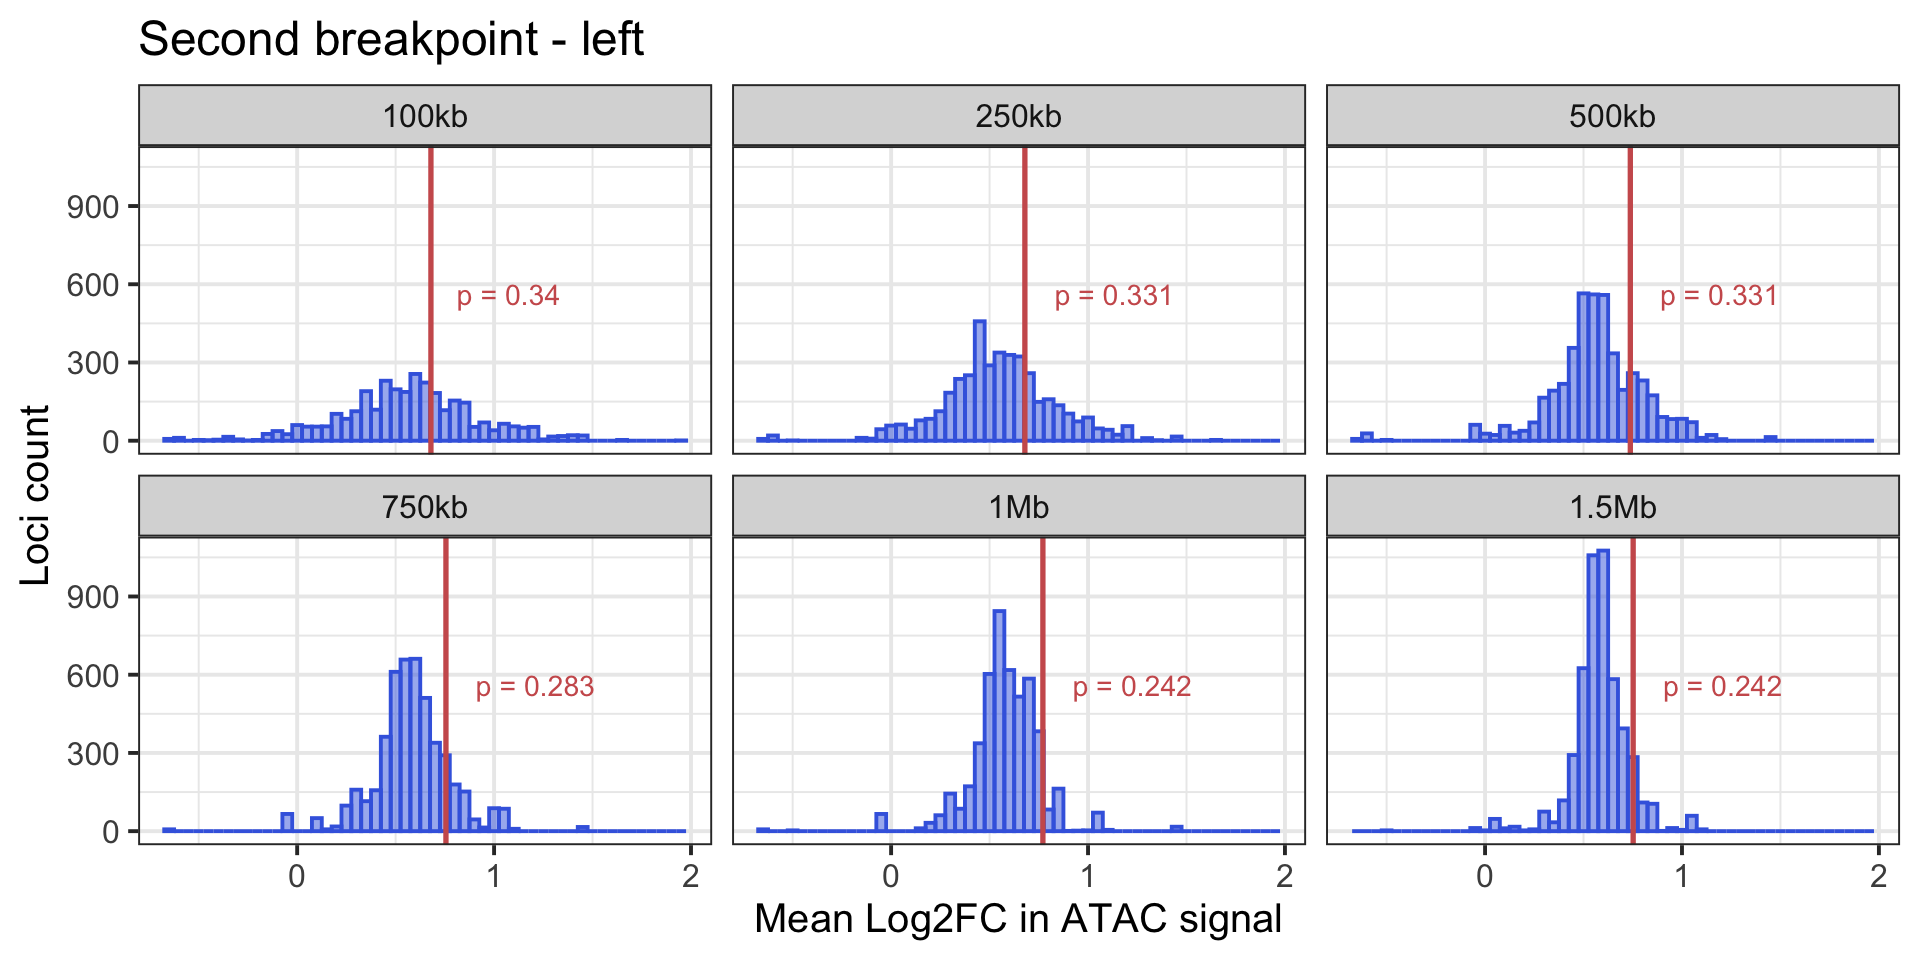

In [18]:
pval <- pValueH(peaks_scores_around_random_bp_all[peaks_scores_around_random_bp_all$Breakpoint == "B2_L",],
                peaks_scores_around_bp_all[peaks_scores_around_bp_all$Breakpoint == "B2_L",],
                "DistanceFromBreakpoint",
                "MeanL2FC")

pval$DistanceFromBreakpoint <- factor(as.character(pval$DistanceFromBreakpoint),
                                      levels = c("100000","250000","500000","750000","1000000","1500000"))

options(repr.plot.width=16, repr.plot.height=8)
p <- ggplot(peaks_scores_around_random_bp_all[peaks_scores_around_random_bp_all$Breakpoint == "B2_L",],
            aes(x = MeanL2FC,group = DistanceFromBreakpoint))+
  geom_histogram(binwidth = 0.05, alpha = 0.5, color = "royalblue", fill = "royalblue") +
  geom_vline(data = peaks_scores_around_bp_all[peaks_scores_around_bp_all$Breakpoint == "B2_L",],
             aes(xintercept = MeanL2FC,group = DistanceFromBreakpoint), color = "indianred",linewidth=1.5  ) +
  geom_text(data = pval, aes(x = xvalue, y = 600, label = label, group = DistanceFromBreakpoint), 
            vjust = 1, hjust = -0.25, color = "indianred", size = 6)+
  guides(fill = "none", color = "none")+
  ylab("Loci count")+
  xlab("Mean Log2FC in ATAC signal") +
  ggtitle("Second breakpoint - left")+
  facet_wrap(vars(DistanceFromBreakpoint),
             nrow = 2,
             labeller = labeller(DistanceFromBreakpoint = distance.labs))+
  theme_bw(base_size = 24)
p

#### 2nd breakpoint: right

Warning message:
“Removed 4396 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_vline()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_text()`).”


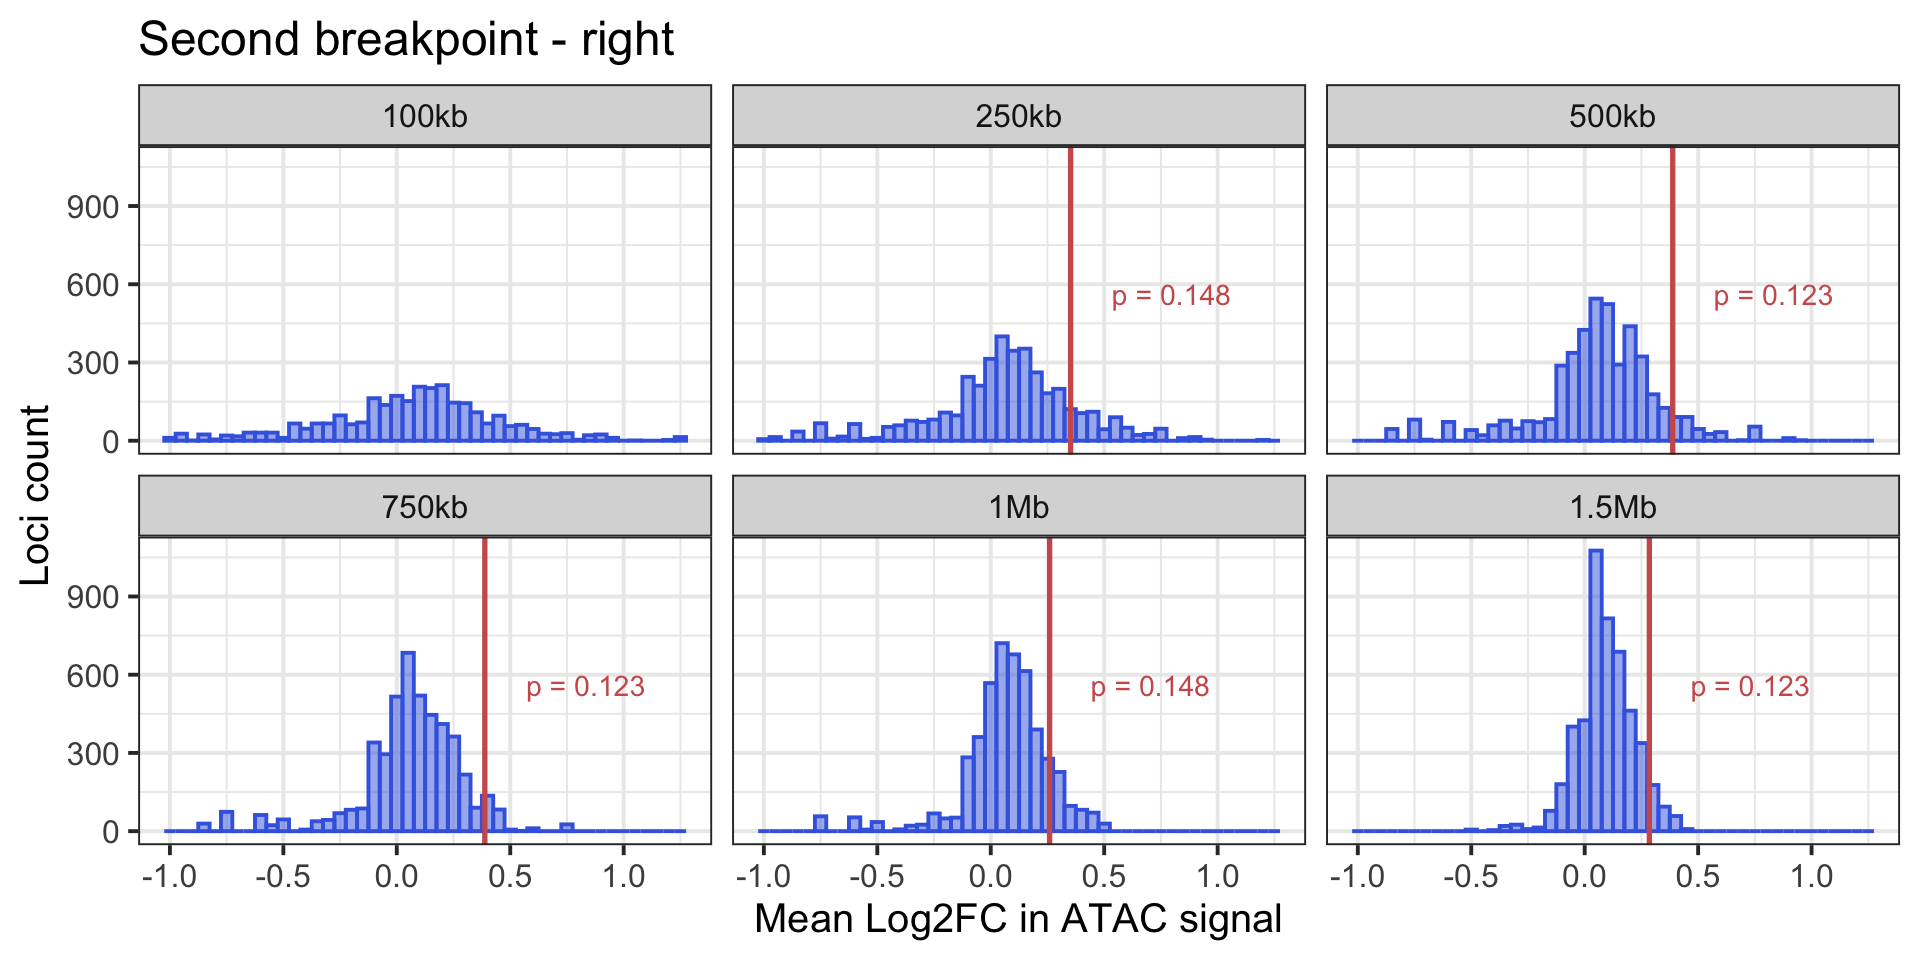

In [21]:
pval <- pValueH(peaks_scores_around_random_bp_all[peaks_scores_around_random_bp_all$Breakpoint == "B2_R",],
                peaks_scores_around_bp_all[peaks_scores_around_bp_all$Breakpoint == "B2_R",],
                "DistanceFromBreakpoint",
                "MeanL2FC")

pval$DistanceFromBreakpoint <- factor(as.character(pval$DistanceFromBreakpoint),
                                      levels = c("100000","250000","500000","750000","1000000","1500000"))

options(repr.plot.width=16, repr.plot.height=8)
p <- ggplot(peaks_scores_around_random_bp_all[peaks_scores_around_random_bp_all$Breakpoint == "B2_R",],
            aes(x = MeanL2FC,group = DistanceFromBreakpoint))+
  geom_histogram(binwidth = 0.05, alpha = 0.5, color = "royalblue", fill = "royalblue") +
  geom_vline(data = peaks_scores_around_bp_all[peaks_scores_around_bp_all$Breakpoint == "B2_R",],
             aes(xintercept = MeanL2FC,group = DistanceFromBreakpoint), color = "indianred",linewidth=1.5  ) +
  geom_text(data = pval, aes(x = xvalue+0.05, y = 600, label = label, group = DistanceFromBreakpoint), 
            vjust = 1, hjust = -0.25, color = "indianred", size = 6)+
  guides(fill = "none", color = "none")+
  ylab("Loci count")+
  xlab("Mean Log2FC in ATAC signal") +
  ggtitle("Second breakpoint - right")+
  facet_wrap(vars(DistanceFromBreakpoint),
             nrow = 2,
             labeller = labeller(DistanceFromBreakpoint = distance.labs))+
  theme_bw(base_size = 24)
p

## Gain in chromosome 20

### Add clade groupings to the ArchR project and obtain BigWig files containing the ATAC signal for each clones

In [22]:
# Clone information for the gain in chromosome 20
gain_chr20 <- c()
gain_chr20[proj_fil$GeneticClade_Full %in% groups[groups$Location == "chr20:500001-19500000" &
                                                   groups$Altered == "0",]$Clade ] <- "0"
gain_chr20[proj_fil$GeneticClade_Full %in% groups[groups$Location == "chr20:500001-19500000" &
                                                   groups$Altered == "1",]$Clade ] <- "1"
gain_chr20[proj_fil$GeneticClade_Full %in% groups[groups$Location == "chr20:500001-19500000" &
                                                   groups$Altered == "NA",]$Clade ] <- "NA"

# Add clone information to the project
proj_fil$gain_chr20 <- gain_chr20

# Obtain BigWig files containing the ATAC signal, normalised by reads in TSS, for each clone
getGroupBW(
  ArchRProj = proj_fil,
  groupBy = "gain_chr20",
  normMethod = "ReadsInTSS"
)

ArchR logging to : ArchRLogs/ArchR-getGroupBW-e8a94a064564-Date-2026-02-24_Time-18-56-04.745992.log
If there is an issue, please report to github with logFile!

2026-02-24 18:56:05.92862 : 0 (1 of 2) : Creating BigWig for Group, 0.02 mins elapsed.

2026-02-24 18:56:30.89913 : 1 (2 of 2) : Creating BigWig for Group, 0.436 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-getGroupBW-e8a94a064564-Date-2026-02-24_Time-18-56-04.745992.log



[1] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_DATAC_Results/GroupBigWigs/gain_chr20/X0-TileSize-100-normMethod-ReadsInTSS-ArchR.bw"
[2] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_DATAC_Results/GroupBigWigs/gain_chr20/X1-TileSize-100-normMethod-ReadsInTSS-ArchR.bw"

In [24]:
# Load peaks if necessary
peaks <- getPeakSet(proj_fil)

# Define the gain region, split into 500 bp intervals
start <- seq(1,  36371597,500)
end <- start + 499
end[length(end)]<- 36371597 #63868647

# Create a peak matrix for chromosome 5

# GRanges object containing the peak information
peaks_info <-  GRanges(
  seqnames = Rle(c("chr20"), c(1)),
  ranges = IRanges(start, end))
peaks_info  <- subsetByOverlaps(peaks, peaks_info)

# Convert the GRanges into a matrix
peaks_info_data <- data.frame(1:length(peaks_info$peakType),
                              rep("chr20", length(peaks_info$peakType)),
                              start(peaks_info),
                              end(peaks_info),
                              peaks_info$peakType,
                              peaks_info$nearestGene,
                              peaks_info$GroupReplicate)
colnames(peaks_info_data) <- c("ID","chrom","start","end","PeakType","NearestGene","GroupReplicate")

# Save peak information for the genomic region of interest
write_csv(peaks_info_data, "../../Data/ATAC_Data/PeakData/Chr20/Chr20Gain_PeakInformation.csv")

### Compare ATAC signal in peaks between groups, respectively, with and without the copy number alteration of interest

In [25]:
# 1. Group G0

# Load the bigwig file to obtain a GRanges object with the ATAC signal ('score' column) across the genome for C0
c0_bw <- import.bw("../../Data/ArchR_Projects/Save_SW620_DATAC_Results/GroupBigWigs/gain_chr20/X0-TileSize-100-normMethod-ReadsInTSS-ArchR.bw")


# Subset the GRanges object to contain the ATAC signal for the genomic region of interest
c0_bw_sub <- GRanges(
  seqnames = Rle(c("chr20"), c(1)),
  ranges = IRanges(start, end))

c0_bw_sub <- subsetByOverlaps(c0_bw, c0_bw_sub)


# Subset the ATAC signal GRanges object to obtain the ATAC signal in peaks
peaks_c0 <- subsetByOverlaps(c0_bw_sub, peaks_info)


# Convert the GRanges object into a dataframe detailing the ATAC signal per genomic region
peaks_c0_data <- data.frame(rep("chr20", length(peaks_c0$score)),
                            start(peaks_c0),
                            end(peaks_c0),
                            peaks_c0$score)
colnames(peaks_c0_data) <- c("chrom","start","end","SN")

peaks_scores_c0 <- ATACSignalInPeaks(peaks_c0_data,peaks_info_data)

# We filter peaks whose ATAC signal are below the average ATAC signal outside of peaks - this ATAC signal is likely just background noise

# Define a GRanges object for the ATAC signal not in peaks
out_peaks_c0 <- subsetByOverlaps(c0_bw_sub, peaks_info, invert = TRUE)

# Convert the GRanges object to a dataframe
out_peaks_c0_data <- data.frame(rep("chr20", length(out_peaks_c0$score)),
                                start(out_peaks_c0),
                                end(out_peaks_c0),
                                out_peaks_c0$score)
colnames(out_peaks_c0_data) <- c("chrom","start","end","SN")

# Filter for genomic regions with positive ATAC signal (i.e., remove missingness) and define the length of genomic regions
out_peaks_c0_data <- out_peaks_c0_data %>%  dplyr::filter(SN > 0) %>% 
  dplyr::mutate(Length = end - start) 

# Compute the average ATAC signal per bp not in peaks - we distinguish regions with different copy number as higher copy number may be associated with higher background ATAC signal - 
# and select the 95th percentile
Avg_lim_g <-  quantile(out_peaks_c0_data[out_peaks_c0_data$end <= 17519356,]$SN/out_peaks_c0_data[out_peaks_c0_data$end <= 17519356,]$Length,0.95)

Avg_lim <-  quantile(out_peaks_c0_data[out_peaks_c0_data$end > 17519356,]$SN/out_peaks_c0_data[out_peaks_c0_data$end > 17519356,]$Length,0.95)

# Peaks are ordered by position, we define the peak ID that delimits different copy number regions
peaks_g_max <- max(peaks_info_data[peaks_info_data$end <=17519356,]$ID)

# Define the background ATAC signal per 500 bp peak; 
# we exclude any peaks with ATAC signal below this minimal value in our subsequent analysis

peaks_scores_c0 <- peaks_scores_c0 %>% dplyr::mutate(MinSN = case_when(Peak_ID <= peaks_g_max ~ Avg_lim_g*500,
                                                                       Peak_ID > peaks_g_max  ~ Avg_lim*500)) 
peaks_scores_c0 <- peaks_scores_c0 %>%  dplyr::filter(SN > MinSN)

write_csv(peaks_scores_c0, "../../Data/ATAC_Data/PeakData/Chr20/Chr20Gain_PeakScores_G0.csv")


# 2. Group G1

# Load the bigwig file to obtain a GRanges object with the ATAC signal ('score' column) across the genome for C0
c1_bw <- import.bw("../../Data/ArchR_Projects/Save_SW620_DATAC_Results/GroupBigWigs/gain_chr20/X1-TileSize-100-normMethod-ReadsInTSS-ArchR.bw")

# Subset the GRanges object to contain the ATAC signal for the genomic region of interest
c1_bw_sub <- GRanges(
  seqnames = Rle(c("chr20"), c(1)),
  ranges = IRanges(start, end))

c1_bw_sub <- subsetByOverlaps(c1_bw, c1_bw_sub)

# Subset the ATAC signal GRanges object to obtain the ATAC signal in peaks
peaks_c1 <- subsetByOverlaps(c1_bw_sub, peaks_info)

# Convert the GRanges object into a dataframe detailing the ATAC signal per genomic region
peaks_c1_data <- data.frame(rep("chr20", length(peaks_c1$score)),
                            start(peaks_c1),
                            end(peaks_c1),
                            peaks_c1$score)
colnames(peaks_c1_data) <- c("chrom","start","end","SN")

peaks_scores_c1 <- ATACSignalInPeaks(peaks_c1_data,peaks_info_data)

# We filter peaks whose ATAC signal are below the average ATAC signal outside of peaks - this ATAC signal is likely just background noise

# Define a GRanges object for the ATAC signal not in peaks
out_peaks_c1 <- subsetByOverlaps(c1_bw_sub, peaks_info, invert = TRUE)

# Convert the GRanges object to a dataframe
out_peaks_c1_data <- data.frame(rep("chr20", length(out_peaks_c1$score)),
                                start(out_peaks_c1),
                                end(out_peaks_c1),
                                out_peaks_c1$score)
colnames(out_peaks_c1_data) <- c("chrom","start","end","SN")

# Filter for genomic regions with positive ATAC signal (i.e., remove missingness) and define the length of genomic regions
out_peaks_c1_data <- out_peaks_c1_data %>%  dplyr::filter(SN > 0) %>% 
  dplyr::mutate(Length = end - start) 

# Compute the average ATAC signal per bp not in peaks - we distinguish regions with different copy number as higher copy number may be associated with higher background ATAC signal - 
# and select the 95th percentile
Avg_lim_g <-  quantile(out_peaks_c1_data[out_peaks_c1_data$end <= 17519356,]$SN/out_peaks_c1_data[out_peaks_c1_data$end <= 17519356,]$Length,0.95)

Avg_lim_d <- quantile(out_peaks_c1_data[out_peaks_c1_data$end > 17519356,]$SN/out_peaks_c1_data[out_peaks_c1_data$end >17519356,]$Length,0.95)

# Peaks are ordered by position, we define the peak ID that delimits different copy number regions
peaks_g_max <- max(peaks_info_data[peaks_info_data$end <= 17519356,]$ID)

# Define the background ATAC signal per 500 bp peak; 
# we exclude any peaks with ATAC signal below this minimal value in our subsequent analysis

peaks_scores_c1 <- peaks_scores_c1 %>%  dplyr::mutate(MinSN = case_when(Peak_ID <= peaks_g_max ~ Avg_lim_g*500,
                                                                        Peak_ID  > peaks_g_max ~ Avg_lim_d*500))
peaks_scores_c1 <- peaks_scores_c1 %>%  dplyr::filter(SN > MinSN)

write_csv(peaks_scores_c1, "../../Data/ATAC_Data/PeakData/Chr20/Chr20Gain_PeakScores_G1.csv")


In [26]:
# We compare the ATAC signal in peaks that are shared by groups G0 and G1

shared_peaks <- intersect(peaks_scores_c0$Peak_ID,peaks_scores_c1$Peak_ID)

# Define 
peaks_scores_c0_s <- peaks_scores_c0 %>% dplyr::filter(Peak_ID %in% shared_peaks) %>%
  dplyr::rename(SN_C0 = SN)


peaks_scores_c1_s <- peaks_scores_c1 %>% dplyr::filter(Peak_ID %in% shared_peaks) %>%
  dplyr::rename(SN_C1 = SN)  


peaks_scores_s <- data.frame("Peak_ID" = peaks_scores_c0_s$Peak_ID,
                             "SN_C0" = peaks_scores_c0_s$SN_C0,
                             "SN_C1" = peaks_scores_c1_s$SN_C1)

# We set each peak's location at its midpoint
loc <- peaks_info_data[peaks_info_data$ID %in% peaks_scores_s$Peak_ID,]$start +
  (peaks_info_data[peaks_info_data$ID %in% peaks_scores_s$Peak_ID,]$end-
     peaks_info_data[peaks_info_data$ID %in% peaks_scores_s$Peak_ID,]$start)/2


peaks_scores_s <- peaks_scores_s %>% dplyr::mutate(Region = case_when(Peak_ID <= peaks_g_max ~ "Gain segment (3 v 4)",
                                                                      Peak_ID  > peaks_g_max ~ "Copy number 3 segment")) %>%
  dplyr::mutate(L2FC = log2(SN_C1/SN_C0)) %>%
  dplyr::mutate(Location = loc)

write_csv(peaks_scores_s,"../../Data/ATAC_Data/PeakData/Chr20/Chr20Gain_PeakScores_G0vG1_Comparison_SourceData.csv")


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


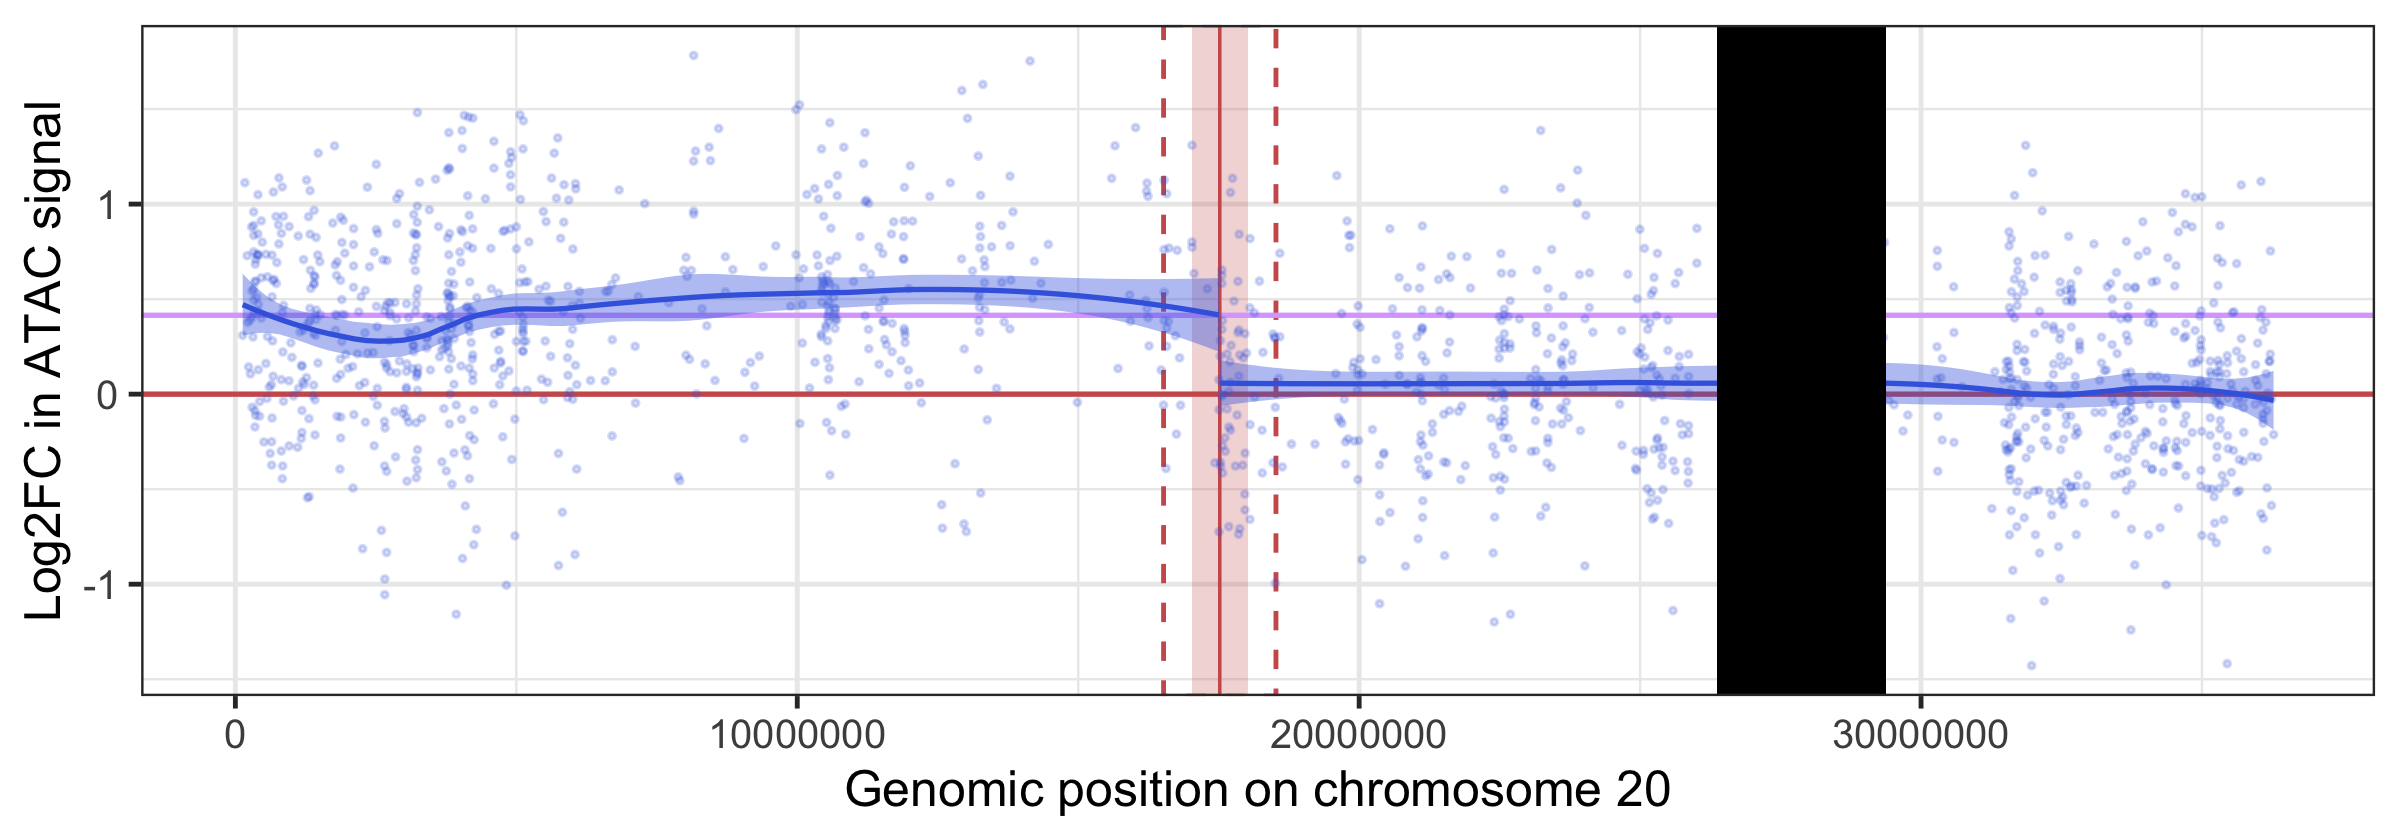

In [27]:
p1 <- ggplot() +
  geom_rect(aes(xmin=17519356-500000, xmax=17519356+500000, ymin=-Inf, ymax=Inf),
            fill = "indianred",
            alpha = 0.25)+
  geom_rect(aes(xmin=17519356-1000000, xmax=17519356+1000000, ymin=-Inf, ymax=Inf),
            color = "indianred",
            linetype = 2,
            fill = NA)+
  geom_hline(yintercept = 0, 
             color = "indianred",
             linewidth = 1.5)+
  geom_hline(yintercept = log2(4/3),
             color = "#dbaaff", 
             linewidth = 1.5)+
  geom_vline(xintercept = 17519356, 
             color = "indianred",
             linewidth = 1)+
  geom_point(data = peaks_scores_s, 
             aes(x = Location, y = L2FC),
             alpha = 0.2, 
             size = 1,
             color = "royalblue") +
  geom_smooth(data = peaks_scores_s[peaks_scores_s$Location <= 17519356,],
              aes(x = Location, y = L2FC),
              method = "loess",
              span = 0.5, 
              linewidth = 1.5,
              color = "royalblue", 
              se = T, 
              fill = "royalblue")+
  geom_smooth(data = peaks_scores_s[peaks_scores_s$Location > 17519356,],
              aes(x = Location, y = L2FC),
              method = "loess",
              span = 0.5, 
              linewidth = 1.5,
              color = "royalblue", 
              se = T, 
              fill = "royalblue")+
  geom_rect(aes(xmin=26369569, xmax=29369569, ymin=-Inf, ymax=Inf), # Black-out the centromere 
            fill= "black",
            alpha=1)+
  scale_y_continuous(breaks = seq(-5, 5, by = 1),
                     minor_breaks = seq(-5, 5, by = 0.5))+
  scale_x_continuous(breaks = seq(0, 70000000, by = 10000000),
                     minor_breaks = seq(0, 70000000, by = 5000000))+
  ylab("Log2FC in ATAC signal")+
  xlab("Genomic position on chromosome 20")+
  theme_bw(base_size=30)
options(repr.plot.width=20, repr.plot.height=7)
p1

### Breakpoint analysis

We test whether there are significant differences in ATAC signal between groups G0 and G1 around the copy number alteration breakpoints. To do so, we compare the mean L2FC of peaks at a fixed distance from the breakpoints to the mean L2FC of peaks at a fixed distance from randomly selected loci away from breakpoints.

#### True mean L2FC

In [29]:
# Find the peaks which are flanking the breakpoints, at distances varying 100 kB to 3 Mb

b1 <- 17519356

distances <- c(100000,250000,500000,750000,1000000,1500000)
peaks_around_bp <-  data.frame(Peak_ID = double(),
                               distance = double(),
                               bp = character())
for (distance in distances){
  inds_b1l <- which(peaks_info_data$start >= b1-distance & peaks_info_data$end <= b1)
  peaks_around_bp <- rbind(peaks_around_bp, 
                           cbind(peaks_info_data$ID[inds_b1l],
                                 rep(distance,length(inds_b1l)),
                                 rep("B1_L",length(inds_b1l))))
  
  
  
  inds_b1r <- which(peaks_info_data$start >= b1 & peaks_info_data$end <= b1+distance)
  peaks_around_bp <- rbind(peaks_around_bp, 
                           cbind(peaks_info_data$ID[inds_b1r],
                                 rep(distance,length(inds_b1r)),
                                 rep("B1_R",length(inds_b1r))))
  
  
}
colnames(peaks_around_bp) <- c("Peak_ID","DistanceFromBreakpoint","Breakpoint")

write_csv(peaks_around_bp,"../../Data/ATAC_Data/PeakData/Chr20/Chr20Loss_PeaksFlankingBreakpoints.csv")

# Cumulative shared peak signal around the breakpoints - true loci flanking breakpoints

# 1. Left breakpoint, right-side
peaks_scores_around_bp_b1r <-  data.frame(distance = double(),
                                          L2FC = double())

for (distance in distances) {
  s0 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_bp[peaks_around_bp$DistanceFromBreakpoint == distance &
                                                                     peaks_around_bp$Breakpoint == "B1_R",]$Peak_ID,]$SN_C0
  s1 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_bp[peaks_around_bp$DistanceFromBreakpoint == distance &
                                                                     peaks_around_bp$Breakpoint == "B1_R",]$Peak_ID,]$SN_C1
  
  peaks_scores_around_bp_b1r <- rbind(peaks_scores_around_bp_b1r, cbind(distance, sum(log2(s1/s0))/length(s0),"B1_R"))
}

colnames(peaks_scores_around_bp_b1r) <- c("DistanceFromBreakpoint","MeanL2FC","Breakpoint")
peaks_scores_around_bp_b1r$DistanceFromBreakpoint <- factor(as.character(peaks_scores_around_bp_b1r$DistanceFromBreakpoint),
                                                            levels = c("100000","250000","500000",
                                                                       "750000","1000000","1500000"))

# 2. Left breakpoint, left-side
peaks_scores_around_bp_b1l <-  data.frame(distance = double(),
                                          L2FC = double())

for (distance in distances) {
  s0 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_bp[peaks_around_bp$DistanceFromBreakpoint == distance &
                                                                     peaks_around_bp$Breakpoint == "B1_L",]$Peak_ID,]$SN_C0
  s1 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_bp[peaks_around_bp$DistanceFromBreakpoint == distance &
                                                                     peaks_around_bp$Breakpoint == "B1_L",]$Peak_ID,]$SN_C1
  
  peaks_scores_around_bp_b1l <- rbind(peaks_scores_around_bp_b1l, cbind(distance, sum(log2(s1/s0))/length(s0),"B1_L"))
}

colnames(peaks_scores_around_bp_b1l) <- c("DistanceFromBreakpoint","MeanL2FC","Breakpoint")
peaks_scores_around_bp_b1l$DistanceFromBreakpoint <- factor(as.character(peaks_scores_around_bp_b1l$DistanceFromBreakpoint),
                                                            levels = c("100000","250000","500000",
                                                                       "750000","1000000","1500000"))


peaks_scores_around_bp_all <- rbind(peaks_scores_around_bp_b1l,
                                    peaks_scores_around_bp_b1r)

peaks_scores_around_bp_all$MeanL2FC <- as.numeric(peaks_scores_around_bp_all$MeanL2FC)

peaks_scores_around_bp_all$DistanceFromBreakpoint <- factor(as.character(peaks_scores_around_bp_all$DistanceFromBreakpoint),
                                                            levels = c("100000","250000","500000",
                                                                       "750000","1000000","1500000"))

write_csv(peaks_scores_around_bp_all,"../../Data/ATAC_Data/PeakData/Chr20/Chr20Gain_PeaksFlankingBreakpoints_TrueMeanL2FC.csv")


#### Mean L2FC around random loci (null distribution)

In [ ]:
s <- 1
b1 <- 17519356
e <- 37000000

set.seed(123)

loci_b1l <- round(runif(1000, s+1500000, b1-1500000))
loci_b1r <- round(runif(1000, b1+1500000, e-1500000))

peaks_around_random_bp <-  data.frame(Locus = double(),
                                      Peak_ID = double(),
                                      distance = double(),
                                      bp = character())


for (l in loci_b1l){
  for (distance in distances){
    inds <- which(peaks_info_data$start >= (l-distance) & peaks_info_data$end <= l)
    peaks_around_random_bp <- rbind(peaks_around_random_bp, 
                                    cbind(rep(l,length(inds)),
                                          peaks_info_data$ID[inds],
                                          rep(distance,length(inds)),
                                          rep("B1_L",length(inds))))
  }
}
for (l in loci_b1r){
  for (distance in distances){
    inds <- which(peaks_info_data$start >= l & peaks_info_data$end <= l+distance)
    peaks_around_random_bp <- rbind(peaks_around_random_bp, 
                                    cbind(rep(l,length(inds)),
                                          peaks_info_data$ID[inds],
                                          rep(distance,length(inds)),
                                          rep("B1_R",length(inds))))
  }
}


colnames(peaks_around_random_bp) <- c("Locus","Peak_ID","DistanceFromBreakpoint","Breakpoint")

write_csv(peaks_around_random_bp,"../../Data/ATAC_Data/PeakData/Chr20/Chr20Gain_PeaksFlankingBreakpoints_RandomLoci.csv")

# Cumulative shared peak signal around the breakpoints - random loci

# 1. Left breakpoint, left-side
peak_scores_around_random_bp_b1l <-  data.frame(distance = double(),
                                                L2FC = double())

for (l in loci_b1l){
  for (distance in distances) {
    
    s0 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_random_bp[peaks_around_random_bp$DistanceFromBreakpoint == distance &
                                                                              peaks_around_random_bp$Locus == l & peaks_around_random_bp$Breakpoint == "B1_L",]$Peak_ID,]$SN_C0
    s1 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_random_bp[peaks_around_random_bp$DistanceFromBreakpoint == distance &
                                                                              peaks_around_random_bp$Locus == l & peaks_around_random_bp$Breakpoint == "B1_L",]$Peak_ID,]$SN_C1
    
    
    peak_scores_around_random_bp_b1l <- rbind(peak_scores_around_random_bp_b1l, cbind(distance, sum(log2(s1/s0))/length(s0), "B1_L"))
  }
}

colnames(peak_scores_around_random_bp_b1l) <- c("DistanceFromBreakpoint","MeanL2FC","Breakpoint")
peak_scores_around_random_bp_b1l <- na.omit(peak_scores_around_random_bp_b1l)
peak_scores_around_random_bp_b1l$DistanceFromBreakpoint <- factor(as.character(peak_scores_around_random_bp_b1l$DistanceFromBreakpoint),
                                                                  levels = c("100000","250000","500000",
                                                                             "750000","1000000","1500000"))

# 2. Left breakpoint, right-side

peak_scores_around_random_bp_b1r <-  data.frame(distance = double(),
                                                L2FC = double())

for (l in loci_b1r){
  for (distance in distances) {
    
    s0 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_random_bp[peaks_around_random_bp$DistanceFromBreakpoint == distance &
                                                                              peaks_around_random_bp$Locus == l & peaks_around_random_bp$Breakpoint == "B1_R",]$Peak_ID,]$SN_C0
    s1 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_random_bp[peaks_around_random_bp$DistanceFromBreakpoint == distance &
                                                                              peaks_around_random_bp$Locus == l & peaks_around_random_bp$Breakpoint == "B1_R",]$Peak_ID,]$SN_C1
    
    
    peak_scores_around_random_bp_b1r <- rbind(peak_scores_around_random_bp_b1r, cbind(distance, sum(log2(s1/s0))/length(s0), "B1_R"))
  }
}

colnames(peak_scores_around_random_bp_b1r) <- c("DistanceFromBreakpoint","MeanL2FC","Breakpoint")
peak_scores_around_random_bp_b1r <- na.omit(peak_scores_around_random_bp_b1r)
peak_scores_around_random_bp_b1r$DistanceFromBreakpoint <- factor(as.character(peak_scores_around_random_bp_b1r$DistanceFromBreakpoint),
                                                                  levels = c("100000","250000","500000",
                                                                             "750000","1000000","1500000"))

peaks_scores_around_random_bp_all <- rbind(peak_scores_around_random_bp_b1l,
                                           peak_scores_around_random_bp_b1r)

peaks_scores_around_random_bp_all$MeanL2FC <- as.numeric(peaks_scores_around_random_bp_all$MeanL2FC)

peaks_scores_around_random_bp_all$DistanceFromBreakpoint <- factor(as.character(peaks_scores_around_random_bp_all$DistanceFromBreakpoint),
                                                                   levels = c("100000","250000","500000",
                                                                              "750000","1000000","1500000"))

write_csv(peaks_scores_around_random_bp_all,"../../Data/ATAC_Data/PeakData/Chr20/Chr20Gain_PeaksFlankingBreakpoints_RandomLoci_SimulatedMeanL2FC.csv")


In [31]:
# Load the simulated and true data
peaks_scores_around_random_bp_all <- read_csv("../../Data/ATAC_Data/PeakData/Chr20/Chr20Gain_PeaksFlankingBreakpoints_RandomLoci_SimulatedMeanL2FC.csv",
                                              col_types = "cdc")
peaks_scores_around_bp_all <- read_csv("../../Data/ATAC_Data/PeakData/Chr20/Chr20Gain_PeaksFlankingBreakpoints_TrueMeanL2FC.csv",
                                       col_types = "cdc")

peaks_scores_around_random_bp_all$DistanceFromBreakpoint <- factor(as.character(peaks_scores_around_random_bp_all$DistanceFromBreakpoint),
                                                                   levels = c("100000","250000","500000",
                                                                              "750000","1000000","1500000"))
peaks_scores_around_bp_all$DistanceFromBreakpoint <- factor(as.character(peaks_scores_around_bp_all$DistanceFromBreakpoint),
                                                            levels = c("100000","250000","500000",
                                                                       "750000","1000000","1500000"))

distance.labs <- c("100000" = "100kb", "250000" = "250kb",
                   "500000" = "500kb", "750000" = "750kb",
                   "1000000" = "1Mb",  "1500000" = "1.5Mb")


#### Breakpoint: left

Warning message:
“Removed 289 rows containing non-finite outside the scale range (`stat_bin()`).”


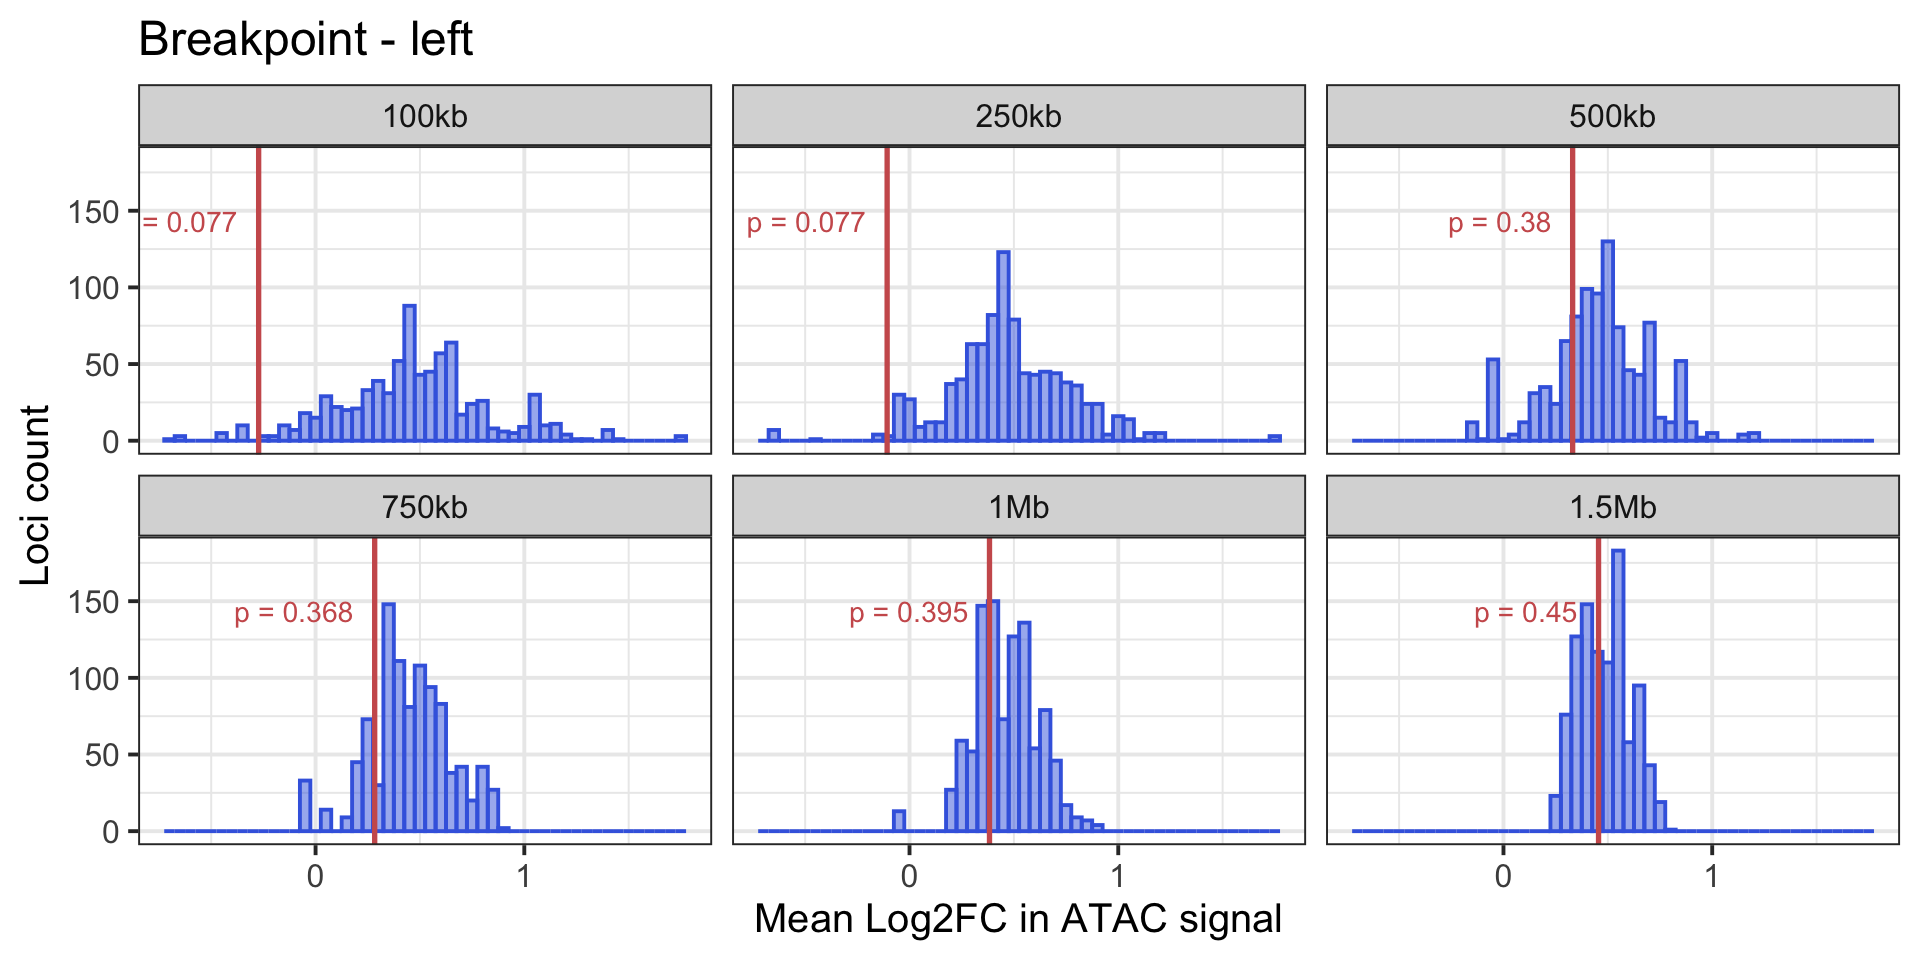

In [34]:
pval <- pValueL(peaks_scores_around_random_bp_all[peaks_scores_around_random_bp_all$Breakpoint == "B1_L",],
                peaks_scores_around_bp_all[peaks_scores_around_bp_all$Breakpoint == "B1_L",],
                "DistanceFromBreakpoint",
                "MeanL2FC")

pval$DistanceFromBreakpoint <- factor(as.character(pval$DistanceFromBreakpoint),
                                      levels = c("100000","250000","500000",
                                                 "750000","1000000","1500000"))


p <- ggplot(peaks_scores_around_random_bp_all[peaks_scores_around_random_bp_all$Breakpoint == "B1_L",],
            aes(x = MeanL2FC,group = DistanceFromBreakpoint))+
  geom_histogram(binwidth = 0.05, alpha = 0.5, color = "royalblue", fill = "royalblue") +
  geom_vline(data = peaks_scores_around_bp_all[peaks_scores_around_bp_all$Breakpoint == "B1_L",],
             aes(xintercept = MeanL2FC,group = DistanceFromBreakpoint),
             color = "indianred",linewidth=1.5  ) +
  geom_text(data = pval, aes(x = xvalue-0.1, y = 150, label = label, group = DistanceFromBreakpoint), 
            vjust = 1, hjust = +1, color = "indianred", size = 6)+
  guides(fill = "none", color = "none")+
  ylab("Loci count")+
  xlab("Mean Log2FC in ATAC signal") +
  ggtitle("Breakpoint - left")+
  facet_wrap(vars(DistanceFromBreakpoint),
             nrow = 2,
             labeller = labeller(DistanceFromBreakpoint = distance.labs))+
  theme_bw(base_size = 24)

options(repr.plot.width=16, repr.plot.height=8)

p

#### Breakpoint: right

Warning message:
“Removed 1283 rows containing non-finite outside the scale range (`stat_bin()`).”


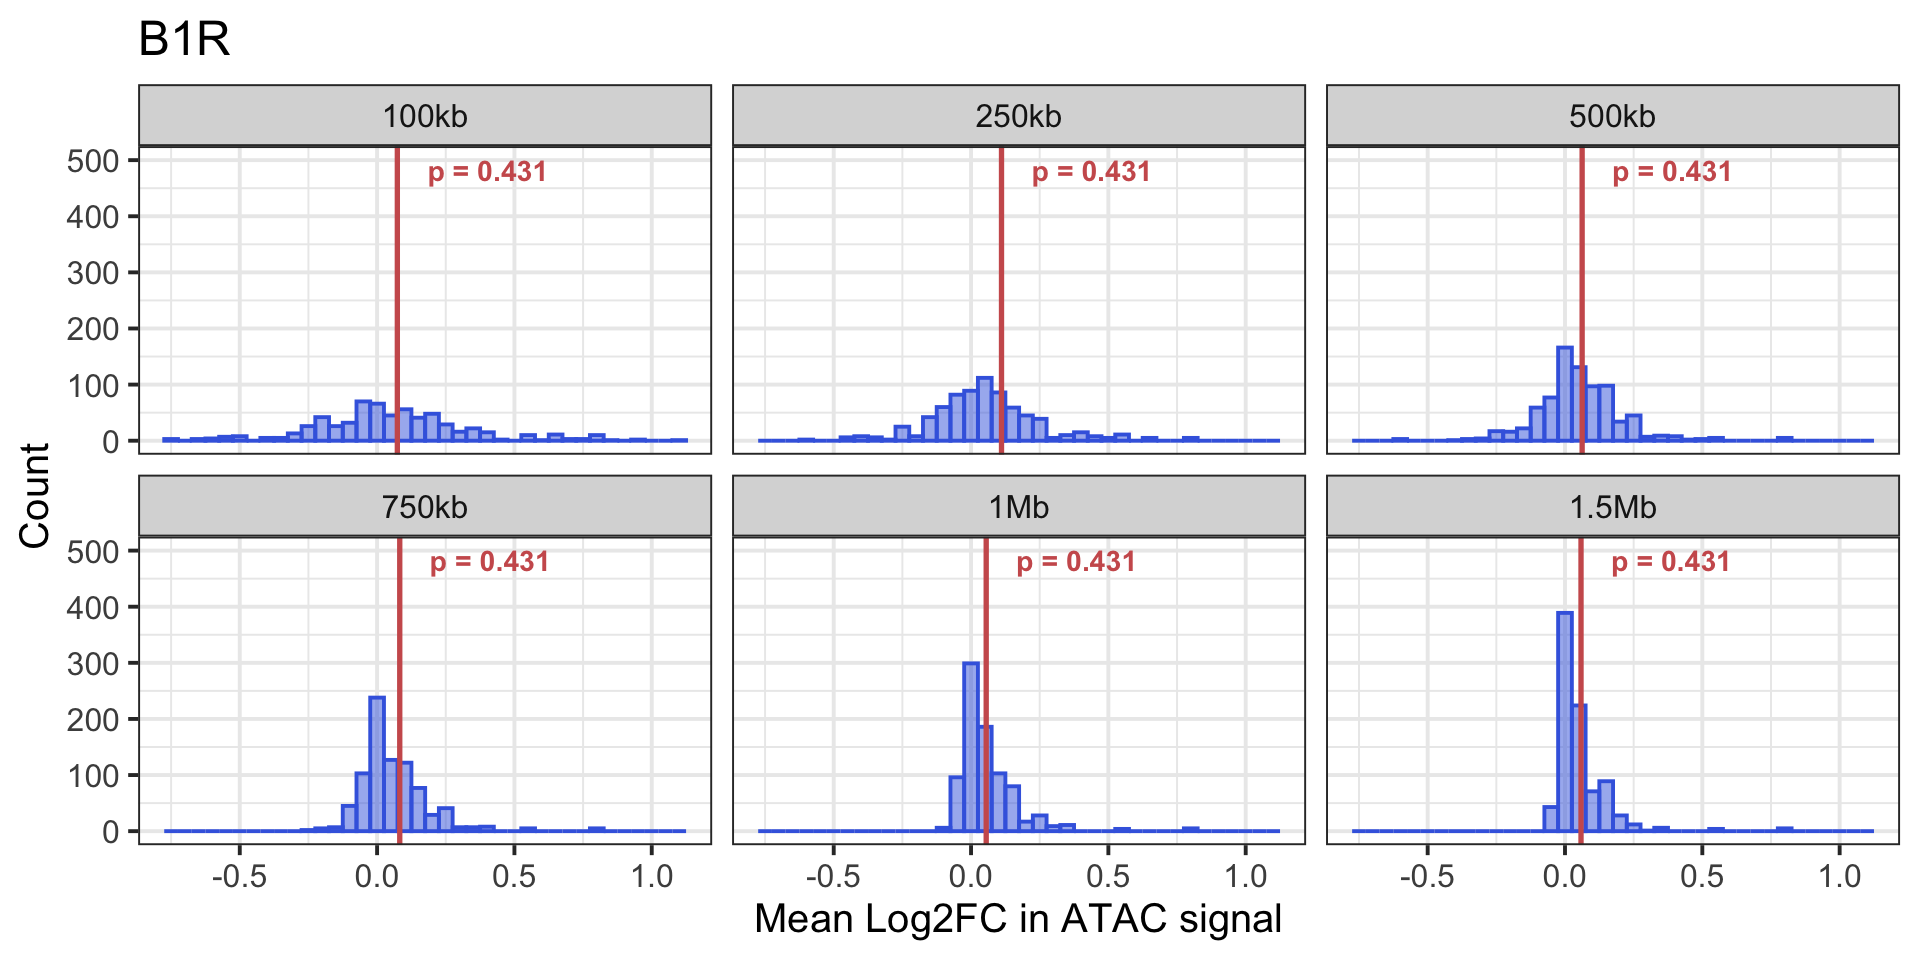

In [35]:
pval <- pValueH(peaks_scores_around_random_bp_all[peaks_scores_around_random_bp_all$Breakpoint == "B1_R",],
                peaks_scores_around_bp_all[peaks_scores_around_bp_all$Breakpoint == "B1_R",],
                "DistanceFromBreakpoint",
                "MeanL2FC")

pval$DistanceFromBreakpoint <- factor(as.character(pval$DistanceFromBreakpoint),
                                      levels = c("100000","250000","500000",
                                                 "750000","1000000","1500000"))


p <- ggplot(peaks_scores_around_random_bp_all[peaks_scores_around_random_bp_all$Breakpoint == "B1_R",],
            aes(x = MeanL2FC,group = DistanceFromBreakpoint))+
  geom_histogram(binwidth = 0.05, alpha = 0.5, color = "royalblue", fill = "royalblue") +
  geom_vline(data = peaks_scores_around_bp_all[peaks_scores_around_bp_all$Breakpoint == "B1_R",],
             aes(xintercept = MeanL2FC,group = DistanceFromBreakpoint),
             color = "indianred",linewidth=1.5  ) +
  geom_text(data = pval, aes(x = xvalue, y = 500, label = label, group = DistanceFromBreakpoint), 
            vjust = 1, hjust = -0.25, fontface = "bold",color = "indianred", size = 6)+
  guides(fill = "none", color = "none")+
  ylab("Count")+
  xlab("Mean Log2FC in ATAC signal") +
  ggtitle("B1R")+
  facet_wrap(vars(DistanceFromBreakpoint),
             nrow = 2,
             labeller = labeller(DistanceFromBreakpoint = distance.labs))+
  theme_bw(base_size = 24)
options(repr.plot.width=16, repr.plot.height=8)

p

## Gain in chromosome 18

### Add clade groupings to the ArchR project and obtain BigWig files containing the ATAC signal for each clones

In [36]:
# Clone information for the gain in chromosome 5
gain_chr18 <- c()
gain_chr18[proj_fil$GeneticClade_Full %in% groups[groups$Location == "chr18:1000001-13500000" &
                                                    groups$Altered == "0",]$Clade ] <- "0"
gain_chr18[proj_fil$GeneticClade_Full %in% groups[groups$Location == "chr18:1000001-13500000" &
                                                    groups$Altered == "1",]$Clade ] <- "1"
gain_chr18[proj_fil$GeneticClade_Full %in% groups[groups$Location == "chr18:1000001-13500000" &
                                                    groups$Altered == "NA",]$Clade ] <- "NA"

# Add clone information to the project
proj_fil$gain_chr18 <- gain_chr18

# Obtain BigWig files containing the ATAC signal, normalised by reads in TSS, for each clone
getGroupBW(
  ArchRProj = proj_fil,
  groupBy = "gain_chr18",
  normMethod = "ReadsInTSS"
)

ArchR logging to : ArchRLogs/ArchR-getGroupBW-e8a93c2d8f0b-Date-2026-02-24_Time-19-13-42.529748.log
If there is an issue, please report to github with logFile!

2026-02-24 19:13:43.15883 : 0 (1 of 2) : Creating BigWig for Group, 0.01 mins elapsed.

2026-02-24 19:14:10.673509 : 1 (2 of 2) : Creating BigWig for Group, 0.469 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-getGroupBW-e8a93c2d8f0b-Date-2026-02-24_Time-19-13-42.529748.log



[1] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_DATAC_Results/GroupBigWigs/gain_chr18/X0-TileSize-100-normMethod-ReadsInTSS-ArchR.bw"
[2] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_DATAC_Results/GroupBigWigs/gain_chr18/X1-TileSize-100-normMethod-ReadsInTSS-ArchR.bw"

In [38]:
# Load peaks if necessary
peaks <- getPeakSet(proj_fil)

# Define the gain region, split into 500 bp intervals
start <- seq(1,  40420036,500)
end <- start + 499
end[length(end)]<-  40420036 #79740000

# Create a peak matrix for chromosome 5

# GRanges object containing the peak information
peaks_info <-  GRanges(
  seqnames = Rle(c("chr18"), c(1)),
  ranges = IRanges(start, end))
peaks_info  <- subsetByOverlaps(peaks, peaks_info)

# Convert the GRanges into a matrix
peaks_info_data <- data.frame(1:length(peaks_info$peakType),
                              rep("chr18", length(peaks_info$peakType)),
                              start(peaks_info),
                              end(peaks_info),
                              peaks_info$peakType,
                              peaks_info$nearestGene,
                              peaks_info$GroupReplicate)
colnames(peaks_info_data) <- c("ID","chrom","start","end","PeakType","NearestGene","GroupReplicate")

# Save peak information for the genomic region of interest
write_csv(peaks_info_data, "../../Data/ATAC_Data/PeakData/Chr18/Chr18Gain_PeakInformation.csv")

### Compare ATAC signal in peaks between groups, respectively, with and without the copy number alteration of interest

In [39]:
# 1. Group G0

# Load the bigwig file to obtain a GRanges object with the ATAC signal ('score' column) across the genome for C0
c0_bw <- import.bw("../../Data/ArchR_Projects/Save_SW620_DATAC_Results/GroupBigWigs/gain_chr18/X0-TileSize-100-normMethod-ReadsInTSS-ArchR.bw")


# Subset the GRanges object to contain the ATAC signal for the genomic region of interest
c0_bw_sub <- GRanges(
  seqnames = Rle(c("chr18"), c(1)),
  ranges = IRanges(start, end))

c0_bw_sub <- subsetByOverlaps(c0_bw, c0_bw_sub)


# Subset the ATAC signal GRanges object to obtain the ATAC signal in peaks
peaks_c0 <- subsetByOverlaps(c0_bw_sub, peaks_info)


# Convert the GRanges object into a dataframe detailing the ATAC signal per genomic region
peaks_c0_data <- data.frame(rep("chr18", length(peaks_c0$score)),
                            start(peaks_c0),
                            end(peaks_c0),
                            peaks_c0$score)
colnames(peaks_c0_data) <- c("chrom","start","end","SN")

peaks_scores_c0 <- ATACSignalInPeaks(peaks_c0_data,peaks_info_data)

# We filter peaks whose ATAC signal are below the average ATAC signal outside of peaks - this ATAC signal is likely just background noise

# Define a GRanges object for the ATAC signal not in peaks
out_peaks_c0 <- subsetByOverlaps(c0_bw_sub, peaks_info, invert = TRUE)

# Convert the GRanges object to a dataframe
out_peaks_c0_data <- data.frame(rep("chr18", length(out_peaks_c0$score)),
                                start(out_peaks_c0),
                                end(out_peaks_c0),
                                out_peaks_c0$score)
colnames(out_peaks_c0_data) <- c("chrom","start","end","SN")

# Filter for genomic regions with positive ATAC signal (i.e., remove missingness) and define the length of genomic regions
out_peaks_c0_data <- out_peaks_c0_data %>%  dplyr::filter(SN > 0) %>% 
  dplyr::mutate(Length = end - start) 

# Compute the average ATAC signal per bp not in peaks - we distinguish regions with different copy number as higher copy number may be associated with higher background ATAC signal - 
# and select the 95th percentile
Avg_lim_g <-  quantile(out_peaks_c0_data[out_peaks_c0_data$end <= 20861206,]$SN/out_peaks_c0_data[out_peaks_c0_data$end <= 20861206,]$Length,0.95)

Avg_lim_d <-  quantile(out_peaks_c0_data[out_peaks_c0_data$end > 20861206 &out_peaks_c0_data$end <= 24920036,]$SN/out_peaks_c0_data[out_peaks_c0_data$end > 20861206 &out_peaks_c0_data$end <= 24920036,]$Length,0.95)

Avg_lim <-  quantile(out_peaks_c0_data[out_peaks_c0_data$end > 24920036,]$SN/out_peaks_c0_data[out_peaks_c0_data$end > 24920036,]$Length,0.95)

# Peaks are ordered by position, we define the peak ID that delimits different copy number regions
peaks_g_max <- max(peaks_info_data[peaks_info_data$end <=20861206,]$ID)
peaks_d_max <- max(peaks_info_data[peaks_info_data$end <=24920036,]$ID)

# Define the background ATAC signal per 500 bp peak; 
# we exclude any peaks with ATAC signal below this minimal value in our subsequent analysis

peaks_scores_c0 <- peaks_scores_c0 %>% dplyr::mutate(MinSN = case_when(Peak_ID <= peaks_g_max ~ Avg_lim_g*500,
                                                                       Peak_ID > peaks_g_max & Peak_ID <= peaks_d_max~ Avg_lim_d*500,
                                                                       Peak_ID > peaks_d_max  ~ Avg_lim*500)) 
peaks_scores_c0 <- peaks_scores_c0 %>%  dplyr::filter(SN > MinSN)

write_csv(peaks_scores_c0, "../../Data/ATAC_Data/PeakData/Chr18/Chr18Gain_PeakScores_G0.csv")

# 2. Group G1

# Load the bigwig file to obtain a GRanges object with the ATAC signal ('score' column) across the genome for C0
c1_bw <- import.bw("../../Data/ArchR_Projects/Save_SW620_DATAC_Results/GroupBigWigs/gain_chr18/X1-TileSize-100-normMethod-ReadsInTSS-ArchR.bw")

# Subset the GRanges object to contain the ATAC signal for the genomic region of interest
c1_bw_sub <- GRanges(
  seqnames = Rle(c("chr18"), c(1)),
  ranges = IRanges(start, end))

c1_bw_sub <- subsetByOverlaps(c1_bw, c1_bw_sub)

# Subset the ATAC signal GRanges object to obtain the ATAC signal in peaks
peaks_c1 <- subsetByOverlaps(c1_bw_sub, peaks_info)

# Convert the GRanges object into a dataframe detailing the ATAC signal per genomic region
peaks_c1_data <- data.frame(rep("chr18", length(peaks_c1$score)),
                            start(peaks_c1),
                            end(peaks_c1),
                            peaks_c1$score)
colnames(peaks_c1_data) <- c("chrom","start","end","SN")

peaks_scores_c1 <- ATACSignalInPeaks(peaks_c1_data,peaks_info_data)

# We filter peaks whose ATAC signal are below the average ATAC signal outside of peaks - this ATAC signal is likely just background noise

# Define a GRanges object for the ATAC signal not in peaks
out_peaks_c1 <- subsetByOverlaps(c1_bw_sub, peaks_info, invert = TRUE)

# Convert the GRanges object to a dataframe
out_peaks_c1_data <- data.frame(rep("chr18", length(out_peaks_c1$score)),
                                start(out_peaks_c1),
                                end(out_peaks_c1),
                                out_peaks_c1$score)
colnames(out_peaks_c1_data) <- c("chrom","start","end","SN")

# Filter for genomic regions with positive ATAC signal (i.e., remove missingness) and define the length of genomic regions
out_peaks_c1_data <- out_peaks_c1_data %>%  dplyr::filter(SN > 0) %>% 
  dplyr::mutate(Length = end - start) 

# Compute the average ATAC signal per bp not in peaks - we distinguish regions with different copy number as higher copy number may be associated with higher background ATAC signal - 
# and select the 95th percentile 

## 30.12.25: 19Mb in hg19 is 21420039 in hg38, 22.5Mb in hg19 is 24920036 in hg38
### Previously: 20861206 and 24861206
Avg_lim_g <-  quantile(out_peaks_c1_data[out_peaks_c1_data$end <= 20861206,]$SN/out_peaks_c1_data[out_peaks_c1_data$end <=  20861206,]$Length,0.95)

Avg_lim_d <-  quantile(out_peaks_c1_data[out_peaks_c1_data$end > 20861206 &out_peaks_c1_data$end <= 24920036,]$SN/out_peaks_c1_data[out_peaks_c1_data$end > 20861206 &out_peaks_c1_data$end <= 24920036,]$Length,0.95)

Avg_lim <- quantile(out_peaks_c1_data[out_peaks_c1_data$end >  24920036,]$SN/out_peaks_c1_data[out_peaks_c1_data$end >24920036,]$Length,0.95)

# Peaks are ordered by position, we define the peak ID that delimits different copy number regions
peaks_g_max <- max(peaks_info_data[peaks_info_data$end <=  20861206,]$ID)
peaks_d_max <- max(peaks_info_data[peaks_info_data$end <=  24920036,]$ID)


# Define the background ATAC signal per 500 bp peak; 
# we exclude any peaks with ATAC signal below this minimal value in our subsequent analysis

peaks_scores_c1 <- peaks_scores_c1 %>%  dplyr::mutate(MinSN = case_when(Peak_ID <= peaks_g_max ~ Avg_lim_g*500,
                                                                        Peak_ID > peaks_g_max & Peak_ID <= peaks_d_max ~ Avg_lim_d*500,
                                                                        Peak_ID  > peaks_d_max ~ Avg_lim*500))
peaks_scores_c1 <- peaks_scores_c1 %>%  dplyr::filter(SN > MinSN)

write_csv(peaks_scores_c1, "../../Data/ATAC_Data/PeakData/Chr18/Chr18Gain_PeakScores_G1.csv")


In [40]:
# We compare the ATAC signal in peaks that are shared by groups G0 and G1

shared_peaks <- intersect(peaks_scores_c0$Peak_ID,peaks_scores_c1$Peak_ID)

# Define 
peaks_scores_c0_s <- peaks_scores_c0 %>% dplyr::filter(Peak_ID %in% shared_peaks) %>%
  dplyr::rename(SN_C0 = SN)


peaks_scores_c1_s <- peaks_scores_c1 %>% dplyr::filter(Peak_ID %in% shared_peaks) %>%
  dplyr::rename(SN_C1 = SN)  


peaks_scores_s <- data.frame("Peak_ID" = peaks_scores_c0_s$Peak_ID,
                             "SN_C0" = peaks_scores_c0_s$SN_C0,
                             "SN_C1" = peaks_scores_c1_s$SN_C1)

# We set each peak's location at its midpoint
loc <- peaks_info_data[peaks_info_data$ID %in% peaks_scores_s$Peak_ID,]$start +
  (peaks_info_data[peaks_info_data$ID %in% peaks_scores_s$Peak_ID,]$end-
     peaks_info_data[peaks_info_data$ID %in% peaks_scores_s$Peak_ID,]$start)/2


peaks_scores_s <- peaks_scores_s %>% dplyr::mutate(Region = case_when(Peak_ID <= peaks_g_max ~ "Gain segment",
                                                                      Peak_ID  > peaks_g_max ~ "Diploid segment")) %>%
  dplyr::mutate(L2FC = log2(SN_C1/SN_C0)) %>%
  dplyr::mutate(Location = loc)

write_csv(peaks_scores_s,"../../Data/ATAC_Data/PeakData/Chr18/Chr18Gain_PeakScores_G0vG1_Comparison_SourceData.csv")


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


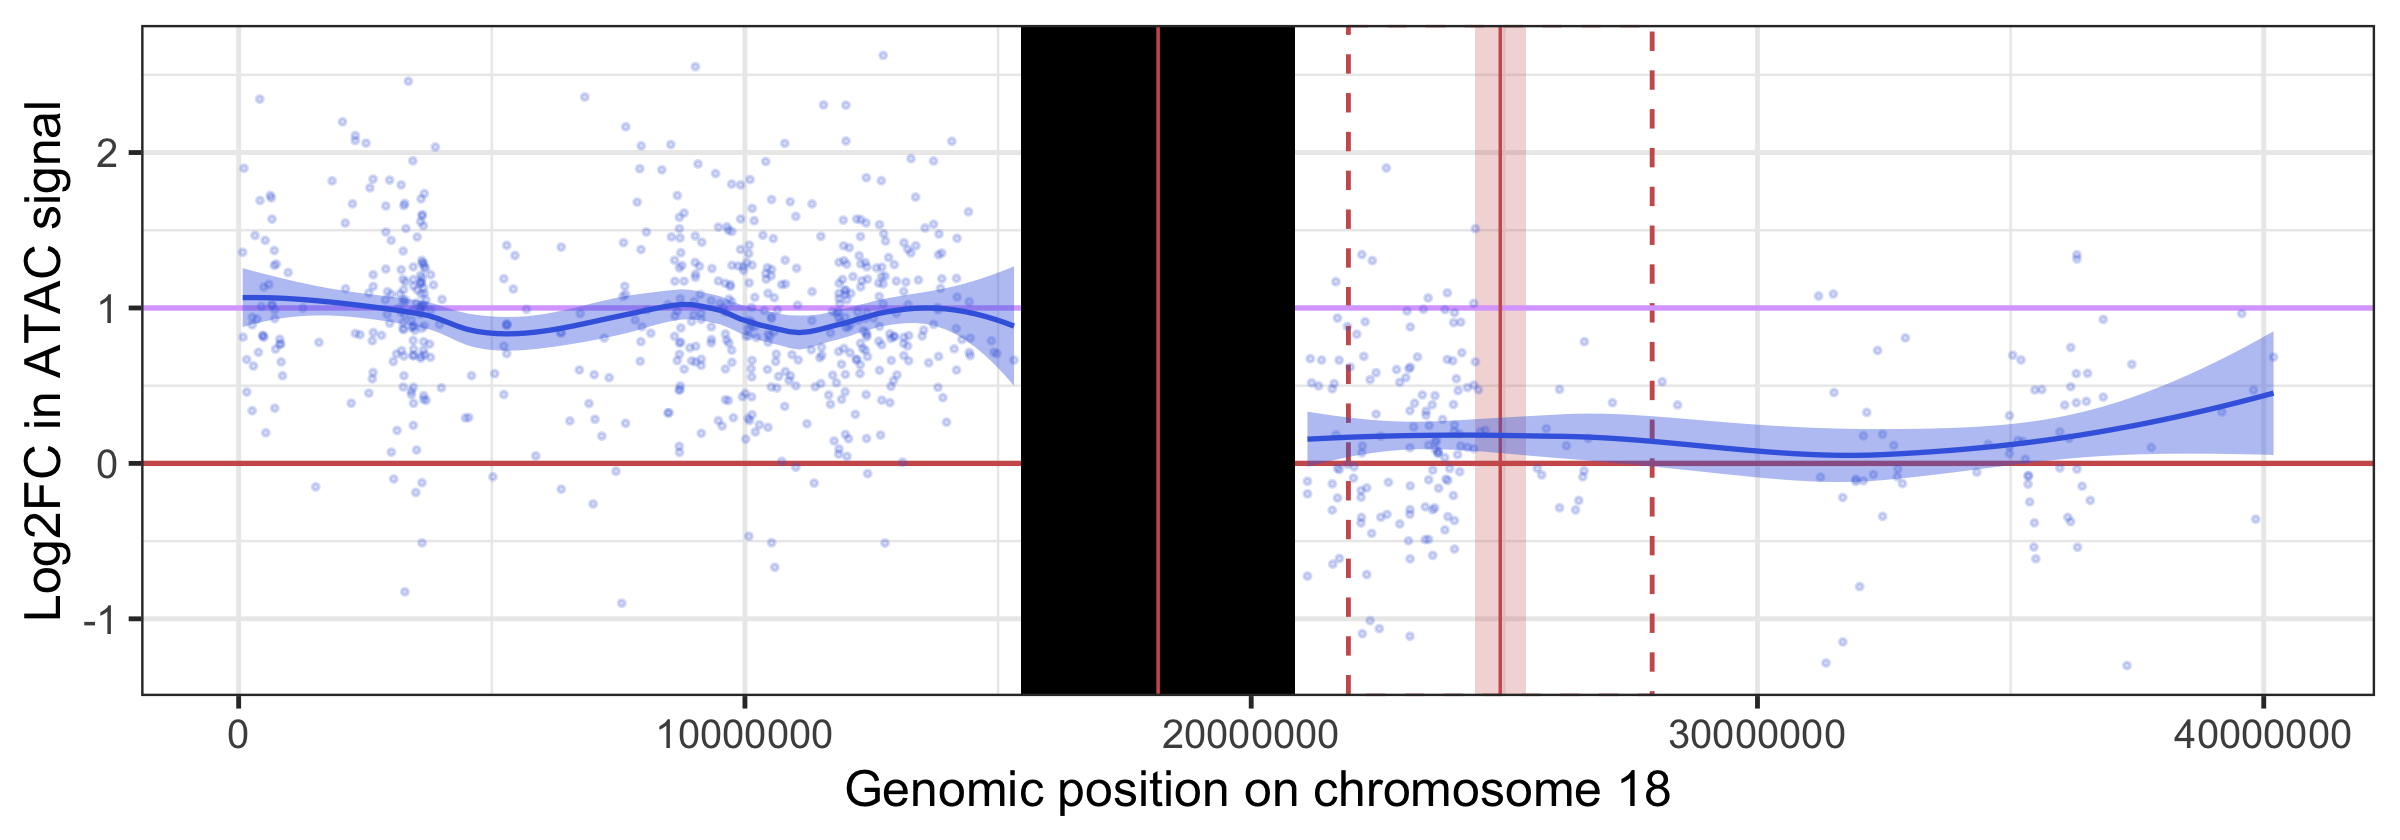

In [42]:
p1 <- ggplot() +
  geom_rect(aes(xmin=24920036-500000, xmax=24920036+500000, ymin=-Inf, ymax=Inf),
            fill = "indianred",
            alpha = 0.25)+
  geom_rect(aes(xmin=24920036-3000000, xmax=24920036+3000000, ymin=-Inf, ymax=Inf),
            color = "indianred",
            linetype = 2,
            fill = NA)+
  geom_hline(yintercept = 0, 
             color = "indianred",
             linewidth = 1.5)+
  geom_hline(yintercept = log2(2),
             color = "#dbaaff", 
             linewidth = 1.5)+
  geom_vline(xintercept =  24920036, 
             color = "indianred",
             linewidth = 1)+
  geom_point(data = peaks_scores_s, 
             aes(x = Location, y = L2FC),
             alpha = 0.2, 
             size = 1,
             color = "royalblue") +
  geom_smooth(data = peaks_scores_s[peaks_scores_s$Location <= 15460898,],
              aes(x = Location, y = L2FC),
              method = "loess",
              span = 0.5, 
              linewidth = 1.5,
              color = "royalblue", 
              se = T, 
              fill = "royalblue")+
  geom_smooth(data = peaks_scores_s[peaks_scores_s$Location > 20861206,],
              aes(x = Location, y = L2FC),
              method = "loess",
              span = 1, 
              linewidth = 1.5,
              color = "royalblue", 
              se = T, 
              fill = "royalblue")+
  geom_rect(aes(xmin=15460899, xmax=20861206, ymin=-Inf, ymax=Inf), # Black-out the centromere 
            fill= "black",
            alpha=1)+
  geom_vline(xintercept =  18161052, 
             color = "indianred",
             linewidth = 1)+
  scale_y_continuous(breaks = seq(-5, 5, by = 1),
                     minor_breaks = seq(-5, 5, by = 0.5))+
  scale_x_continuous(breaks = seq(0, 90000000, by = 10000000),
                     minor_breaks = seq(0, 90000000, by = 5000000))+
  ylab("Log2FC in ATAC signal")+
  xlab("Genomic position on chromosome 18")+
  theme_bw(base_size=30)

options(repr.plot.width=20, repr.plot.height=7)
p1

## Loss in chromosome 1

### Add clade groupings to the ArchR project and obtain BigWig files containing the ATAC signal for each clones

In [43]:
# Clone information for the loss in chromosome 1
loss_chr1 <- c()
loss_chr1[proj_fil$GeneticClade_Full %in% groups[groups$Location == "chr1:162000001-175000000" &
                                                    groups$Altered == "0",]$Clade ] <- "0"
loss_chr1[proj_fil$GeneticClade_Full %in% groups[groups$Location ==  "chr1:162000001-175000000" &
                                                    groups$Altered == "1",]$Clade ] <- "1"
loss_chr1[proj_fil$GeneticClade_Full %in% groups[groups$Location ==  "chr1:162000001-175000000" &
                                                    groups$Altered == "NA",]$Clade ] <- "NA"

# Add clone information to the project
proj_fil$loss_chr1 <- loss_chr1

# Obtain BigWig files containing the ATAC signal, normalised by reads in TSS, for each clone
getGroupBW(
  ArchRProj = proj_fil,
  groupBy = "loss_chr1",
  normMethod = "ReadsInTSS"
)

ArchR logging to : ArchRLogs/ArchR-getGroupBW-e8a97e4cbb64-Date-2026-02-24_Time-19-18-54.611652.log
If there is an issue, please report to github with logFile!

2026-02-24 19:18:55.181909 : 0 (1 of 2) : Creating BigWig for Group, 0.009 mins elapsed.

2026-02-24 19:19:23.025876 : 1 (2 of 2) : Creating BigWig for Group, 0.474 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-getGroupBW-e8a97e4cbb64-Date-2026-02-24_Time-19-18-54.611652.log



[1] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_DATAC_Results/GroupBigWigs/loss_chr1/X0-TileSize-100-normMethod-ReadsInTSS-ArchR.bw"
[2] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_DATAC_Results/GroupBigWigs/loss_chr1/X1-TileSize-100-normMethod-ReadsInTSS-ArchR.bw"

In [44]:
# Load peaks if necessary
peaks <- getPeakSet(proj_fil)

# Define the gain region, split into 500 bp intervals
start <- seq(147528175,188030870,500)
end <- start + 499
end[length(end)]<-188030870

# Create a peak matrix for chromosome 1

# GRanges object containing the peak information
peaks_info <-  GRanges(
  seqnames = Rle(c("chr1"), c(1)),
  ranges = IRanges(start, end))
peaks_info  <- subsetByOverlaps(peaks, peaks_info)

# Convert the GRanges into a matrix
peaks_info_data <- data.frame(1:length(peaks_info$peakType),
                              rep("chr1", length(peaks_info$peakType)),
                              start(peaks_info),
                              end(peaks_info),
                              peaks_info$peakType,
                              peaks_info$nearestGene,
                              peaks_info$GroupReplicate)
colnames(peaks_info_data) <- c("ID","chrom","start","end","PeakType","NearestGene","GroupReplicate")

write_csv(peaks_info_data, "../../Data/ATAC_Data/PeakData/Chr1/Chr1Loss_PeakInformation.csv")

### Compare ATAC signal in peaks between groups, respectively, with and without the copy number alteration of interest

In [45]:
# 1. Group G0

# Load the bigwig file to obtain a GRanges object with the ATAC signal ('score' column) across the genome for C0
c0_bw <- import.bw("../../Data/ArchR_Projects/Save_SW620_DATAC_Results/GroupBigWigs/loss_chr1/X0-TileSize-100-normMethod-ReadsInTSS-ArchR.bw")

# Subset the GRanges object to contain the ATAC signal for the genomic region of interest
c0_bw_sub <- GRanges(
  seqnames = Rle(c("chr1"), c(1)),
  ranges = IRanges(start, end))

c0_bw_sub <- subsetByOverlaps(c0_bw, c0_bw_sub)

# Subset the ATAC signal GRanges object to obtain the ATAC signal in peaks
peaks_c0 <- subsetByOverlaps(c0_bw_sub, peaks_info)

# Convert the GRanges object into a dataframe detailing the ATAC signal per genomic region
peaks_c0_data <- data.frame(rep("chr1", length(peaks_c0$score)),
                            start(peaks_c0),
                            end(peaks_c0),
                            peaks_c0$score)
colnames(peaks_c0_data) <- c("chrom","start","end","SN")

peaks_scores_c0 <- ATACSignalInPeaks(peaks_c0_data,peaks_info_data)

# We filter peaks whose ATAC signal are below the average ATAC signal outside of peaks - this ATAC signal is likely just background noise

# Define a GRanges object for the ATAC signal not in peaks
out_peaks_c0 <- subsetByOverlaps(c0_bw_sub, peaks_info, invert = TRUE)

# Convert the GRanges object to a dataframe
out_peaks_c0_data <- data.frame(rep("chr1", length(out_peaks_c0$score)),
                                start(out_peaks_c0),
                                end(out_peaks_c0),
                                out_peaks_c0$score)
colnames(out_peaks_c0_data) <- c("chrom","start","end","SN")

# Filter for genomic regions with positive ATAC signal (i.e., remove missingness) and define the length of genomic regions
out_peaks_c0_data <- out_peaks_c0_data %>%  dplyr::filter(SN > 0) %>% 
  dplyr::mutate(Length = end - start) 

# Compute the average ATAC signal per bp not in peaks - we distinguish regions with different copy number as higher copy number may be associated with higher background ATAC signal - 
# and select the 95th percentile

Avg_lim_d1 <-  quantile(out_peaks_c0_data[out_peaks_c0_data$end <= 161030210,]$SN/out_peaks_c0_data[out_peaks_c0_data$end <= 161030210,]$Length,0.95)

Avg_lim <-  quantile(out_peaks_c0_data[out_peaks_c0_data$end > 161030210 & 
                                         out_peaks_c0_data$end <= 174530862,]$SN/out_peaks_c0_data[out_peaks_c0_data$end > 161030210 &
                                                                                                     out_peaks_c0_data$end <= 174530862,]$Length,0.95)

Avg_lim_d2 <- quantile(out_peaks_c0_data[out_peaks_c0_data$end > 174530862,]$SN/out_peaks_c0_data[out_peaks_c0_data$end >174530862,]$Length,0.95)

# Peaks are ordered by position, we define the peak ID that delimits different copy number regions
peaks_d1_max <- max(peaks_info_data[peaks_info_data$end <= 161030210,]$ID)
peaks_max <- min(peaks_info_data[peaks_info_data$end >= 174530862,]$ID)

# Define the background ATAC signal per 500 bp peak; 
# we exclude any peaks with ATAC signal below this minimal value in our subsequent analysis

peaks_scores_c0 <- peaks_scores_c0 %>% dplyr::mutate(MinSN = case_when(Peak_ID <= peaks_d1_max ~ Avg_lim_d1*500,
                                                                       (Peak_ID > peaks_d1_max & Peak_ID <= peaks_max) ~ Avg_lim*500,
                                                                       Peak_ID  > peaks_max ~ Avg_lim_d2*500))
peaks_scores_c0 <- peaks_scores_c0 %>%  dplyr::filter(SN > MinSN)

write_csv(peaks_scores_c0, "../../Data/ATAC_Data/PeakData/Chr1/Chr1Loss_PeakScores_G0.csv")

# 2. Group G1

# Load the bigwig file to obtain a GRanges object with the ATAC signal ('score' column) across the genome for C0
c1_bw <- import.bw("../../Data/ArchR_Projects/Save_SW620_DATAC_Results/GroupBigWigs/loss_chr1/X1-TileSize-100-normMethod-ReadsInTSS-ArchR.bw")

# Subset the GRanges object to contain the ATAC signal for the genomic region of interest
c1_bw_sub <- GRanges(
  seqnames = Rle(c("chr1"), c(1)),
  ranges = IRanges(start, end))

c1_bw_sub <- subsetByOverlaps(c1_bw, c1_bw_sub)

# Subset the ATAC signal GRanges object to obtain the ATAC signal in peaks
peaks_c1 <- subsetByOverlaps(c1_bw_sub, peaks_info)

# Convert the GRanges object into a dataframe detailing the ATAC signal per genomic region
peaks_c1_data <- data.frame(rep("chr1", length(peaks_c1$score)),
                            start(peaks_c1),
                            end(peaks_c1),
                            peaks_c1$score)
colnames(peaks_c1_data) <- c("chrom","start","end","SN")

peaks_scores_c1 <- ATACSignalInPeaks(peaks_c1_data,peaks_info_data)

# We filter peaks whose ATAC signal are below the average ATAC signal outside of peaks - this ATAC signal is likely just background noise

# Define a GRanges object for the ATAC signal not in peaks
out_peaks_c1 <- subsetByOverlaps(c1_bw_sub, peaks_info, invert = TRUE)

# Convert the GRanges object to a dataframe
out_peaks_c1_data <- data.frame(rep("chr1", length(out_peaks_c1$score)),
                                start(out_peaks_c1),
                                end(out_peaks_c1),
                                out_peaks_c1$score)
colnames(out_peaks_c1_data) <- c("chrom","start","end","SN")

# Filter for genomic regions with positive ATAC signal (i.e., remove missingness) and define the length of genomic regions
out_peaks_c1_data <- out_peaks_c1_data %>%  dplyr::filter(SN > 0) %>% 
  dplyr::mutate(Length = end - start) 

# Compute the average ATAC signal per bp not in peaks - we distinguish regions with different copy number as higher copy number may be associated with higher background ATAC signal - 
# and select the 95th percentile
Avg_lim_d1 <-  quantile(out_peaks_c1_data[out_peaks_c1_data$end <= 161030210,]$SN/out_peaks_c1_data[out_peaks_c1_data$end <= 161030210,]$Length,0.95)
Avg_lim <-  quantile(out_peaks_c1_data[out_peaks_c1_data$end > 161030210 & 
                                         out_peaks_c1_data$end <= 174530862,]$SN/out_peaks_c1_data[out_peaks_c1_data$end > 161030210 &
                                                                                                     out_peaks_c1_data$end <= 174530862,]$Length,0.95)
Avg_lim_d2 <- quantile(out_peaks_c1_data[out_peaks_c1_data$end > 174530862,]$SN/out_peaks_c1_data[out_peaks_c1_data$end >174530862,]$Length,0.95)

# Peaks are ordered by position, we define the peak ID that delimits different copy number regions
peaks_d1_max <- max(peaks_info_data[peaks_info_data$end <= 161030210,]$ID)
peaks_max <- min(peaks_info_data[peaks_info_data$end >= 174530862,]$ID)

# Define the background ATAC signal per 500 bp peak; 
# we exclude any peaks with ATAC signal below this minimal value in our subsequent analysis

peaks_scores_c1 <- peaks_scores_c1 %>%  dplyr::mutate(MinSN = case_when(Peak_ID <= peaks_d1_max ~ Avg_lim_d1*500,
                                                                        (Peak_ID > peaks_d1_max & Peak_ID <= peaks_max) ~ Avg_lim*500,
                                                                        Peak_ID  > peaks_max ~ Avg_lim_d2*500))
peaks_scores_c1 <- peaks_scores_c1 %>%  dplyr::filter(SN > MinSN)

write_csv(peaks_scores_c1, "../../Data/ATAC_Data/PeakData/Chr1/Chr1Loss_PeakScores_G1.csv")


In [46]:
# We compare the ATAC signal in peaks that are shared by groups G0 and G1

shared_peaks <- intersect(peaks_scores_c0$Peak_ID,peaks_scores_c1$Peak_ID)

# Define 
peaks_scores_c0_s <- peaks_scores_c0 %>% dplyr::filter(Peak_ID %in% shared_peaks) %>%
  dplyr::rename(SN_C0 = SN)


peaks_scores_c1_s <- peaks_scores_c1 %>% dplyr::filter(Peak_ID %in% shared_peaks) %>%
  dplyr::rename(SN_C1 = SN)  


peaks_scores_s <- data.frame("Peak_ID" = peaks_scores_c0_s$Peak_ID,
                             "SN_C0" = peaks_scores_c0_s$SN_C0,
                             "SN_C1" = peaks_scores_c1_s$SN_C1)

# We set each peak's location at its midpoint
loc <- peaks_info_data[peaks_info_data$ID %in% peaks_scores_s$Peak_ID,]$start +
  (peaks_info_data[peaks_info_data$ID %in% peaks_scores_s$Peak_ID,]$end-
     peaks_info_data[peaks_info_data$ID %in% peaks_scores_s$Peak_ID,]$start)/2


peaks_scores_s <- peaks_scores_s %>% dplyr::mutate(Region = case_when(Peak_ID <= peaks_d1_max ~ "Shared diploid - left",
                                                                      (Peak_ID > peaks_d1_max & Peak_ID <= peaks_max) ~ "Loss in C1",
                                                                      Peak_ID  > peaks_max ~ "Shared diploid - right")) %>%
  dplyr::mutate(L2FC = log2(SN_C1/SN_C0)) %>%
  dplyr::mutate(Location = loc)

write_csv(peaks_scores_s,"../../Data/ATAC_Data/PeakData/Chr1/Chr1Loss_PeakScores_G0vG1_Comparison_SourceData.csv")


Rows: 1362052 Columns: 5
── Column specification ──────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): cell_id, chrom
dbl (3): start, end, state

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


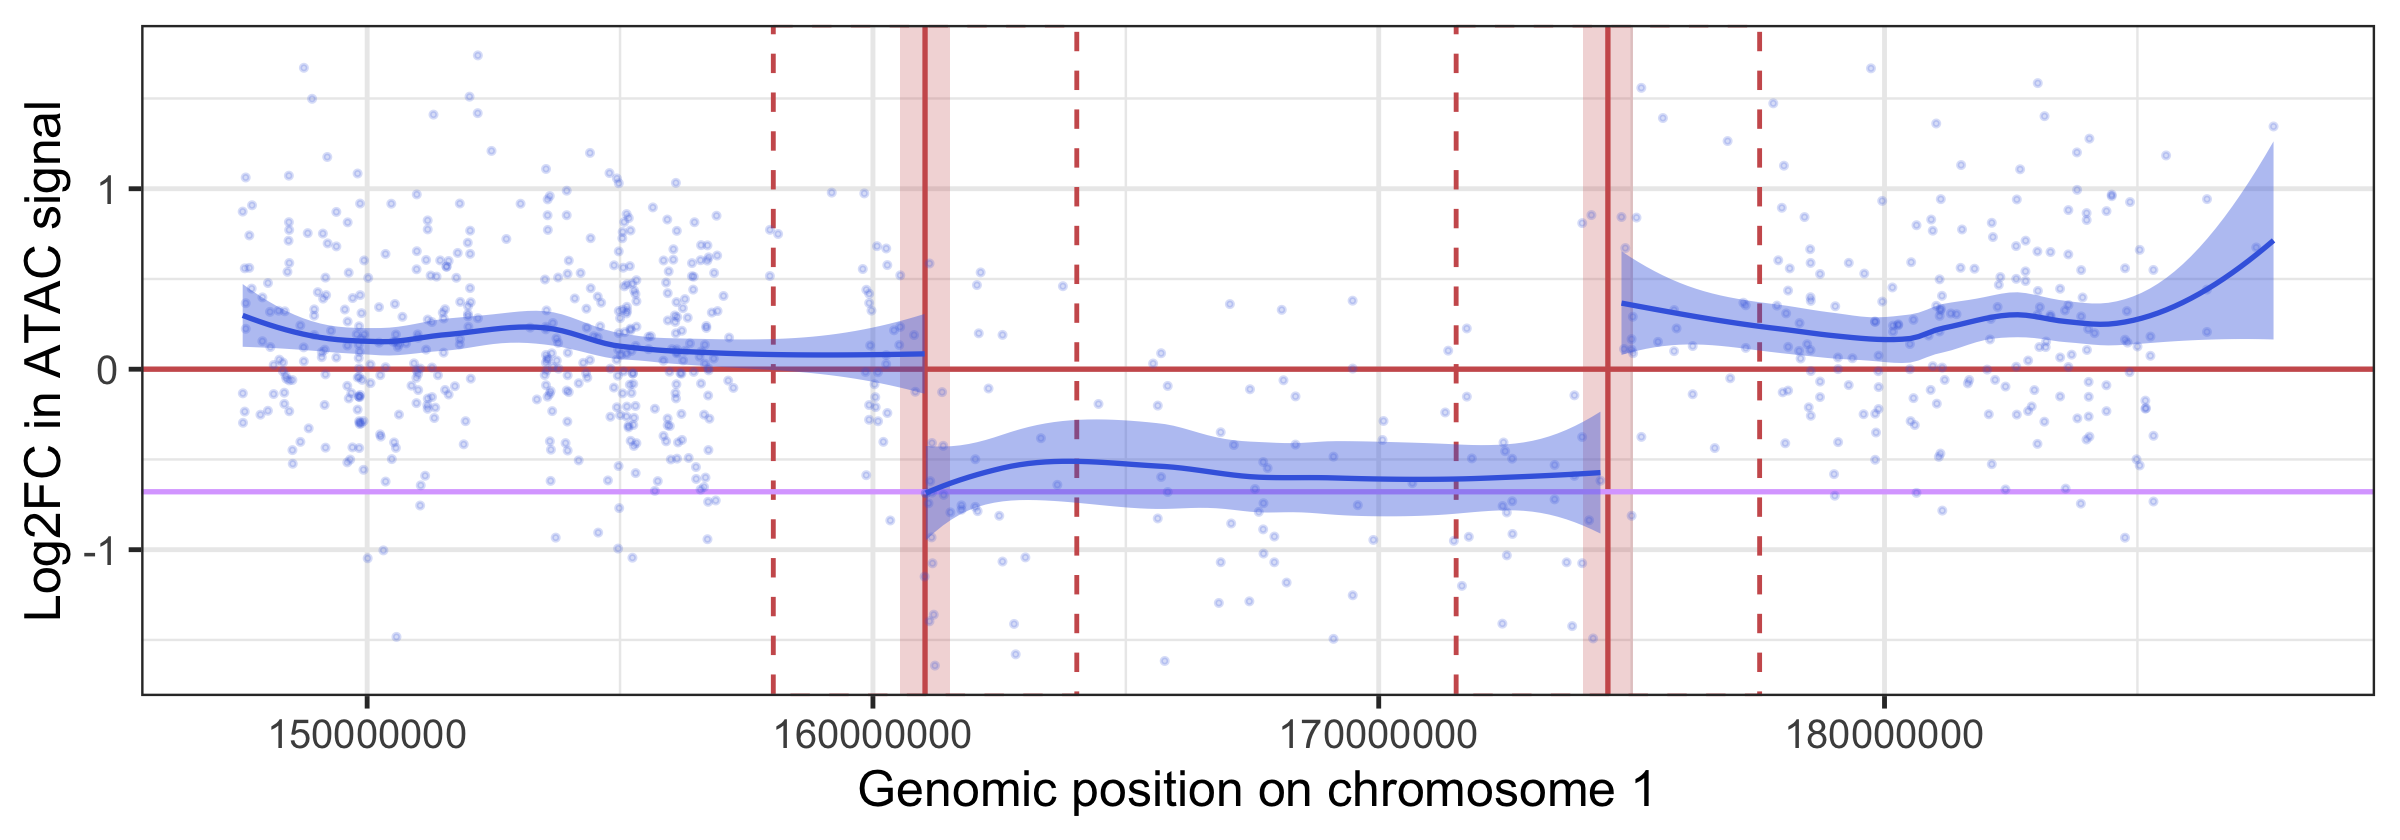

In [74]:
cna_data <- read_tsv("../../Data/CNA_Data/Processed/CNA_Profiles_Segmented_Original.tsv")
clades <- data.frame(read_csv("../../Data/CNA_Data/Processed/Genetic_Clades_And_SuperClades.csv",
                              col_types = "ccc"))

expected_change_loss <- mean(cna_data[cna_data$cell_id %in% clades[clades$Clade %in% groups[groups$Location == "chr1:162000001-175000000" & groups$Altered == "1",]$Clade,]$Cell_id & 
                                        cna_data$chrom == "chr1" &
                                        (cna_data$end >= 161000000 & cna_data$end <= 175000000),]$state)/mean(cna_data[cna_data$cell_id %in% clades[clades$Clade %in% groups[groups$Location == "chr1:162000001-175000000" & groups$Altered == "0",]$Clade,]$Cell_id & 
                                                                                                                         cna_data$chrom == "chr1" &
                                                                                                                         (cna_data$end >= 161000000 & cna_data$end <= 175000000),]$state)

expected_change_dip <- mean(cna_data[cna_data$cell_id %in% clades[clades$Clade %in% groups[groups$Location == "chr1:162000001-175000000" & groups$Altered == "1",]$Clade,]$Cell_id & 
                                       cna_data$chrom == "chr1" &
                                       (cna_data$end < 161000000 | cna_data$end > 175000000),]$state)/mean(cna_data[cna_data$cell_id %in% clades[clades$Clade %in% groups[groups$Location == "chr1:162000001-175000000" & groups$Altered == "1",]$Clade,]$Cell_id & 
                                                                                                                      cna_data$chrom == "chr1" &
                                                                                                                      (cna_data$end < 112000000 | cna_data$end > 175000000),]$state)  

p <- ggplot() +
  geom_rect(aes(xmin=161030210-500000, xmax=161030210+500000,ymin=-Inf, ymax=Inf),
            fill = "indianred",
            alpha = 0.25)+
  geom_rect(aes(xmin=174530862-500000, xmax=174530862+500000, ymin=-Inf, ymax=Inf),
            fill = "indianred",
            alpha = 0.25)+
  geom_rect(aes(xmin=161030210-3000000, xmax=161030210+3000000, ymin=-Inf, ymax=Inf),
            color = "indianred", linetype = 2,
            fill = NA,alpha = 0.25)+
  geom_rect(aes(xmin=174530862-3000000, xmax=174530862+3000000, ymin=-Inf, ymax=Inf),
            color = "indianred", linetype = 2,
            fill = NA,alpha = 0.25)+
  geom_vline(xintercept = 161030210,
             color = "indianred", linewidth = 1.5)+
  geom_vline(xintercept = 174530862,
             color = "indianred", linewidth = 1.5)+
  geom_hline(yintercept = log2(expected_change_dip),
             color = "indianred", linewidth = 1.5)+
  geom_hline(yintercept = log2(expected_change_loss),
             color = "#dbaaff", linewidth = 1.5)+
  geom_point(data = peaks_scores_s, 
             aes(x = Location, y = L2FC),
             alpha = 0.2, 
             size = 1,
             color = "royalblue") +
  geom_smooth(data = peaks_scores_s[peaks_scores_s$Location <= 161030210,],
              aes(x = Location, y = L2FC),
              method = "loess",
              span = 0.75, 
              linewidth = 1.5,
              color = "royalblue", 
              se = T, 
              fill = "royalblue")+
  geom_smooth(data = peaks_scores_s[peaks_scores_s$Location > 161030210 & peaks_scores_s$Location < 174530862,],
              aes(x = Location, y = L2FC),
              method = "loess",
              span = 0.75,
              linewidth = 1.5,
              color = "royalblue",
              se = T,
              fill = "royalblue")+
  geom_smooth(data = peaks_scores_s[peaks_scores_s$Location >= 174530862,], aes(x = Location, y = L2FC),
              method = "loess",
              span = 0.75, 
              linewidth = 1.5,
              color = "royalblue",
              se = T,
              fill = "royalblue")+
  scale_y_continuous(breaks = seq(-5, 5, by = 1),
                     minor_breaks = seq(-5, 5, by = 0.5))+
  scale_x_continuous(breaks = seq(150000000, 300000000, by = 10000000),
                     minor_breaks = seq(150000000, 300000000, by = 5000000))+
  ylab("Log2FC in ATAC signal")+
  xlab("Genomic position on chromosome 1")+
  theme_bw(base_size=30)
options(repr.plot.width=20, repr.plot.height=7)
p

### Breakpoint analysis

We test whether there are significant differences in ATAC signal between groups G0 and G1 around the copy number alteration breakpoints. To do so, we compare the mean L2FC of peaks at a fixed distance from the breakpoints to the mean L2FC of peaks at a fixed distance from randomly selected loci away from breakpoints.

#### True mean L2FC

In [75]:
# Find the peaks which are flanking the breakpoints, at distances varying 100 kB to 3 Mb

b1 <- 161030210
b2 <-  174530862

distances <- c(100000,250000,500000,750000,1000000,1500000)
peaks_around_bp <-  data.frame(Peak_ID = double(),
                               distance = double(),
                               bp = character())
for (distance in distances){
  inds_b1l <- which(peaks_info_data$start >= b1-distance & peaks_info_data$end <= b1)
  peaks_around_bp <- rbind(peaks_around_bp, 
                           cbind(peaks_info_data$ID[inds_b1l],
                                 rep(distance,length(inds_b1l)),
                                 rep("B1_L",length(inds_b1l))))
  
  
  
  inds_b1r <- which(peaks_info_data$start >= b1 & peaks_info_data$end <= b1+distance)
  peaks_around_bp <- rbind(peaks_around_bp, 
                           cbind(peaks_info_data$ID[inds_b1r],
                                 rep(distance,length(inds_b1r)),
                                 rep("B1_R",length(inds_b1r))))
  
  
  inds_b2r <- which(peaks_info_data$start >= b2 & peaks_info_data$end <= b2+distance)
  peaks_around_bp <- rbind(peaks_around_bp, 
                           cbind(peaks_info_data$ID[inds_b2r],
                                 rep(distance,length(inds_b2r)),
                                 rep("B2_R",length(inds_b2r))))
  
  inds_b2l <- which(peaks_info_data$start >= b2-distance & peaks_info_data$end <= b2)
  peaks_around_bp <- rbind(peaks_around_bp, 
                           cbind(peaks_info_data$ID[inds_b2l],
                                 rep(distance,length(inds_b2l)),
                                 rep("B2_L",length(inds_b2l))))
}
colnames(peaks_around_bp) <- c("Peak_ID","DistanceFromBreakpoint","Breakpoint")

write_csv(peaks_around_bp,"../../Data/ATAC_Data/PeakData/Chr1/Chr1Loss_PeaksFlankingBreakpoints.csv")

# Cumulative shared peak signal around the breakpoints - true loci flanking breakpoints

# 1. Left breakpoint, right-side
peaks_scores_around_bp_b1r <-  data.frame(distance = double(),
                                          L2FC = double())

for (distance in distances) {
  s0 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_bp[peaks_around_bp$DistanceFromBreakpoint == distance &
                                                                     peaks_around_bp$Breakpoint == "B1_R",]$Peak_ID,]$SN_C0
  s1 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_bp[peaks_around_bp$DistanceFromBreakpoint == distance &
                                                                     peaks_around_bp$Breakpoint == "B1_R",]$Peak_ID,]$SN_C1
  
  peaks_scores_around_bp_b1r <- rbind(peaks_scores_around_bp_b1r, cbind(distance, sum(log2(s1/s0))/length(s0),"B1_R"))
}

colnames(peaks_scores_around_bp_b1r) <- c("DistanceFromBreakpoint","MeanL2FC","Breakpoint")
peaks_scores_around_bp_b1r$DistanceFromBreakpoint <- factor(as.character(peaks_scores_around_bp_b1r$DistanceFromBreakpoint),
                                                            levels = c("100000","250000","500000",
                                                                       "750000","1000000","1500000"))

# 2. Left breakpoint, left-side
peaks_scores_around_bp_b1l <-  data.frame(distance = double(),
                                          L2FC = double())

for (distance in distances) {
  s0 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_bp[peaks_around_bp$DistanceFromBreakpoint == distance &
                                                                     peaks_around_bp$Breakpoint == "B1_L",]$Peak_ID,]$SN_C0
  s1 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_bp[peaks_around_bp$DistanceFromBreakpoint == distance &
                                                                     peaks_around_bp$Breakpoint == "B1_L",]$Peak_ID,]$SN_C1
  
  peaks_scores_around_bp_b1l <- rbind(peaks_scores_around_bp_b1l, cbind(distance, sum(log2(s1/s0))/length(s0),"B1_L"))
}

colnames(peaks_scores_around_bp_b1l) <- c("DistanceFromBreakpoint","MeanL2FC","Breakpoint")
peaks_scores_around_bp_b1l$DistanceFromBreakpoint <- factor(as.character(peaks_scores_around_bp_b1l$DistanceFromBreakpoint),
                                                            levels = c("100000","250000","500000",
                                                                       "750000","1000000","1500000"))

# 3. Right breakpoint, left-side
peaks_scores_around_bp_b2l <-  data.frame(distance = double(),
                                          L2FC = double())

for (distance in distances) {
  s0 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_bp[peaks_around_bp$DistanceFromBreakpoint == distance &
                                                                     peaks_around_bp$Breakpoint == "B2_L",]$Peak_ID,]$SN_C0
  s1 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_bp[peaks_around_bp$DistanceFromBreakpoint == distance &
                                                                     peaks_around_bp$Breakpoint == "B2_L",]$Peak_ID,]$SN_C1
  
  peaks_scores_around_bp_b2l <- rbind(peaks_scores_around_bp_b2l, cbind(distance, sum(log2(s1/s0))/length(s0),"B2_L"))
}

colnames(peaks_scores_around_bp_b2l) <- c("DistanceFromBreakpoint","MeanL2FC","Breakpoint")
peaks_scores_around_bp_b2l$DistanceFromBreakpoint <- factor(as.character(peaks_scores_around_bp_b2l$DistanceFromBreakpoint),
                                                            levels = c("100000","250000","500000",
                                                                       "750000","1000000","1500000"))


# 4. Right breakpoint, right-side
peaks_scores_around_bp_b2r <-  data.frame(distance = double(),
                                          L2FC = double())

for (distance in distances) {
  s0 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_bp[peaks_around_bp$DistanceFromBreakpoint == distance &
                                                                     peaks_around_bp$Breakpoint == "B2_R",]$Peak_ID,]$SN_C0
  s1 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_bp[peaks_around_bp$DistanceFromBreakpoint == distance &
                                                                     peaks_around_bp$Breakpoint == "B2_R",]$Peak_ID,]$SN_C1
  
  peaks_scores_around_bp_b2r <- rbind(peaks_scores_around_bp_b2r, cbind(distance, sum(log2(s1/s0))/length(s0),"B2_R"))
}

colnames(peaks_scores_around_bp_b2r) <- c("DistanceFromBreakpoint","MeanL2FC","Breakpoint")
peaks_scores_around_bp_b2r$DistanceFromBreakpoint <- factor(as.character(peaks_scores_around_bp_b2r$DistanceFromBreakpoint),
                                                            levels = c("100000","250000","500000",
                                                                       "750000","1000000","1500000"))

#peaks_scores_around_bp_b2r

peaks_scores_around_bp_all <- rbind(peaks_scores_around_bp_b1l,
                                    peaks_scores_around_bp_b1r,
                                    peaks_scores_around_bp_b2l,
                                    peaks_scores_around_bp_b2r)

peaks_scores_around_bp_all$MeanL2FC <- as.numeric(peaks_scores_around_bp_all$MeanL2FC)

peaks_scores_around_bp_all$DistanceFromBreakpoint <- factor(as.character(peaks_scores_around_bp_all$DistanceFromBreakpoint),
                                                            levels = c("100000","250000","500000",
                                                                       "750000","1000000","1500000"))

write_csv(peaks_scores_around_bp_all,"../../Data/ATAC_Data/PeakData/Chr1/Chr1Loss_PeaksFlankingBreakpoints_TrueMeanL2FC.csv")



#### Mean L2FC around random loci (null distribution)

In [ ]:
# Select random loci 

s <- 147528175
b1 <- 161030210
b2 <- 174530862
e <- 188030870

set.seed(123)

loci_b1l <- round(runif(1000, s+1500000, b1-1500000))
loci_b1r <- round(runif(1000, b1+1500000, b2-1500000))
loci_b2l <- round(runif(1000, b1+1500000, b2-1500000))
loci_b2r <- round(runif(1000, b2+1500000, e-1500000))


peaks_around_random_bp <-  data.frame(Locus = double(),
                                      Peak_ID = double(),
                                      distance = double(),
                                      bp = character())


for (l in loci_b1l){
  for (distance in distances){
    inds <- which(peaks_info_data$start >= (l-distance) & peaks_info_data$end <= l)
    peaks_around_random_bp <- rbind(peaks_around_random_bp, 
                                    cbind(rep(l,length(inds)),
                                          peaks_info_data$ID[inds],
                                          rep(distance,length(inds)),
                                          rep("B1_L",length(inds))))
  }
}
for (l in loci_b1r){
  for (distance in distances){
    inds <- which(peaks_info_data$start >= l & peaks_info_data$end <= l+distance)
    peaks_around_random_bp <- rbind(peaks_around_random_bp, 
                                    cbind(rep(l,length(inds)),
                                          peaks_info_data$ID[inds],
                                          rep(distance,length(inds)),
                                          rep("B1_R",length(inds))))
  }
}

for (l in loci_b2l){
  for (distance in distances){
    inds <- which(peaks_info_data$start >= (l-distance) & peaks_info_data$end <= l)
    peaks_around_random_bp <- rbind(peaks_around_random_bp, 
                                    cbind(rep(l,length(inds)),
                                          peaks_info_data$ID[inds],
                                          rep(distance,length(inds)),
                                          rep("B2_L",length(inds))))
  }
}

for (l in loci_b2r){
  for (distance in distances){
    inds <- which(peaks_info_data$start >= l & peaks_info_data$end <= l+distance)
    peaks_around_random_bp <- rbind(peaks_around_random_bp, 
                                    cbind(rep(l,length(inds)),
                                          peaks_info_data$ID[inds],
                                          rep(distance,length(inds)),
                                          rep("B2_R",length(inds))))
  }
}

colnames(peaks_around_random_bp) <- c("Locus","Peak_ID","DistanceFromBreakpoint","Breakpoint")

write_csv(peaks_around_random_bp,"../../Data/ATAC_Data/PeakData/Chr1/Chr1Loss_PeaksFlankingBreakpoints_RandomLoci.csv")


# Cumulative shared peak signal around the breakpoints - random loci

# 1. Left breakpoint, left-side
peak_scores_around_random_bp_b1l <-  data.frame(distance = double(),
                                                L2FC = double())

for (l in loci_b1l){
  for (distance in distances) {
    
    s0 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_random_bp[peaks_around_random_bp$DistanceFromBreakpoint == distance &
                                                                              peaks_around_random_bp$Locus == l & peaks_around_random_bp$Breakpoint == "B1_L",]$Peak_ID,]$SN_C0
    s1 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_random_bp[peaks_around_random_bp$DistanceFromBreakpoint == distance &
                                                                              peaks_around_random_bp$Locus == l & peaks_around_random_bp$Breakpoint == "B1_L",]$Peak_ID,]$SN_C1
    
    
    peak_scores_around_random_bp_b1l <- rbind(peak_scores_around_random_bp_b1l, cbind(distance, sum(log2(s1/s0))/length(s0), "B1_L"))
  }
}

colnames(peak_scores_around_random_bp_b1l) <- c("DistanceFromBreakpoint","MeanL2FC","Breakpoint")
peak_scores_around_random_bp_b1l <- na.omit(peak_scores_around_random_bp_b1l)
peak_scores_around_random_bp_b1l$DistanceFromBreakpoint <- factor(as.character(peak_scores_around_random_bp_b1l$DistanceFromBreakpoint),
                                                                  levels = c("100000","250000","500000",
                                                                             "750000","1000000","1500000"))

# 2. Left breakpoint, right-side

peak_scores_around_random_bp_b1r <-  data.frame(distance = double(),
                                                L2FC = double())

for (l in loci_b1r){
  for (distance in distances) {
    
    s0 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_random_bp[peaks_around_random_bp$DistanceFromBreakpoint == distance &
                                                                              peaks_around_random_bp$Locus == l & peaks_around_random_bp$Breakpoint == "B1_R",]$Peak_ID,]$SN_C0
    s1 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_random_bp[peaks_around_random_bp$DistanceFromBreakpoint == distance &
                                                                              peaks_around_random_bp$Locus == l & peaks_around_random_bp$Breakpoint == "B1_R",]$Peak_ID,]$SN_C1
    
    
    peak_scores_around_random_bp_b1r <- rbind(peak_scores_around_random_bp_b1r, cbind(distance, sum(log2(s1/s0))/length(s0), "B1_R"))
  }
}

colnames(peak_scores_around_random_bp_b1r) <- c("DistanceFromBreakpoint","MeanL2FC","Breakpoint")
peak_scores_around_random_bp_b1r <- na.omit(peak_scores_around_random_bp_b1r)
peak_scores_around_random_bp_b1r$DistanceFromBreakpoint <- factor(as.character(peak_scores_around_random_bp_b1r$DistanceFromBreakpoint),
                                                                  levels = c("100000","250000","500000",
                                                                             "750000","1000000","1500000"))

# 3. Right breakpoint, left-side
peak_scores_around_random_bp_b2l <-  data.frame(distance = double(),
                                                L2FC = double())

for (l in loci_b2l){
  for (distance in distances) {
    
    s0 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_random_bp[peaks_around_random_bp$DistanceFromBreakpoint == distance &
                                                                              peaks_around_random_bp$Locus == l & peaks_around_random_bp$Breakpoint == "B2_L",]$Peak_ID,]$SN_C0
    s1 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_random_bp[peaks_around_random_bp$DistanceFromBreakpoint == distance &
                                                                              peaks_around_random_bp$Locus == l & peaks_around_random_bp$Breakpoint == "B2_L",]$Peak_ID,]$SN_C1
    
    
    peak_scores_around_random_bp_b2l <- rbind(peak_scores_around_random_bp_b2l, cbind(distance, sum(log2(s1/s0))/length(s0), "B2_L"))
  }
}

colnames(peak_scores_around_random_bp_b2l) <- c("DistanceFromBreakpoint","MeanL2FC","Breakpoint")
peak_scores_around_random_bp_b2l <- na.omit(peak_scores_around_random_bp_b2l)
peak_scores_around_random_bp_b2l$DistanceFromBreakpoint <- factor(as.character(peak_scores_around_random_bp_b2l$DistanceFromBreakpoint),
                                                                  levels = c("100000","250000","500000",
                                                                             "750000","1000000","1500000"))

# 4. Right breakpoint, right-side

peak_scores_around_random_bp_b2r <-  data.frame(distance = double(),
                                                L2FC = double())

for (l in loci_b2r){
  for (distance in distances) {
    
    s0 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_random_bp[peaks_around_random_bp$DistanceFromBreakpoint == distance &
                                                                              peaks_around_random_bp$Locus == l & peaks_around_random_bp$Breakpoint == "B2_R",]$Peak_ID,]$SN_C0
    s1 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_random_bp[peaks_around_random_bp$DistanceFromBreakpoint == distance &
                                                                              peaks_around_random_bp$Locus == l & peaks_around_random_bp$Breakpoint == "B2_R",]$Peak_ID,]$SN_C1
    
    
    peak_scores_around_random_bp_b2r <- rbind(peak_scores_around_random_bp_b2r, cbind(distance, sum(log2(s1/s0))/length(s0), "B2_R"))
  }
}

colnames(peak_scores_around_random_bp_b2r) <- c("DistanceFromBreakpoint","MeanL2FC","Breakpoint")
peak_scores_around_random_bp_b2r <- na.omit(peak_scores_around_random_bp_b2r)
peak_scores_around_random_bp_b2r$DistanceFromBreakpoint <- factor(as.character(peak_scores_around_random_bp_b2r$DistanceFromBreakpoint),
                                                                  levels = c("100000","250000","500000",
                                                                             "750000","1000000","1500000"))

peaks_scores_around_random_bp_all <- rbind(peak_scores_around_random_bp_b1l,
                                           peak_scores_around_random_bp_b1r,
                                           peak_scores_around_random_bp_b2l,
                                           peak_scores_around_random_bp_b2r)

peaks_scores_around_random_bp_all$MeanL2FC <- as.numeric(peaks_scores_around_random_bp_all$MeanL2FC)

peaks_scores_around_random_bp_all$DistanceFromBreakpoint <- factor(as.character(peaks_scores_around_random_bp_all$DistanceFromBreakpoint),
                                                                   levels = c("100000","250000","500000",
                                                                              "750000","1000000","1500000"))

write_csv(peaks_scores_around_random_bp_all,"../../Data/ATAC_Data/PeakData/Chr1/Chr1Loss_PeaksFlankingBreakpoints_RandomLoci_SimulatedMeanL2FC.csv")


In [76]:
# Load the simulated and true data
peaks_scores_around_random_bp_all <- read_csv("../../Data/ATAC_Data/PeakData/Chr1/Chr1Loss_PeaksFlankingBreakpoints_RandomLoci_SimulatedMeanL2FC.csv",
                                              col_types = "cdc")
peaks_scores_around_bp_all <- read_csv("../../Data/ATAC_Data/PeakData/Chr1/Chr1Loss_PeaksFlankingBreakpoints_TrueMeanL2FC.csv",
                                       col_types = "cdc")

peaks_scores_around_random_bp_all$DistanceFromBreakpoint <- factor(as.character(peaks_scores_around_random_bp_all$DistanceFromBreakpoint),
                                                                   levels = c("100000","250000","500000",
                                                                              "750000","1000000","1500000"))
peaks_scores_around_bp_all$DistanceFromBreakpoint <- factor(as.character(peaks_scores_around_bp_all$DistanceFromBreakpoint),
                                                            levels = c("100000","250000","500000",
                                                                       "750000","1000000","1500000"))

distance.labs <- c("100000" = "100kb", "250000" = "250kb",
                   "500000" = "500kb", "750000" = "750kb",
                   "1000000" = "1Mb",  "1500000" = "1.5Mb")


#### 1st breakpoint: left

Warning message:
“Removed 568 rows containing non-finite outside the scale range (`stat_bin()`).”


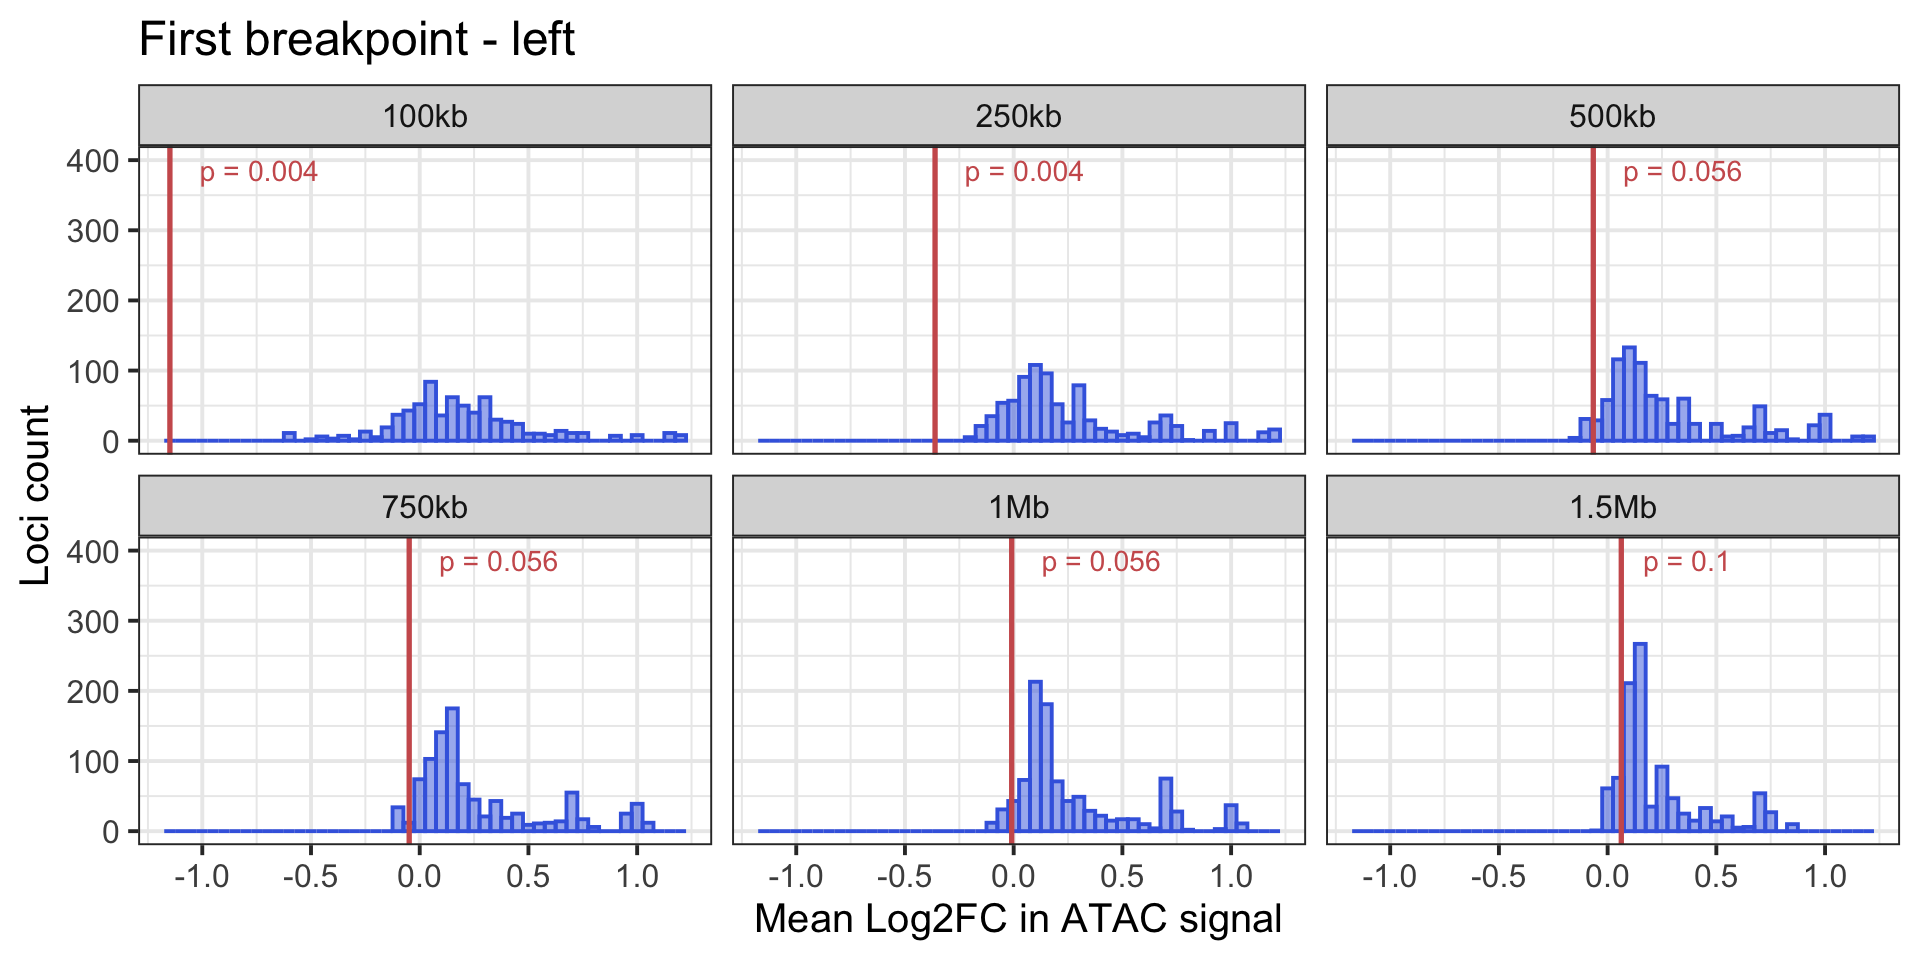

In [78]:
pval <- pValueL(peaks_scores_around_random_bp_all[peaks_scores_around_random_bp_all$Breakpoint == "B1_L",],
                peaks_scores_around_bp_all[peaks_scores_around_bp_all$Breakpoint == "B1_L",],
                "DistanceFromBreakpoint",
                "MeanL2FC")

pval$DistanceFromBreakpoint <- factor(as.character(pval$DistanceFromBreakpoint),
                                      levels = c("100000","250000","500000",
                                                 "750000","1000000","1500000"))


p <- ggplot(peaks_scores_around_random_bp_all[peaks_scores_around_random_bp_all$Breakpoint == "B1_L",],
            aes(x = MeanL2FC,group = DistanceFromBreakpoint))+
  geom_histogram(binwidth = 0.05, alpha = 0.5, color = "royalblue", fill = "royalblue") +
  geom_vline(data = peaks_scores_around_bp_all[peaks_scores_around_bp_all$Breakpoint == "B1_L",],
             aes(xintercept = MeanL2FC,group = DistanceFromBreakpoint),
             color = "indianred",linewidth=1.5  ) +
  geom_text(data = pval, aes(x = xvalue, y = 400, label = label, group = DistanceFromBreakpoint), 
            vjust = 1, hjust = -0.25, color = "indianred", size = 6)+
  guides(fill = "none", color = "none")+
  ylab("Loci count")+
  xlab("Mean Log2FC in ATAC signal") +
  ggtitle("First breakpoint - left")+
  facet_wrap(vars(DistanceFromBreakpoint),
             nrow = 2,
             labeller = labeller(DistanceFromBreakpoint = distance.labs))+
  theme_bw(base_size = 24)

options(repr.plot.width=16, repr.plot.height=8)
p


#### 1st breakpoint: right

Warning message:
“Removed 1307 rows containing non-finite outside the scale range (`stat_bin()`).”


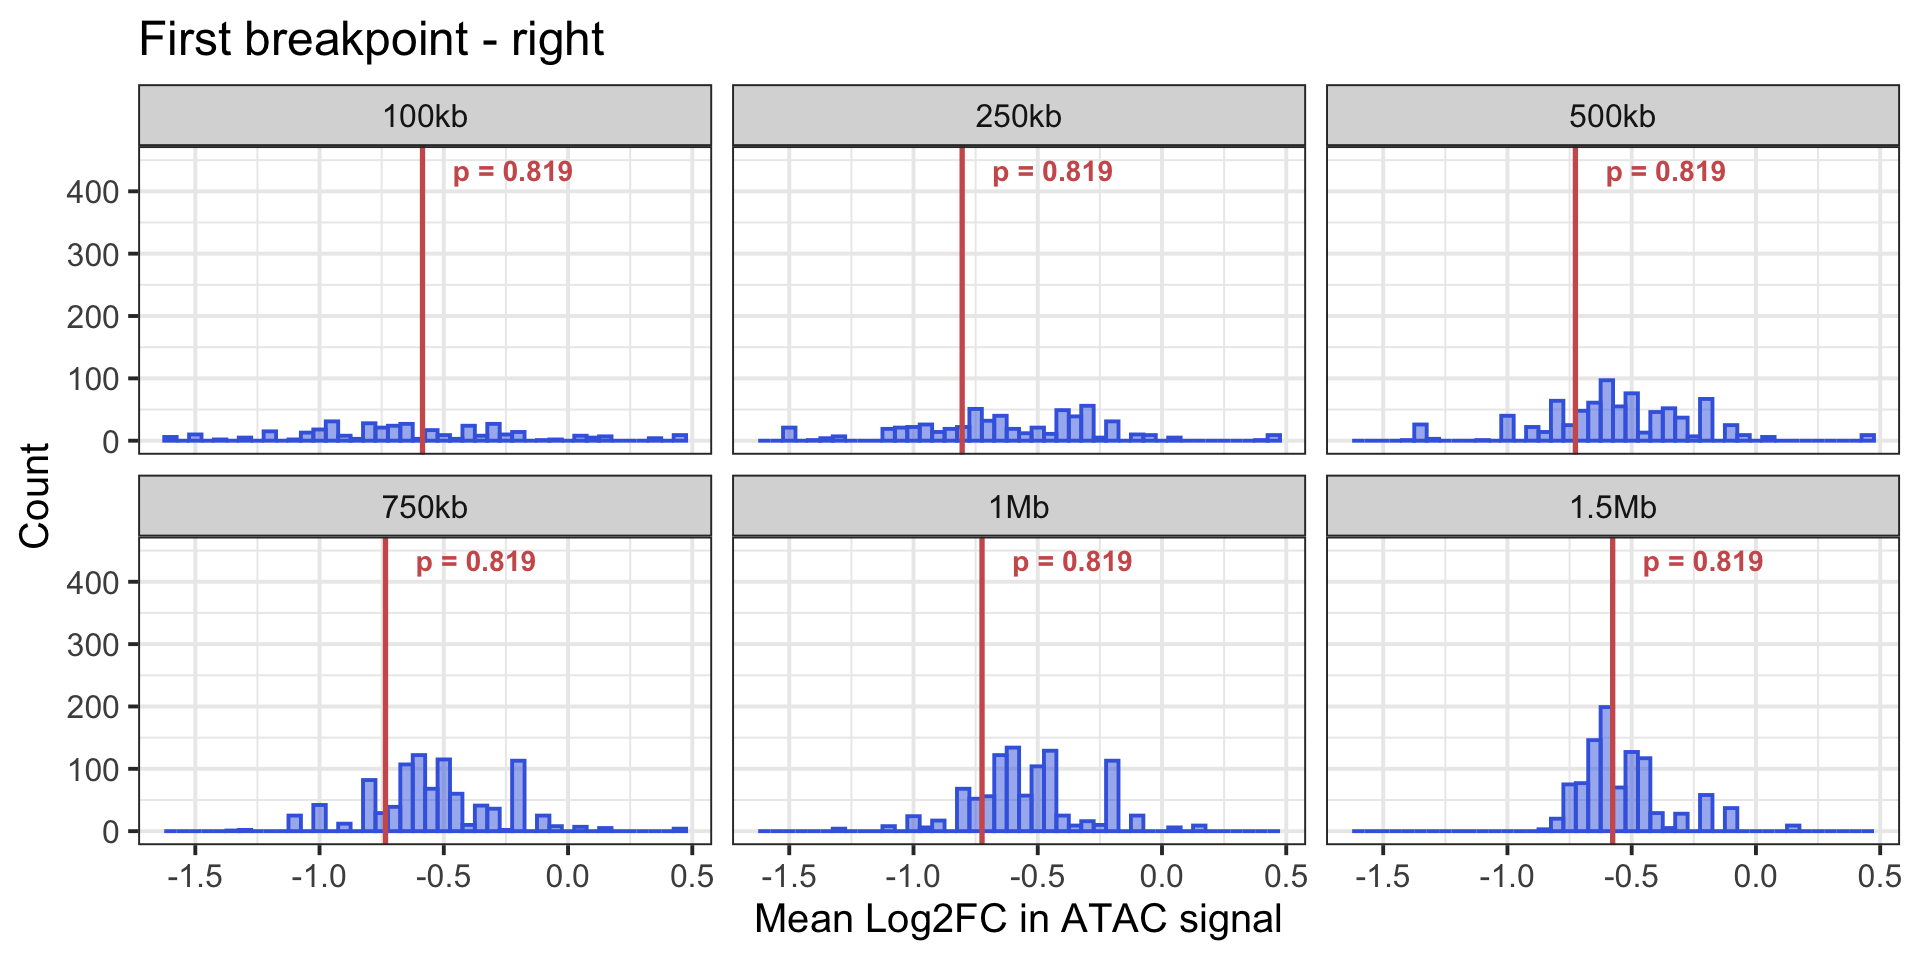

In [79]:
pval <- pValueH(peaks_scores_around_random_bp_all[peaks_scores_around_random_bp_all$Breakpoint == "B1_R",],
                peaks_scores_around_bp_all[peaks_scores_around_bp_all$Breakpoint == "B1_R",],
                "DistanceFromBreakpoint",
                "MeanL2FC")

pval$DistanceFromBreakpoint <- factor(as.character(pval$DistanceFromBreakpoint),
                                      levels = c("100000","250000","500000",
                                                 "750000","1000000","1500000"))



p <- ggplot(peaks_scores_around_random_bp_all[peaks_scores_around_random_bp_all$Breakpoint == "B1_R",],
            aes(x = MeanL2FC,group = DistanceFromBreakpoint))+
  geom_histogram(binwidth = 0.05, alpha = 0.5, color = "royalblue", fill = "royalblue") +
  geom_vline(data = peaks_scores_around_bp_all[peaks_scores_around_bp_all$Breakpoint == "B1_R",],
             aes(xintercept = MeanL2FC,group = DistanceFromBreakpoint), color = "indianred",linewidth=1.5  ) +
  geom_text(data = pval, aes(x = xvalue, y = 450, label = label, group = DistanceFromBreakpoint), 
            vjust = 1, hjust = -0.25, fontface = "bold",color = "indianred", size = 6)+
  guides(fill = "none", color = "none")+
  ylab("Count")+
  xlab("Mean Log2FC in ATAC signal") +
  ggtitle("First breakpoint - right")+
  facet_wrap(vars(DistanceFromBreakpoint),
             nrow = 2,
             labeller = labeller(DistanceFromBreakpoint = distance.labs))+
  theme_bw(base_size = 24)

options(repr.plot.width=16, repr.plot.height=8)
p

#### 2nd breakpoint: left

Warning message:
“Removed 1279 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_vline()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_text()`).”


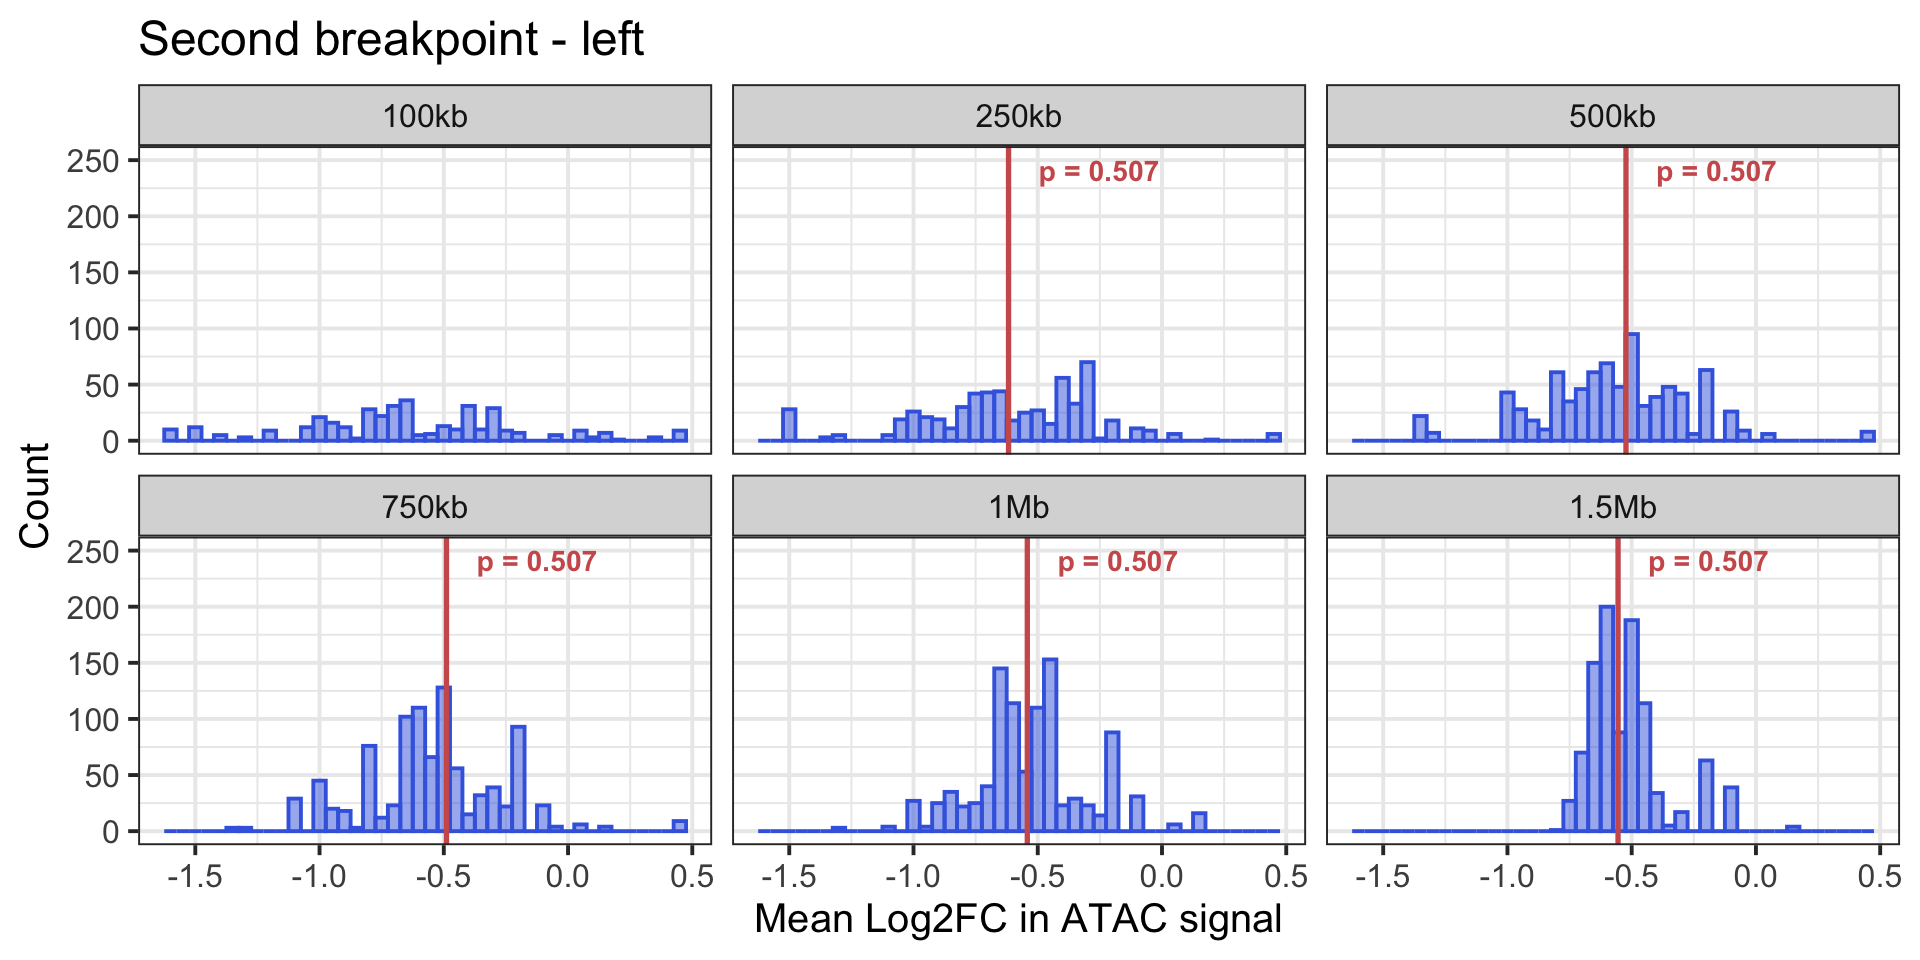

In [81]:
pval <- pValueH(peaks_scores_around_random_bp_all[peaks_scores_around_random_bp_all$Breakpoint == "B2_L",],
                peaks_scores_around_bp_all[peaks_scores_around_bp_all$Breakpoint == "B2_L",],
                "DistanceFromBreakpoint",
                "MeanL2FC")

pval$DistanceFromBreakpoint <- factor(as.character(pval$DistanceFromBreakpoint),
                                      levels = c("100000","250000","500000",
                                                 "750000","1000000","1500000"))


p <- ggplot(peaks_scores_around_random_bp_all[peaks_scores_around_random_bp_all$Breakpoint == "B2_L",],
            aes(x = MeanL2FC,group = DistanceFromBreakpoint))+
  geom_histogram(binwidth = 0.05, alpha = 0.5, color = "royalblue", fill = "royalblue") +
  geom_vline(data = peaks_scores_around_bp_all[peaks_scores_around_bp_all$Breakpoint == "B2_L",],
             aes(xintercept = MeanL2FC,group = DistanceFromBreakpoint), color = "indianred",linewidth=1.5  ) +
  geom_text(data = pval, aes(x = xvalue, y = 250, label = label, group = DistanceFromBreakpoint), 
            vjust = 1, hjust = -0.25, fontface = "bold",color = "indianred", size = 6)+
  guides(fill = "none", color = "none")+
  ylab("Count")+
  xlab("Mean Log2FC in ATAC signal") +
  ggtitle("Second breakpoint - left")+
  facet_wrap(vars(DistanceFromBreakpoint),
             nrow = 2,
             labeller = labeller(DistanceFromBreakpoint = distance.labs))+
  theme_bw(base_size = 24)

options(repr.plot.width=16, repr.plot.height=8)
p

#### 2nd breakpoint: right

Warning message:
“Removed 567 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_vline()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_text()`).”


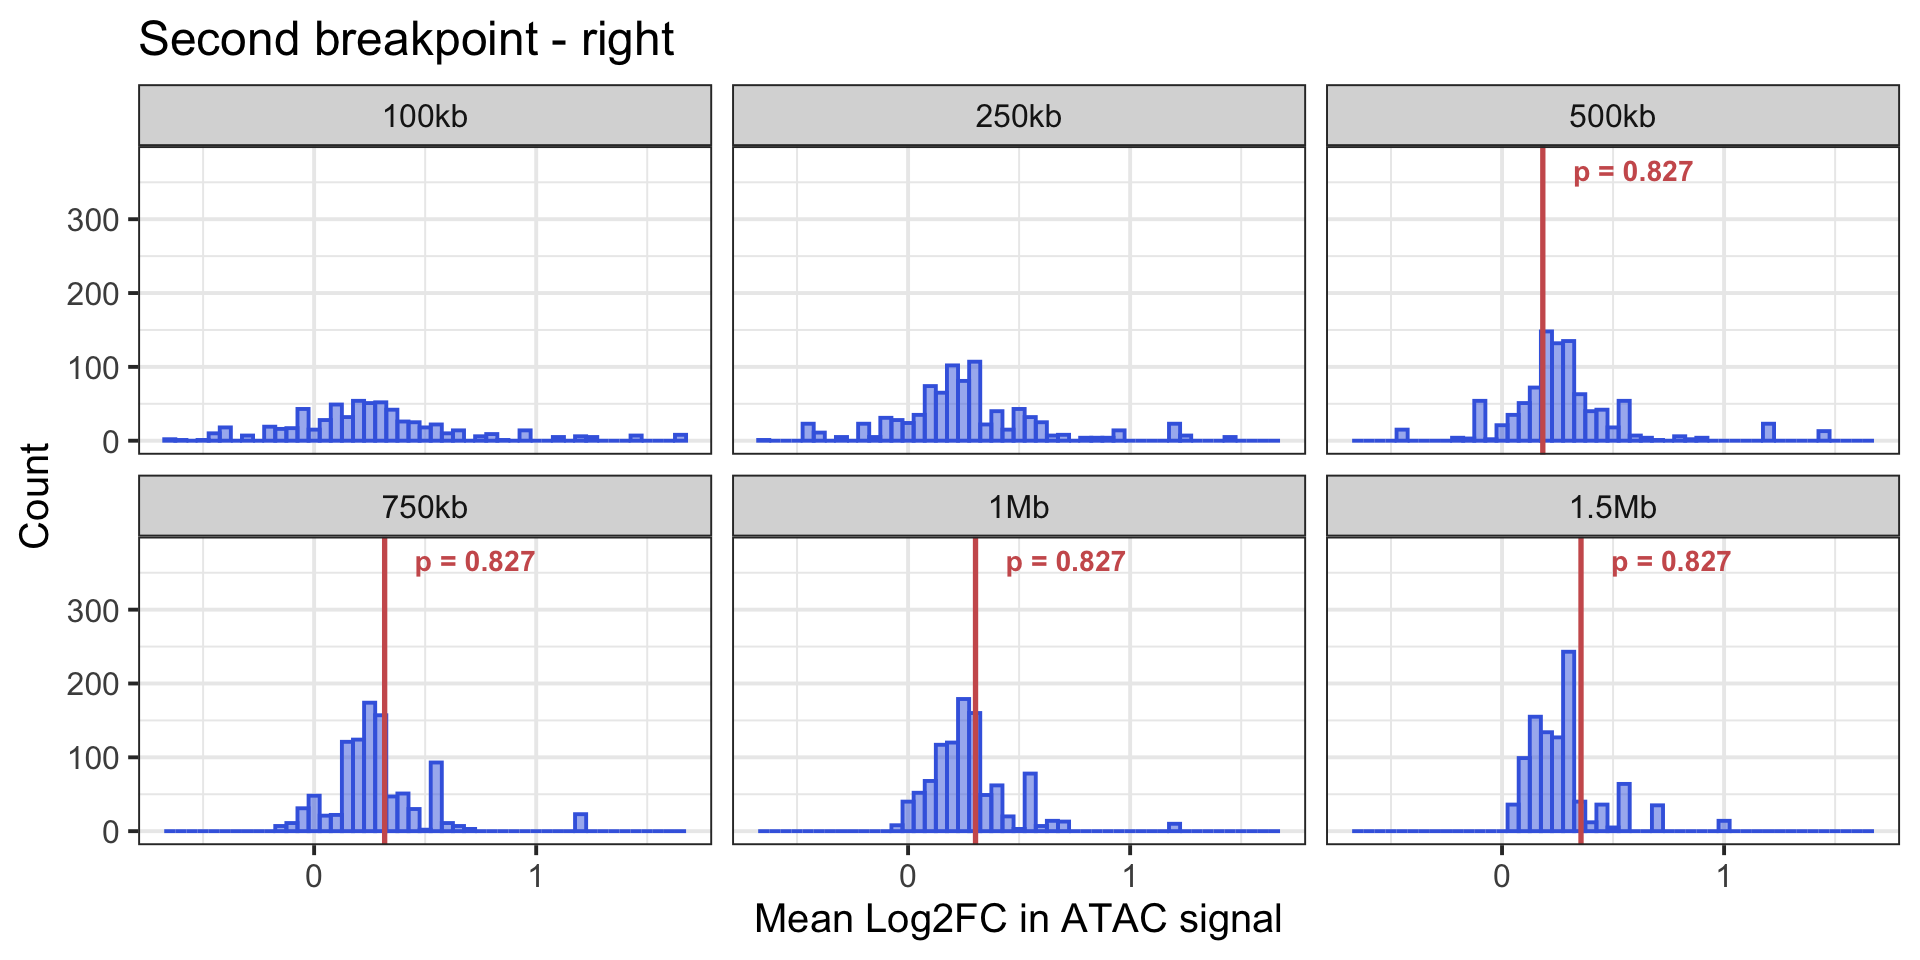

In [82]:
pval <- pValueL(peaks_scores_around_random_bp_all[peaks_scores_around_random_bp_all$Breakpoint == "B2_R",],
                peaks_scores_around_bp_all[peaks_scores_around_bp_all$Breakpoint == "B2_R",],
                "DistanceFromBreakpoint",
                "MeanL2FC")

pval$DistanceFromBreakpoint <- factor(as.character(pval$DistanceFromBreakpoint),
                                      levels = c("100000","250000","500000",
                                                 "750000","1000000","1500000"))


p <- ggplot(peaks_scores_around_random_bp_all[peaks_scores_around_random_bp_all$Breakpoint == "B2_R",],
            aes(x = MeanL2FC,group = DistanceFromBreakpoint))+
  geom_histogram(binwidth = 0.05, alpha = 0.5, color = "royalblue", fill = "royalblue") +
  geom_vline(data = peaks_scores_around_bp_all[peaks_scores_around_bp_all$Breakpoint == "B2_R",],
             aes(xintercept = MeanL2FC,group = DistanceFromBreakpoint), color = "indianred",linewidth=1.5  ) +
  geom_text(data = pval, aes(x = xvalue, y = 380, label = label, group = DistanceFromBreakpoint), 
            vjust = 1, hjust = -0.25, fontface = "bold",color = "indianred", size = 6)+
  guides(fill = "none", color = "none")+
  ylab("Count")+
  xlab("Mean Log2FC in ATAC signal") +
  ggtitle("Second breakpoint - right")+
  facet_wrap(vars(DistanceFromBreakpoint),
             nrow = 2,
             labeller = labeller(DistanceFromBreakpoint = distance.labs))+
  theme_bw(base_size = 24)

options(repr.plot.width=16, repr.plot.height=8)
p

## Loss in chromosome X

In [83]:
# Clone information for the loss in chromosome 1
loss_chrX <- c()
loss_chrX[proj_fil$GeneticClade_Full %in% groups[groups$Location == "chrX:500001-53500000" &
                                                   groups$Altered == "0",]$Clade ] <- "0"
loss_chrX[proj_fil$GeneticClade_Full %in% groups[groups$Location ==  "chrX:500001-53500000" &
                                                   groups$Altered == "1",]$Clade ] <- "1"
loss_chrX[proj_fil$GeneticClade_Full %in% groups[groups$Location ==  "chrX:500001-53500000" &
                                                   groups$Altered == "NA",]$Clade ] <- "NA"

# Add clone information to the project
proj_fil$loss_chrX <- loss_chrX

# Obtain BigWig files containing the ATAC signal, normalised by reads in TSS, for each clone
getGroupBW(
  ArchRProj = proj_fil,
  groupBy = "loss_chrX",
  normMethod = "ReadsInTSS"
)

ArchR logging to : ArchRLogs/ArchR-getGroupBW-e8a94c78c169-Date-2026-02-24_Time-19-56-29.075267.log
If there is an issue, please report to github with logFile!

2026-02-24 19:56:29.789483 : 0 (1 of 2) : Creating BigWig for Group, 0.012 mins elapsed.

2026-02-24 19:56:57.311615 : 1 (2 of 2) : Creating BigWig for Group, 0.471 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-getGroupBW-e8a94c78c169-Date-2026-02-24_Time-19-56-29.075267.log



[1] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_DATAC_Results/GroupBigWigs/loss_chrX/X0-TileSize-100-normMethod-ReadsInTSS-ArchR.bw"
[2] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_DATAC_Results/GroupBigWigs/loss_chrX/X1-TileSize-100-normMethod-ReadsInTSS-ArchR.bw"

### Add clade groupings to the ArchR project and obtain BigWig files containing the ATAC signal for each clones

In [84]:
# Load peaks if necessary
peaks <- getPeakSet(proj_fil)

# Define the gain region, split into 500 bp intervals
start <- seq(1,114765448,500)
end <- start + 499
end[length(end)]<-114765448 #153734546

# Create a peak matrix for chromosome 5

# GRanges object containing the peak information
peaks_info <-  GRanges(
  seqnames = Rle(c("chrX"), c(1)),
  ranges = IRanges(start, end))
peaks_info  <- subsetByOverlaps(peaks, peaks_info)

# Convert the GRanges into a matrix
peaks_info_data <- data.frame(1:length(peaks_info$peakType),
                              rep("chrX", length(peaks_info$peakType)),
                              start(peaks_info),
                              end(peaks_info),
                              peaks_info$peakType,
                              peaks_info$nearestGene,
                              peaks_info$GroupReplicate)
colnames(peaks_info_data) <- c("ID","chrom","start","end","PeakType","NearestGene","GroupReplicate")

# Save peak information for the genomic region of interest
write_csv(peaks_info_data, "../../Data/ATAC_Data/PeakData/ChrX/ChrXLoss_PeakInformation_WholeChrom.csv")


### Compare ATAC signal in peaks between groups, respectively, with and without the copy number alteration of interest

In [85]:

# 1. Group G0

# Load the bigwig file to obtain a GRanges object with the ATAC signal ('score' column) across the genome for C0
c0_bw <- import.bw("../../Data/ArchR_Projects/Save_SW620_DATAC_Results/GroupBigWigs/loss_chrX/X0-TileSize-100-normMethod-ReadsInTSS-ArchR.bw")

# Subset the GRanges object to contain the ATAC signal for the genomic region of interest
c0_bw_sub <- GRanges(
  seqnames = Rle(c("chrX"), c(1)),
  ranges = IRanges(start, end))

c0_bw_sub <- subsetByOverlaps(c0_bw, c0_bw_sub)

# Subset the ATAC signal GRanges object to obtain the ATAC signal in peaks
peaks_c0 <- subsetByOverlaps(c0_bw_sub, peaks_info)

# Convert the GRanges object into a dataframe detailing the ATAC signal per genomic region
peaks_c0_data <- data.frame(rep("chrX", length(peaks_c0$score)),
                            start(peaks_c0),
                            end(peaks_c0),
                            peaks_c0$score)
colnames(peaks_c0_data) <- c("chrom","start","end","SN")

peaks_scores_c0 <- ATACSignalInPeaks(peaks_c0_data,peaks_info_data)

# We filter peaks whose ATAC signal are below the average ATAC signal outside of peaks - this ATAC signal is likely just background noise

# Define a GRanges object for the ATAC signal not in peaks
out_peaks_c0 <- subsetByOverlaps(c0_bw_sub, peaks_info, invert = TRUE)

# Convert the GRanges object to a dataframe
out_peaks_c0_data <- data.frame(rep("chrX", length(out_peaks_c0$score)),
                                start(out_peaks_c0),
                                end(out_peaks_c0),
                                out_peaks_c0$score)
colnames(out_peaks_c0_data) <- c("chrom","start","end","SN")

# Filter for genomic regions with positive ATAC signal (i.e., remove missingness) and define the length of genomic regions
out_peaks_c0_data <- out_peaks_c0_data %>%  dplyr::filter(SN > 0) %>% 
  dplyr::mutate(Length = end - start) 

# Compute the average ATAC signal per bp not in peaks - we distinguish regions with different copy number as higher copy number may be associated with higher background ATAC signal - 
# and select the 95th percentile

Avg_lim <-  quantile(out_peaks_c0_data[out_peaks_c0_data$end <= 56973567,]$SN/out_peaks_c0_data[out_peaks_c0_data$end <= 56973567,]$Length,0.95)
Avg_lim_d <- quantile(out_peaks_c0_data[out_peaks_c0_data$end >56973567,]$SN/out_peaks_c0_data[out_peaks_c0_data$end >56973567,]$Length,0.95)

# Peaks are ordered by position, we define the peak ID that delimits different copy number regions
peaks_max <- max(peaks_info_data[peaks_info_data$end <= 56973567,]$ID)

# Define the background ATAC signal per 500 bp peak; 
# we exclude any peaks with ATAC signal below this minimal value in our subsequent analysis

peaks_scores_c0 <- peaks_scores_c0 %>% dplyr::mutate(MinSN = case_when(Peak_ID <= peaks_max ~ Avg_lim*500, 
                                                                       Peak_ID  > peaks_max ~ Avg_lim_d*500))
peaks_scores_c0 <- peaks_scores_c0 %>%  dplyr::filter(SN > MinSN)

write_csv(peaks_scores_c0, "../../Data/ATAC_Data/PeakData/ChrX/ChrXLoss_PeakScores_G0.csv")

# 2. Group G1

# Load the bigwig file to obtain a GRanges object with the ATAC signal ('score' column) across the genome for C0
c1_bw <-import.bw("../../Data/ArchR_Projects/Save_SW620_DATAC_Results/GroupBigWigs/loss_chrX/X1-TileSize-100-normMethod-ReadsInTSS-ArchR.bw")

# Subset the GRanges object to contain the ATAC signal for the genomic region of interest
c1_bw_sub <- GRanges(
  seqnames = Rle(c("chrX"), c(1)),
  ranges = IRanges(start, end))

c1_bw_sub <- subsetByOverlaps(c1_bw, c1_bw_sub)

# Subset the ATAC signal GRanges object to obtain the ATAC signal in peaks
peaks_c1 <- subsetByOverlaps(c1_bw_sub, peaks_info)

# Convert the GRanges object into a dataframe detailing the ATAC signal per genomic region
peaks_c1_data <- data.frame(rep("chrX", length(peaks_c1$score)),
                            start(peaks_c1),
                            end(peaks_c1),
                            peaks_c1$score)
colnames(peaks_c1_data) <- c("chrom","start","end","SN")

peaks_scores_c1 <- ATACSignalInPeaks(peaks_c1_data,peaks_info_data)

# We filter peaks whose ATAC signal are below the average ATAC signal outside of peaks - this ATAC signal is likely just background noise

# Define a GRanges object for the ATAC signal not in peaks
out_peaks_c1 <- subsetByOverlaps(c1_bw_sub, peaks_info, invert = TRUE)

# Convert the GRanges object to a dataframe
out_peaks_c1_data <- data.frame(rep("chrX", length(out_peaks_c1$score)),
                                start(out_peaks_c1),
                                end(out_peaks_c1),
                                out_peaks_c1$score)
colnames(out_peaks_c1_data) <- c("chrom","start","end","SN")

# Filter for genomic regions with positive ATAC signal (i.e., remove missingness) and define the length of genomic regions
out_peaks_c1_data <- out_peaks_c1_data %>%  dplyr::filter(SN > 0) %>% 
  dplyr::mutate(Length = end - start) 

# Compute the average ATAC signal per bp not in peaks - we distinguish regions with different copy number as higher copy number may be associated with higher background ATAC signal - 
# and select the 95th percentile
Avg_lim <-  quantile(out_peaks_c1_data[out_peaks_c1_data$end <=56973567 ,]$SN/out_peaks_c1_data[out_peaks_c1_data$end <=56973567,]$Length,0.95)
Avg_lim_d <- quantile(out_peaks_c1_data[out_peaks_c1_data$end >56973567,]$SN/out_peaks_c1_data[out_peaks_c1_data$end >56973567,]$Length,0.95)

# Peaks are ordered by position, we define the peak ID that delimits different copy number regions
peaks_max <- max(peaks_info_data[peaks_info_data$end <= 56973567,]$ID)

# Define the background ATAC signal per 500 bp peak; 
# we exclude any peaks with ATAC signal below this minimal value in our subsequent analysis

peaks_scores_c1 <- peaks_scores_c1 %>%  dplyr::mutate(MinSN = case_when(Peak_ID <= peaks_max ~ Avg_lim*500,
                                                                        Peak_ID  > peaks_max ~ Avg_lim_d*500))
peaks_scores_c1 <- peaks_scores_c1 %>%  dplyr::filter(SN > MinSN)

write_csv(peaks_scores_c1, "../../Data/ATAC_Data/PeakData/ChrX/ChrXLoss_PeakScores_G1.csv")


In [86]:
# We compare the ATAC signal in peaks that are shared by groups G0 and G1

shared_peaks <- intersect(peaks_scores_c0$Peak_ID,peaks_scores_c1$Peak_ID)

# Define 
peaks_scores_c0_s <- peaks_scores_c0 %>% dplyr::filter(Peak_ID %in% shared_peaks) %>%
  dplyr::rename(SN_C0 = SN)


peaks_scores_c1_s <- peaks_scores_c1 %>% dplyr::filter(Peak_ID %in% shared_peaks) %>%
  dplyr::rename(SN_C1 = SN)  


peaks_scores_s <- data.frame("Peak_ID" = peaks_scores_c0_s$Peak_ID,
                             "SN_C0" = peaks_scores_c0_s$SN_C0,
                             "SN_C1" = peaks_scores_c1_s$SN_C1)

# We set each peak's location at its midpoint
loc <- peaks_info_data[peaks_info_data$ID %in% peaks_scores_s$Peak_ID,]$start +
  (peaks_info_data[peaks_info_data$ID %in% peaks_scores_s$Peak_ID,]$end-
     peaks_info_data[peaks_info_data$ID %in% peaks_scores_s$Peak_ID,]$start)/2


peaks_scores_s <- peaks_scores_s %>% dplyr::mutate(Region = case_when(Peak_ID <= peaks_max ~ "Loss in C1",
                                                                      Peak_ID  > peaks_max ~ "Diploid segment")) %>%
  dplyr::mutate(L2FC = log2(SN_C1/SN_C0)) %>%
  dplyr::mutate(Location = loc)

write_csv(peaks_scores_s,"../../Data/ATAC_Data/PeakData/ChrX/ChrXLoss_PeakScores_G0vG1_Comparison_SourceData.csv")


Rows: 1362052 Columns: 5
── Column specification ──────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): cell_id, chrom
dbl (3): start, end, state

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


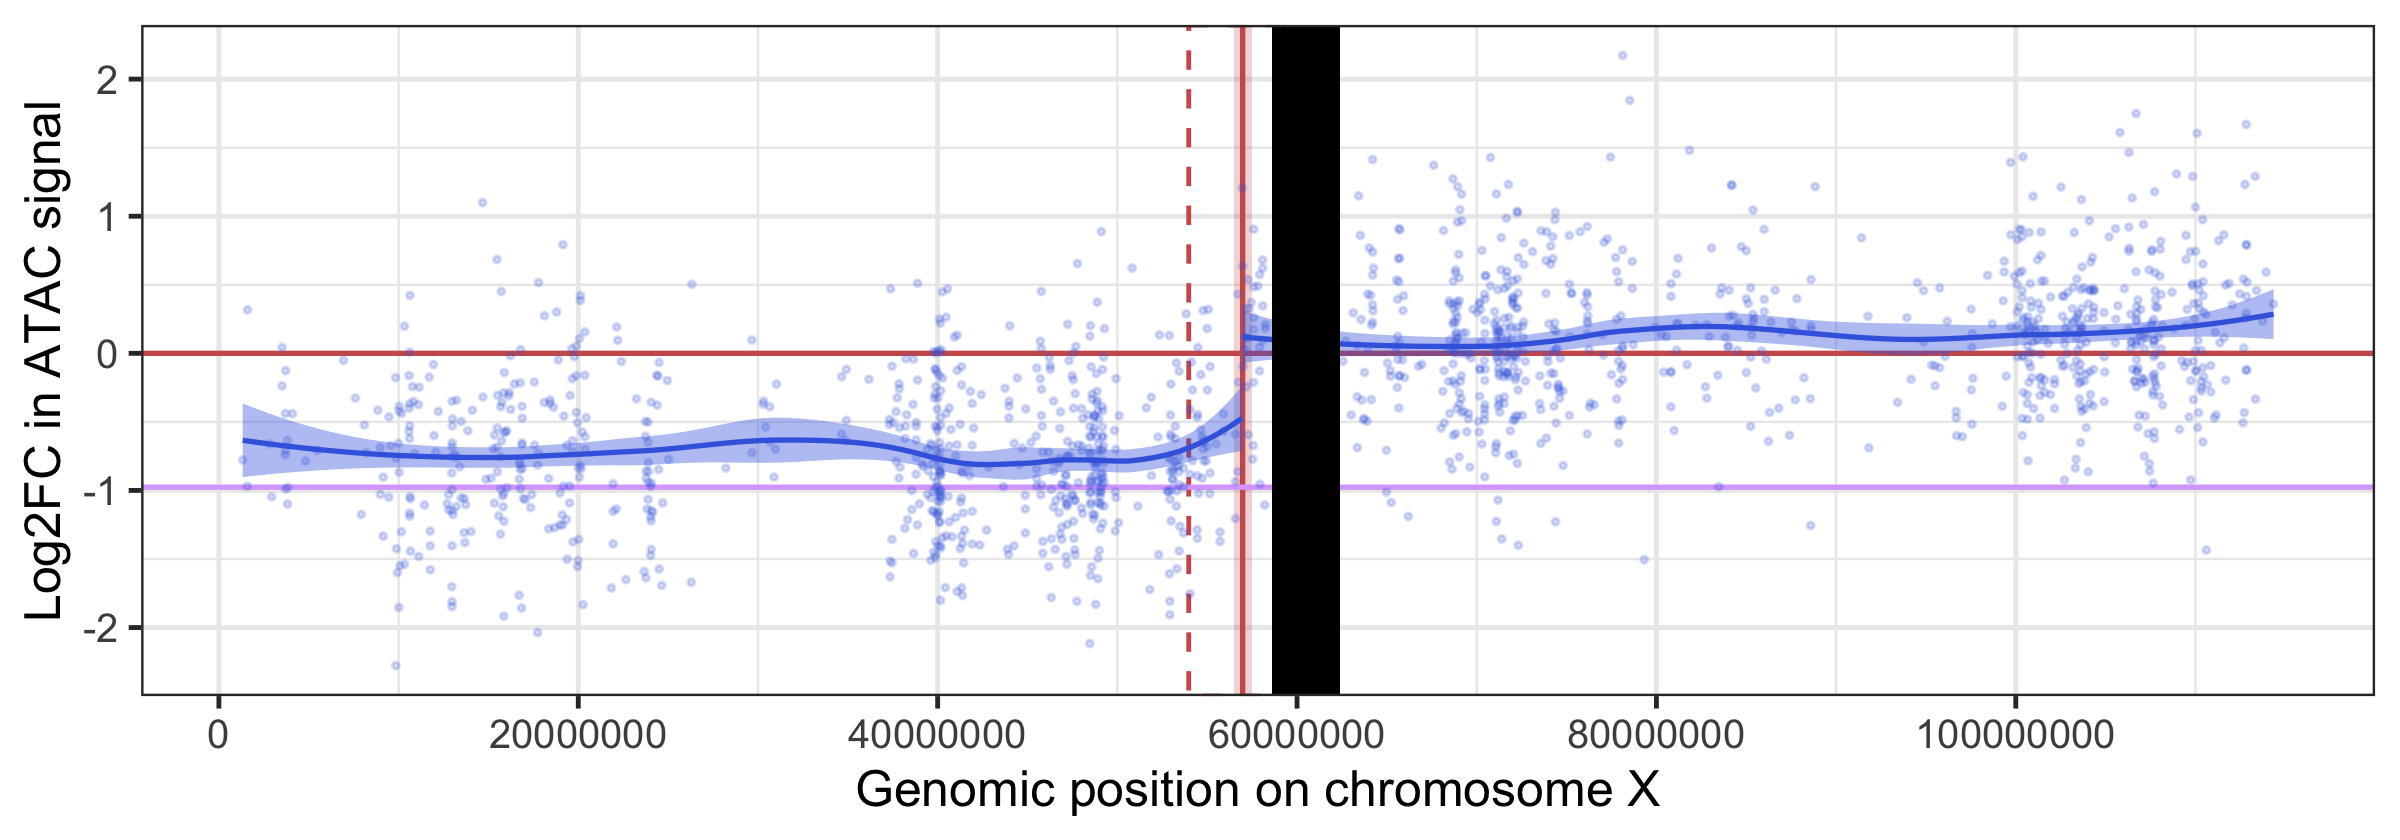

In [92]:
cna_data <- read_tsv("../../Data/CNA_Data/Processed/CNA_Profiles_Segmented_Original.tsv")
clades <- data.frame(read_csv("../../Data/CNA_Data/Processed/Genetic_Clades_And_SuperClades.csv",
                              col_types = "ccc"))

expected_change_loss <- mean(cna_data[cna_data$cell_id %in% clades[clades$Clade %in% groups[groups$Location == "chrX:500001-53500000" & groups$Altered == "1",]$Clade,]$Cell_id & 
                                        cna_data$chrom == "chrX" &
                                        cna_data$end <= 57000000,]$state)/mean(cna_data[cna_data$cell_id %in% clades[clades$Clade %in% groups[groups$Location == "chrX:500001-53500000" & groups$Altered == "0",]$Clade,]$Cell_id & 
                                                                                                                         cna_data$chrom == "chrX" &
                                                                                                                        cna_data$end <= 57000000,]$state)

expected_change_dip <- mean(cna_data[cna_data$cell_id %in% clades[clades$Clade %in% groups[groups$Location == "chrX:500001-53500000" & groups$Altered == "1",]$Clade,]$Cell_id & 
                                       cna_data$chrom == "chrX" &
                                       cna_data$end > 57000000,]$state)/mean(cna_data[cna_data$cell_id %in% clades[clades$Clade %in% groups[groups$Location == "chrX:500001-53500000" & groups$Altered == "1",]$Clade,]$Cell_id & 
                                                                                                                      cna_data$chrom == "chrX" &
                                                                                                                      cna_data$end > 57000000,]$state)  


p <- ggplot() +
  geom_rect(aes(xmin=56973567-500000, xmax=56973567+500000,ymin=-Inf, ymax=Inf),
            fill = "indianred",
            alpha = 0.25)+
  geom_rect(aes(xmin=56973567-3000000, xmax=56973567+3000000, ymin=-Inf, ymax=Inf),
            color = "indianred", linetype = 2,
            fill = NA,alpha = 0.25)+
  geom_vline(xintercept = 56973567,
             color = "indianred", linewidth = 1.5)+
  geom_hline(yintercept = log2(expected_change_dip),
             color = "indianred", linewidth = 1.5)+
  geom_hline(yintercept = log2(expected_change_loss),
             color = "#dbaaff", linewidth = 1.5)+
  geom_point(data = peaks_scores_s, 
             aes(x = Location, y = L2FC),
             alpha = 0.2, 
             size = 1,
             color = "royalblue") +
  geom_smooth(data = peaks_scores_s[peaks_scores_s$Location <=56973567,],
              aes(x = Location, y = L2FC),
              method = "loess",
              span = 0.5, 
              linewidth = 1.5,
              color = "royalblue", 
              se = T, 
              fill = "royalblue")+
  geom_smooth(data = peaks_scores_s[peaks_scores_s$Location > 56973567,], aes(x = Location, y = L2FC),
              method = "loess",
              span = 0.5, 
              linewidth = 1.5,
              color = "royalblue",
              se = T,
              fill = "royalblue")+
  geom_rect(aes(xmin=58605579, xmax=62412542, ymin=-Inf, ymax=Inf), # Black-out the centromere 
            fill= "black",
            alpha=1)+
  scale_y_continuous(breaks = seq(-5, 5, by = 1),
                     minor_breaks = seq(-5, 5, by = 0.5))+
  scale_x_continuous(breaks = seq(0, 200000000, by = 20000000),
                     minor_breaks = seq(0, 200000000, by = 10000000))+
  ylab("Log2FC in ATAC signal")+
  xlab("Genomic position on chromosome X")+
  theme_bw(base_size=30)
options(repr.plot.width=20, repr.plot.height=7)
p

### Breakpoint analysis

We test whether there are significant differences in ATAC signal between groups G0 and G1 around the copy number alteration breakpoints. To do so, we compare the mean L2FC of peaks at a fixed distance from the breakpoints to the mean L2FC of peaks at a fixed distance from randomly selected loci away from breakpoints.

#### True mean L2FC

In [94]:
b1 <- 56973567

distances <- c(100000,250000,500000,750000,1000000,1500000)
peaks_around_bp <-  data.frame(Peak_ID = double(),
                               distance = double(),
                               bp = character())
for (distance in distances){
  inds_b1l <- which(peaks_info_data$start >= b1-distance & peaks_info_data$end <= b1)
  peaks_around_bp <- rbind(peaks_around_bp, 
                           cbind(peaks_info_data$ID[inds_b1l],
                                 rep(distance,length(inds_b1l)),
                                 rep("B1_L",length(inds_b1l))))
  
  
  
  inds_b1r <- which(peaks_info_data$start >= b1 & peaks_info_data$end <= b1+distance)
  peaks_around_bp <- rbind(peaks_around_bp, 
                           cbind(peaks_info_data$ID[inds_b1r],
                                 rep(distance,length(inds_b1r)),
                                 rep("B1_R",length(inds_b1r))))
  
  
}
colnames(peaks_around_bp) <- c("Peak_ID","DistanceFromBreakpoint","Breakpoint")

write_csv(peaks_around_bp,"../../Data/ATAC_Data/PeakData/ChrX/ChrXLoss_PeaksFlankingBreakpoints.csv")

# Cumulative shared peak signal around the breakpoints - true loci flanking breakpoints

# 1. Left breakpoint, right-side
peaks_scores_around_bp_b1r <-  data.frame(distance = double(),
                                          L2FC = double())

for (distance in distances) {
  s0 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_bp[peaks_around_bp$DistanceFromBreakpoint == distance &
                                                                     peaks_around_bp$Breakpoint == "B1_R",]$Peak_ID,]$SN_C0
  s1 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_bp[peaks_around_bp$DistanceFromBreakpoint == distance &
                                                                     peaks_around_bp$Breakpoint == "B1_R",]$Peak_ID,]$SN_C1
  
  peaks_scores_around_bp_b1r <- rbind(peaks_scores_around_bp_b1r, cbind(distance, sum(log2(s1/s0))/length(s0),"B1_R"))
}

colnames(peaks_scores_around_bp_b1r) <- c("DistanceFromBreakpoint","MeanL2FC","Breakpoint")
peaks_scores_around_bp_b1r$DistanceFromBreakpoint <- factor(as.character(peaks_scores_around_bp_b1r$DistanceFromBreakpoint),
                                                            levels = c("100000","250000","500000",
                                                                       "750000","1000000","1500000"))

# 2. Left breakpoint, left-side
peaks_scores_around_bp_b1l <-  data.frame(distance = double(),
                                          L2FC = double())

for (distance in distances) {
  s0 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_bp[peaks_around_bp$DistanceFromBreakpoint == distance &
                                                                     peaks_around_bp$Breakpoint == "B1_L",]$Peak_ID,]$SN_C0
  s1 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_bp[peaks_around_bp$DistanceFromBreakpoint == distance &
                                                                     peaks_around_bp$Breakpoint == "B1_L",]$Peak_ID,]$SN_C1
  
  peaks_scores_around_bp_b1l <- rbind(peaks_scores_around_bp_b1l, cbind(distance, sum(log2(s1/s0))/length(s0),"B1_L"))
}

colnames(peaks_scores_around_bp_b1l) <- c("DistanceFromBreakpoint","MeanL2FC","Breakpoint")
peaks_scores_around_bp_b1l$DistanceFromBreakpoint <- factor(as.character(peaks_scores_around_bp_b1l$DistanceFromBreakpoint),
                                                            levels = c("100000","250000","500000",
                                                                       "750000","1000000","1500000"))


peaks_scores_around_bp_all <- rbind(peaks_scores_around_bp_b1l,
                                    peaks_scores_around_bp_b1r)

peaks_scores_around_bp_all$MeanL2FC <- as.numeric(peaks_scores_around_bp_all$MeanL2FC)

peaks_scores_around_bp_all$DistanceFromBreakpoint <- factor(as.character(peaks_scores_around_bp_all$DistanceFromBreakpoint),
                                                            levels = c("100000","250000","500000",
                                                                       "750000","1000000","1500000"))

write_csv(peaks_scores_around_bp_all,"../../Data/ATAC_Data/PeakData/ChrX/ChrXLoss_PeaksFlankingBreakpoints_TrueMeanL2FC.csv")


#### Mean L2FC around random loci (null distribution)

In [ ]:
s <- 1
b1 <- 56973567
e <- 114256790

set.seed(123)

loci_b1l <- round(runif(1000, s+1500000, b1-1500000))
loci_b1r <- round(runif(1000, b1+1500000, e-1500000))

peaks_around_random_bp <-  data.frame(Locus = double(),
                                      Peak_ID = double(),
                                      distance = double(),
                                      bp = character())


for (l in loci_b1l){
  for (distance in distances){
    inds <- which(peaks_info_data$start >= (l-distance) & peaks_info_data$end <= l)
    peaks_around_random_bp <- rbind(peaks_around_random_bp, 
                                    cbind(rep(l,length(inds)),
                                          peaks_info_data$ID[inds],
                                          rep(distance,length(inds)),
                                          rep("B1_L",length(inds))))
  }
}
for (l in loci_b1r){
  for (distance in distances){
    inds <- which(peaks_info_data$start >= l & peaks_info_data$end <= l+distance)
    peaks_around_random_bp <- rbind(peaks_around_random_bp, 
                                    cbind(rep(l,length(inds)),
                                          peaks_info_data$ID[inds],
                                          rep(distance,length(inds)),
                                          rep("B1_R",length(inds))))
  }
}


colnames(peaks_around_random_bp) <- c("Locus","Peak_ID","DistanceFromBreakpoint","Breakpoint")

write_csv(peaks_around_random_bp,"../../Data/ATAC_Data/PeakData/ChrX/ChrXLoss_PeaksFlankingBreakpoints_RandomLoci.csv")

# Cumulative shared peak signal around the breakpoints - random loci

# 1. Left breakpoint, left-side
peak_scores_around_random_bp_b1l <-  data.frame(distance = double(),
                                                L2FC = double())

for (l in loci_b1l){
  for (distance in distances) {
    
    s0 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_random_bp[peaks_around_random_bp$DistanceFromBreakpoint == distance &
                                                                              peaks_around_random_bp$Locus == l & peaks_around_random_bp$Breakpoint == "B1_L",]$Peak_ID,]$SN_C0
    s1 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_random_bp[peaks_around_random_bp$DistanceFromBreakpoint == distance &
                                                                              peaks_around_random_bp$Locus == l & peaks_around_random_bp$Breakpoint == "B1_L",]$Peak_ID,]$SN_C1
    
    
    peak_scores_around_random_bp_b1l <- rbind(peak_scores_around_random_bp_b1l, cbind(distance, sum(log2(s1/s0))/length(s0), "B1_L"))
  }
}

colnames(peak_scores_around_random_bp_b1l) <- c("DistanceFromBreakpoint","MeanL2FC","Breakpoint")
peak_scores_around_random_bp_b1l <- na.omit(peak_scores_around_random_bp_b1l)
peak_scores_around_random_bp_b1l$DistanceFromBreakpoint <- factor(as.character(peak_scores_around_random_bp_b1l$DistanceFromBreakpoint),
                                                                  levels = c("100000","250000","500000",
                                                                             "750000","1000000","1500000"))

# 2. Left breakpoint, right-side

peak_scores_around_random_bp_b1r <-  data.frame(distance = double(),
                                                L2FC = double())

for (l in loci_b1r){
  for (distance in distances) {
    
    s0 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_random_bp[peaks_around_random_bp$DistanceFromBreakpoint == distance &
                                                                              peaks_around_random_bp$Locus == l & peaks_around_random_bp$Breakpoint == "B1_R",]$Peak_ID,]$SN_C0
    s1 <- peaks_scores_s[peaks_scores_s$Peak_ID %in% peaks_around_random_bp[peaks_around_random_bp$DistanceFromBreakpoint == distance &
                                                                              peaks_around_random_bp$Locus == l & peaks_around_random_bp$Breakpoint == "B1_R",]$Peak_ID,]$SN_C1
    
    
    peak_scores_around_random_bp_b1r <- rbind(peak_scores_around_random_bp_b1r, cbind(distance, sum(log2(s1/s0))/length(s0), "B1_R"))
  }
}

colnames(peak_scores_around_random_bp_b1r) <- c("DistanceFromBreakpoint","MeanL2FC","Breakpoint")
peak_scores_around_random_bp_b1r <- na.omit(peak_scores_around_random_bp_b1r)
peak_scores_around_random_bp_b1r$DistanceFromBreakpoint <- factor(as.character(peak_scores_around_random_bp_b1r$DistanceFromBreakpoint),
                                                                  levels = c("100000","250000","500000",
                                                                             "750000","1000000","1500000"))

peaks_scores_around_random_bp_all <- rbind(peak_scores_around_random_bp_b1l,
                                           peak_scores_around_random_bp_b1r)

peaks_scores_around_random_bp_all$MeanL2FC <- as.numeric(peaks_scores_around_random_bp_all$MeanL2FC)

peaks_scores_around_random_bp_all$DistanceFromBreakpoint <- factor(as.character(peaks_scores_around_random_bp_all$DistanceFromBreakpoint),
                                                                   levels = c("100000","250000","500000",
                                                                              "750000","1000000","1500000"))

write_csv(peaks_scores_around_random_bp_all,"../../Data/ATAC_Data/PeakData/ChrX/ChrXLoss_PeaksFlankingBreakpoints_RandomLoci_SimulatedMeanL2FC.csv")


In [95]:
# Load the simulated and true data
peaks_scores_around_random_bp_all <- read_csv("../../Data/ATAC_Data/PeakData/ChrX/ChrXLoss_PeaksFlankingBreakpoints_RandomLoci_SimulatedMeanL2FC.csv",
                                              col_types = "cdc")
peaks_scores_around_bp_all <- read_csv("../../Data/ATAC_Data/PeakData/ChrX/ChrXLoss_PeaksFlankingBreakpoints_TrueMeanL2FC.csv",
                                       col_types = "cdc")

peaks_scores_around_random_bp_all$DistanceFromBreakpoint <- factor(as.character(peaks_scores_around_random_bp_all$DistanceFromBreakpoint),
                                                                   levels = c("100000","250000","500000",
                                                                              "750000","1000000","1500000"))
peaks_scores_around_bp_all$DistanceFromBreakpoint <- factor(as.character(peaks_scores_around_bp_all$DistanceFromBreakpoint),
                                                            levels = c("100000","250000","500000",
                                                                       "750000","1000000","1500000"))

distance.labs <- c("100000" = "100kb", "250000" = "250kb",
                   "500000" = "500kb", "750000" = "750kb",
                   "1000000" = "1Mb",  "1500000" = "1.5Mb")

New names:
• `` -> `...4`


#### Breakpoint: left

Warning message:
“Removed 1442 rows containing non-finite outside the scale range (`stat_bin()`).”


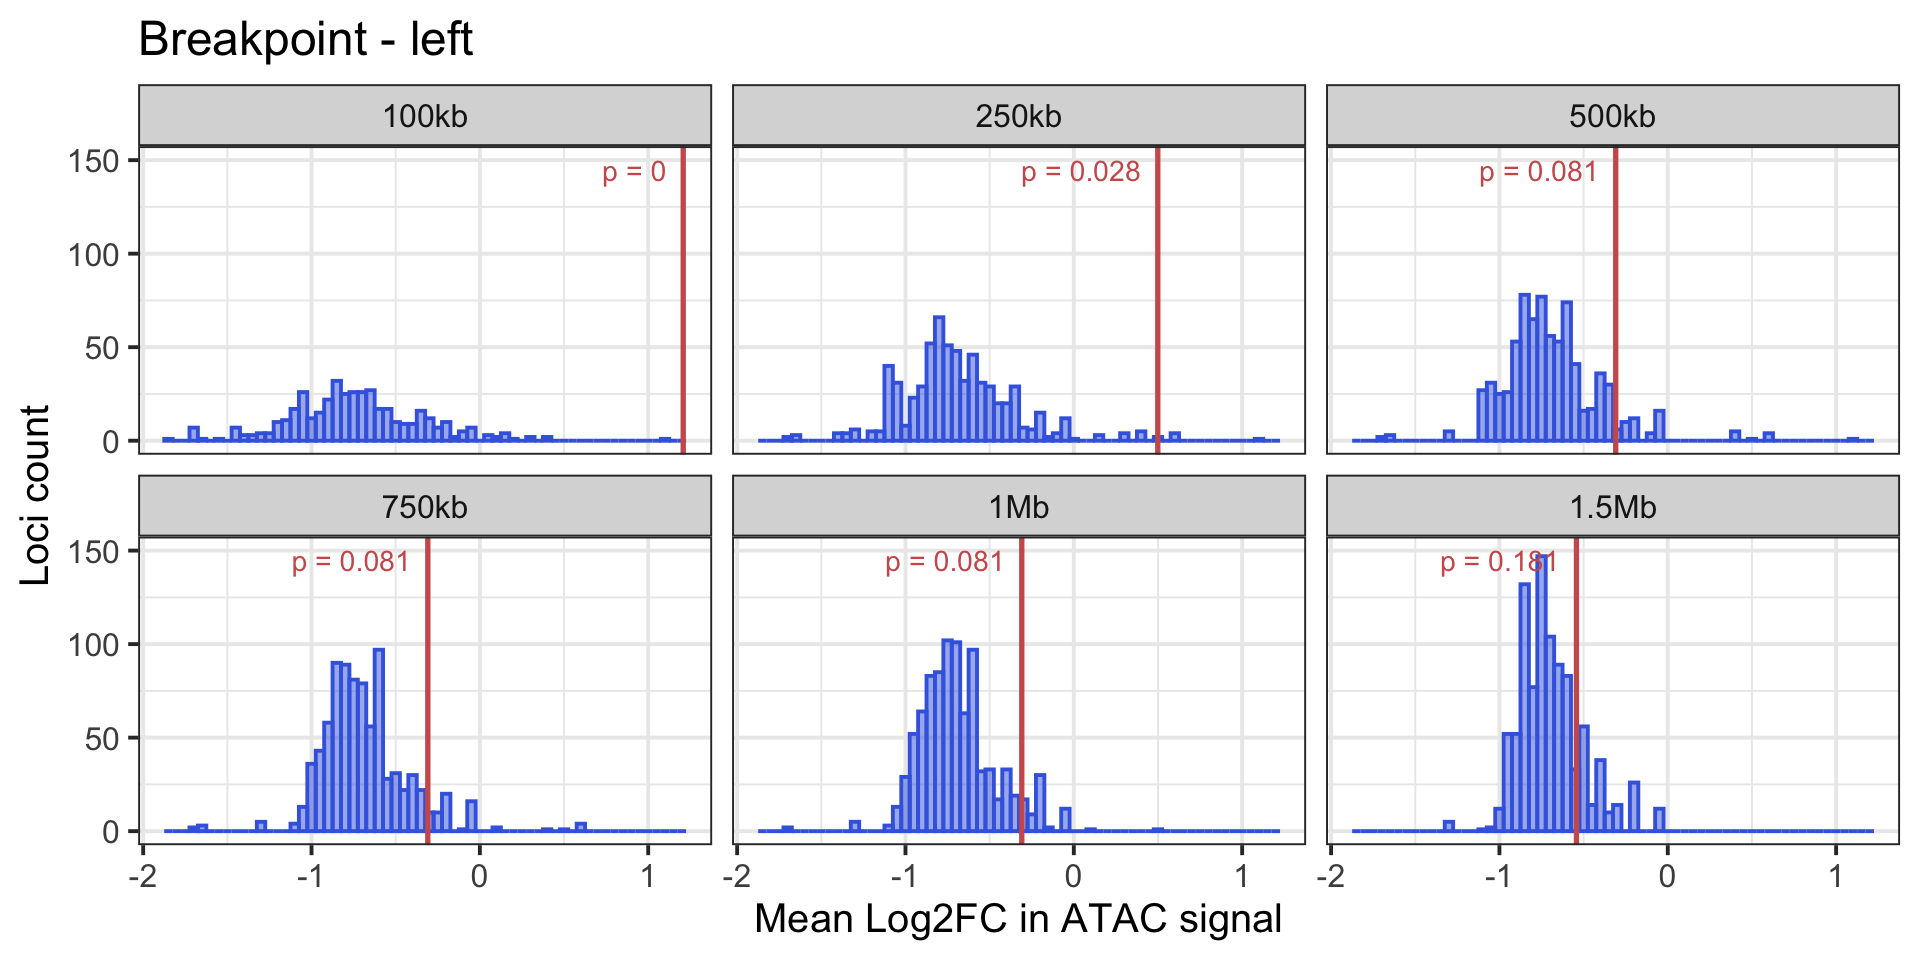

In [97]:
pval <- pValueH(peaks_scores_around_random_bp_all[peaks_scores_around_random_bp_all$Breakpoint == "B1_L",],
                peaks_scores_around_bp_all[peaks_scores_around_bp_all$Breakpoint == "B1_L",],
                "DistanceFromBreakpoint",
                "MeanL2FC")

pval$DistanceFromBreakpoint <- factor(as.character(pval$DistanceFromBreakpoint),
                                      levels = c("100000","250000","500000",
                                                 "750000","1000000","1500000"))


p <- ggplot(peaks_scores_around_random_bp_all[peaks_scores_around_random_bp_all$Breakpoint == "B1_L",],
            aes(x = MeanL2FC,group = DistanceFromBreakpoint))+
  geom_histogram(binwidth = 0.05, alpha = 0.5, color = "royalblue", fill = "royalblue") +
  geom_vline(data = peaks_scores_around_bp_all[peaks_scores_around_bp_all$Breakpoint == "B1_L",],
             aes(xintercept = MeanL2FC,group = DistanceFromBreakpoint),
             color = "indianred",linewidth=1.5  ) +
  geom_text(data = pval, aes(x = xvalue-0.1, y = 150, label = label, group = DistanceFromBreakpoint), 
            vjust = 1, hjust = +1, color = "indianred", size = 6)+
  guides(fill = "none", color = "none")+
  ylab("Loci count")+
  xlab("Mean Log2FC in ATAC signal") +
  ggtitle("Breakpoint - left")+
  facet_wrap(vars(DistanceFromBreakpoint),
             nrow = 2,
             labeller = labeller(DistanceFromBreakpoint = distance.labs))+
  theme_bw(base_size = 24)

options(repr.plot.width=16, repr.plot.height=8)

p

#### Breakpoint: right

Warning message:
“Removed 1277 rows containing non-finite outside the scale range (`stat_bin()`).”


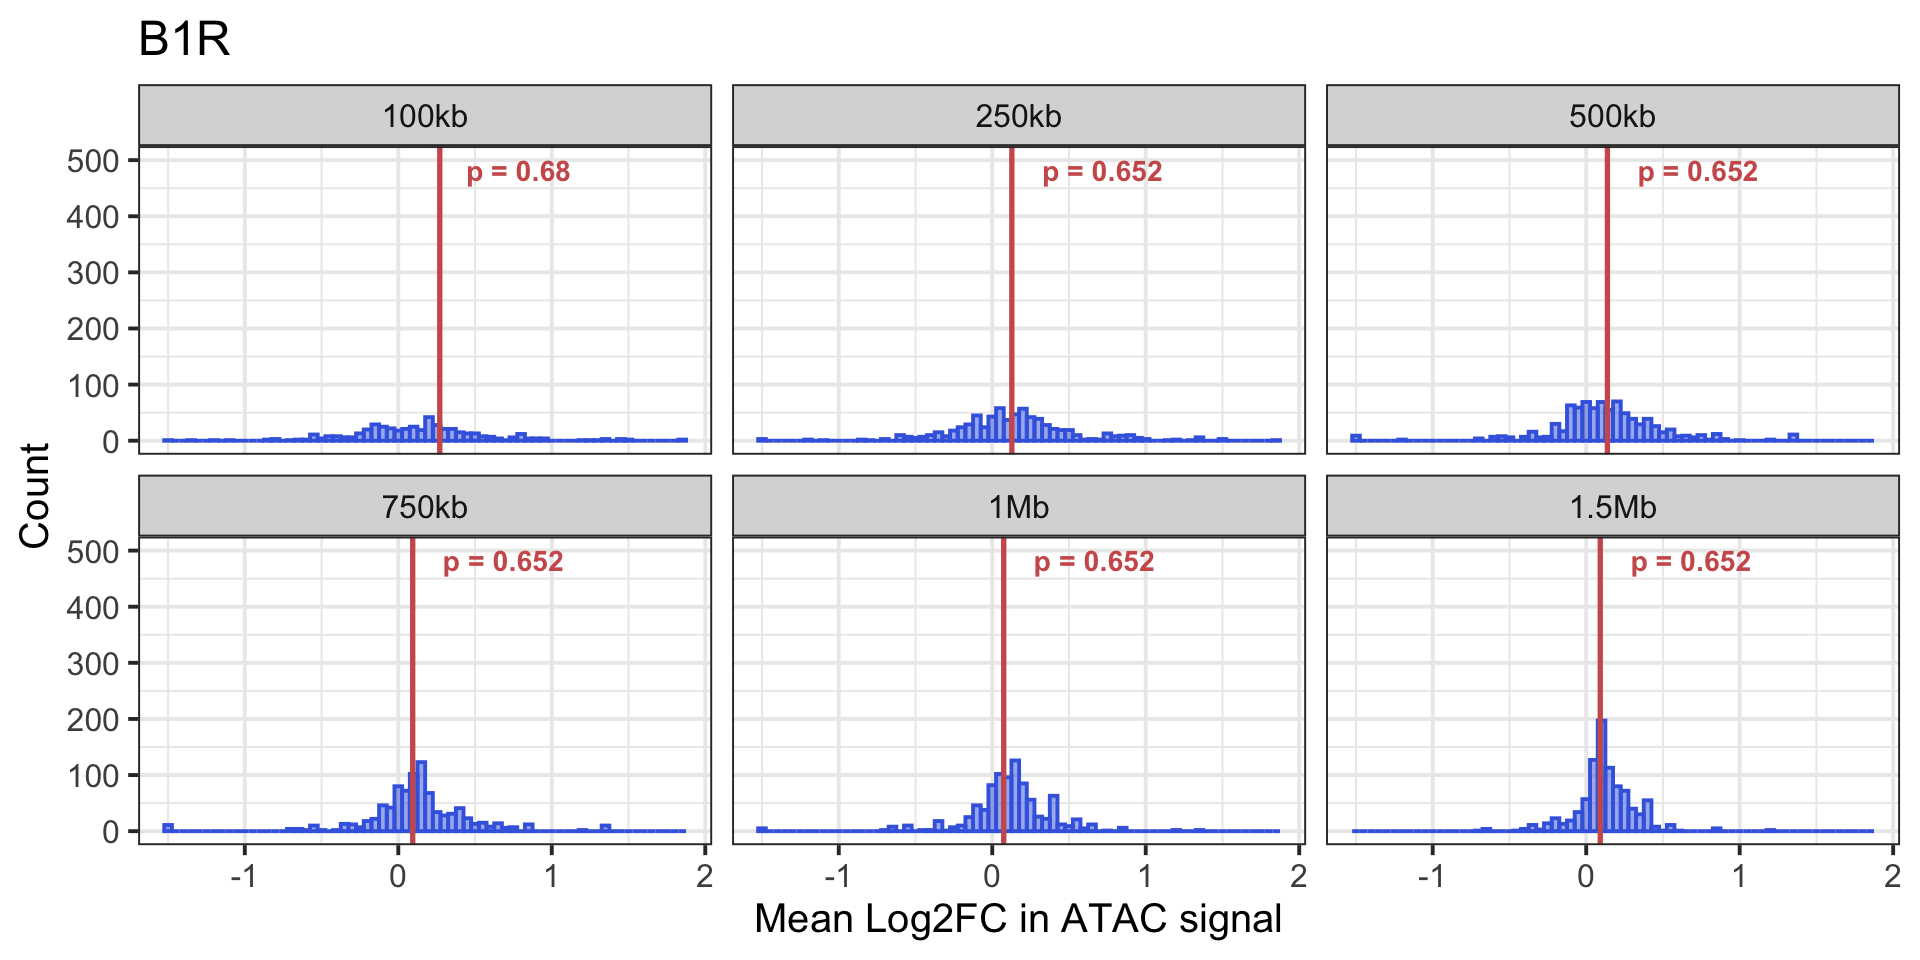

In [98]:
pval <- pValueL(peaks_scores_around_random_bp_all[peaks_scores_around_random_bp_all$Breakpoint == "B1_R",],
                peaks_scores_around_bp_all[peaks_scores_around_bp_all$Breakpoint == "B1_R",],
                "DistanceFromBreakpoint",
                "MeanL2FC")

pval$DistanceFromBreakpoint <- factor(as.character(pval$DistanceFromBreakpoint),
                                      levels = c("100000","250000","500000",
                                                 "750000","1000000","1500000"))



p <- ggplot(peaks_scores_around_random_bp_all[peaks_scores_around_random_bp_all$Breakpoint == "B1_R",],
            aes(x = MeanL2FC,group = DistanceFromBreakpoint))+
  geom_histogram(binwidth = 0.05, alpha = 0.5, color = "royalblue", fill = "royalblue") +
  geom_vline(data = peaks_scores_around_bp_all[peaks_scores_around_bp_all$Breakpoint == "B1_R",],
             aes(xintercept = MeanL2FC,group = DistanceFromBreakpoint),
             color = "indianred",linewidth=1.5  ) +
  geom_text(data = pval, aes(x = xvalue, y = 500, label = label, group = DistanceFromBreakpoint), 
            vjust = 1, hjust = -0.25, fontface = "bold",color = "indianred", size = 6)+
  guides(fill = "none", color = "none")+
  ylab("Count")+
  xlab("Mean Log2FC in ATAC signal") +
  ggtitle("B1R")+
  facet_wrap(vars(DistanceFromBreakpoint),
             nrow = 2,
             labeller = labeller(DistanceFromBreakpoint = distance.labs))+
  theme_bw(base_size = 24)
options(repr.plot.width=16, repr.plot.height=8)
p